# MoSeq Syllable Clustering and Behavioral Analysis — NSG vs. C57BL/6

This notebook processes Motion Sequencing (MoSeq) output data from a longitudinal stroke study comparing NSG and C57BL/6 (Bl6) mice at baseline (BSL) and 7 days post-stroke induction (CS_7DPI).

**Experimental groups:**
- `C57_BSL` — Bl6 mice at baseline
- `C57_CS_7DPI` — Bl6 mice, 7 days post-stroke
- `NSG_BSL` — NSG mice at baseline
- `NSG_CS_7DPI` — NSG mice, 7 days post-stroke

**Pipeline overview:**
1. Load and clean the MoSeq frame-level dataframe
2. Compute per-syllable kinematics (velocity and displacement)
3. Cluster syllables into four behavioral categories based on kinematic profiles
4. Visualize syllable usage across groups via heatmaps and bar plots
5. Normalize usage relative to each strain's baseline
6. Characterize mean locomotor velocity across groups
7. Compute within-session PCA trajectories to visualize behavioral state dynamics

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
try:
    from statannotations.Annotator import Annotator
except:
    !pip install statannotations
    from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt

# 1. Data Loading

Load the MoSeq frame-level dataframe (`moseq_df`) and the per-session statistics dataframe (`stats_df`) from a pre-trained model applied to C57BL/6 and NSG recordings. Each row in `moseq_df` is one frame, annotated with the syllable label assigned by the model and associated kinematic features.

In [2]:
from google.colab.drive import mount

mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls

drive  sample_data


In [3]:
#MODEL_PATH = Path('/mnt/g/Shared drives/llorente-lab/Moseq/RawData/Nature_Comm_Revisions/C57Bl6_MoSeq_Young_Males_CTRL_CS_BSL_7DPI/applied_models/final-model-000-12742750')
MODEL_PATH = Path('/content/drive/MyDrive/Moseq/RawData/Nature_Comm_Revisions/C57Bl6_MoSeq_Young_Males_CTRL_CS_BSL_7DPI/applied_models/final_model_pretrained')
MOSEQ_DF_PATH = MODEL_PATH / 'moseq_df.csv'
STATS_DF_PATH = MODEL_PATH / 'stats_df.csv'

moseq_df = pd.read_csv(MOSEQ_DF_PATH)
stats_df = pd.read_csv(STATS_DF_PATH)

print(moseq_df.shape)
print(stats_df.shape)

/tmp/ipykernel_2122/1302009566.py:6: DtypeWarning: Columns (30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  moseq_df = pd.read_csv(MOSEQ_DF_PATH)


(2423892, 33)
(2680, 90)


In [ ]:
moseq_df.to_csv(str(MOSEQ_DF_PATH), index=False)

# 2. Preprocessing

The MoSeq model emits a label of `-5` for the first three frames of each session during model initialization. These frames do not represent real behavioral syllables and are excluded before any analysis.

In [4]:
moseq_df = moseq_df[moseq_df['labels (usage sort)'] >= 0]
moseq_df.shape # make sure it's all okay

(2423691, 33)

In [5]:
len(list(moseq_df['uuid'].unique()))

67

This is a longitudinal study, so a treatment and timepoint column will make our lives...very easy. We are also comparing Bl6 vs NSG so let's also add a strain column.

In [ ]:
# # Split into components
# cols = ["treatment", "agesex", "timepoint", "strain"]
# moseq_df[cols] = moseq_df["group"].str.split("_", expand=True)

# # Standardize control naming
# moseq_df["treatment"] = moseq_df["treatment"].replace({
#     "CTRL": "CTRL",
#     "Control": "CTRL"
# })

# # Sanity check!

# for col in cols:
#     print(col)
#     print(moseq_df[col].unique())

# 3. Syllable Kinematic Clustering

Each MoSeq syllable is characterized by its mean 3D velocity and mean displacement across all frames in which it appears. Syllables are then median-split along each kinematic axis to produce four clusters:

| Cluster | Displacement | Velocity | Behavioral interpretation |
|---|---|---|---|
| `high_disp_high_vel` | High | High | Motor-related improvement |
| `high_disp_low_vel` | High | Low | Motor-related deficit |
| `low_disp_high_vel` | Low | High | Cognitive-related improvement |
| `low_disp_low_vel` | Low | Low | Cognitive-related deficit |

The median split is applied first on displacement (to separate high vs. low displacement groups), then on velocity within each displacement group.

In [ ]:
moseq_df["displacement_mm"] = np.sqrt(
    df["centroid_x_mm"].diff()**2 +
    df["centroid_y_mm"].diff()**2
)

moseq_df["displacement_mm"] = df["displacement_mm"].fillna(0)

syllable_kinematics = (
    moseq_df
    .groupby('labels (usage sort)')
    .agg(
        mean_velocity=('velocity_3d_mm', 'mean'),
        mean_displacement=('displacement_mm', 'mean'),
        n=('velocity_3d_mm', 'count')
    )
    .reset_index()
    .rename(columns={'labels (usage sort)': 'syllable'})
)
syllable_kinematics = syllable_kinematics[syllable_kinematics['n'] >= 5].reset_index(drop=True)

In [45]:
syllable_kinematics = syllable_kinematics.sort_values('mean_displacement').reset_index(drop=True)
mid = len(syllable_kinematics) // 2
syllable_kinematics['disp_group'] = 'high_disp'
syllable_kinematics.loc[:mid-1, 'disp_group'] = 'low_disp'

clusters = []
for name, grp in syllable_kinematics.groupby('disp_group'):
    grp = grp.sort_values('mean_velocity').reset_index(drop=True)
    mid = len(grp) // 2
    grp['vel_group'] = 'high_vel'
    grp.loc[:mid-1, 'vel_group'] = 'low_vel'
    grp['cluster'] = grp['disp_group'] + '_' + grp['vel_group']
    clusters.append(grp)

syllable_kinematics = pd.concat(clusters).reset_index(drop=True)
syl_to_cluster = syllable_kinematics.set_index('syllable')['cluster'].to_dict()

Each cluster contains exactly 10 syllables (from the 40 total), since the median split is balanced by design. The cluster label is stored back into `moseq_df` so downstream analyses can group frames by behavioral category.

In [46]:
syllable_kinematics["cluster"].value_counts()

,count
cluster,
high_disp_low_vel,10
high_disp_high_vel,10
low_disp_low_vel,10
low_disp_high_vel,10


In [47]:
moseq_df['cluster'] = moseq_df['labels (usage sort)'].map(syl_to_cluster)

# 4. Visualization

## 4.1 Syllable Usage Heatmap (All Syllables)

Visualize the proportion of frames assigned to each syllable for each experimental group. Proportions are computed column-wise so each group sums to 1, enabling direct comparison of relative syllable usage across groups.

In [48]:
# Let's create a variable that decides where our plots are saved

save_path = '/content/drive/My Drive/Moseq/RawData/Nature_Comm_Revisions/C57Bl6_MoSeq_Young_Males_CTRL_CS_BSL_7DPI/figures-oldmodel/'
SAVE_PATH = Path(save_path)
SAVE_PATH.exists()

True

In [49]:
df = moseq_df

# count occurrences
counts = (
    df
    .groupby(["labels (usage sort)", "group"])
    .size()
    .unstack(fill_value=0)
)

# convert to proportions (column-wise)
proportions = counts.div(counts.sum(axis=0), axis=1)

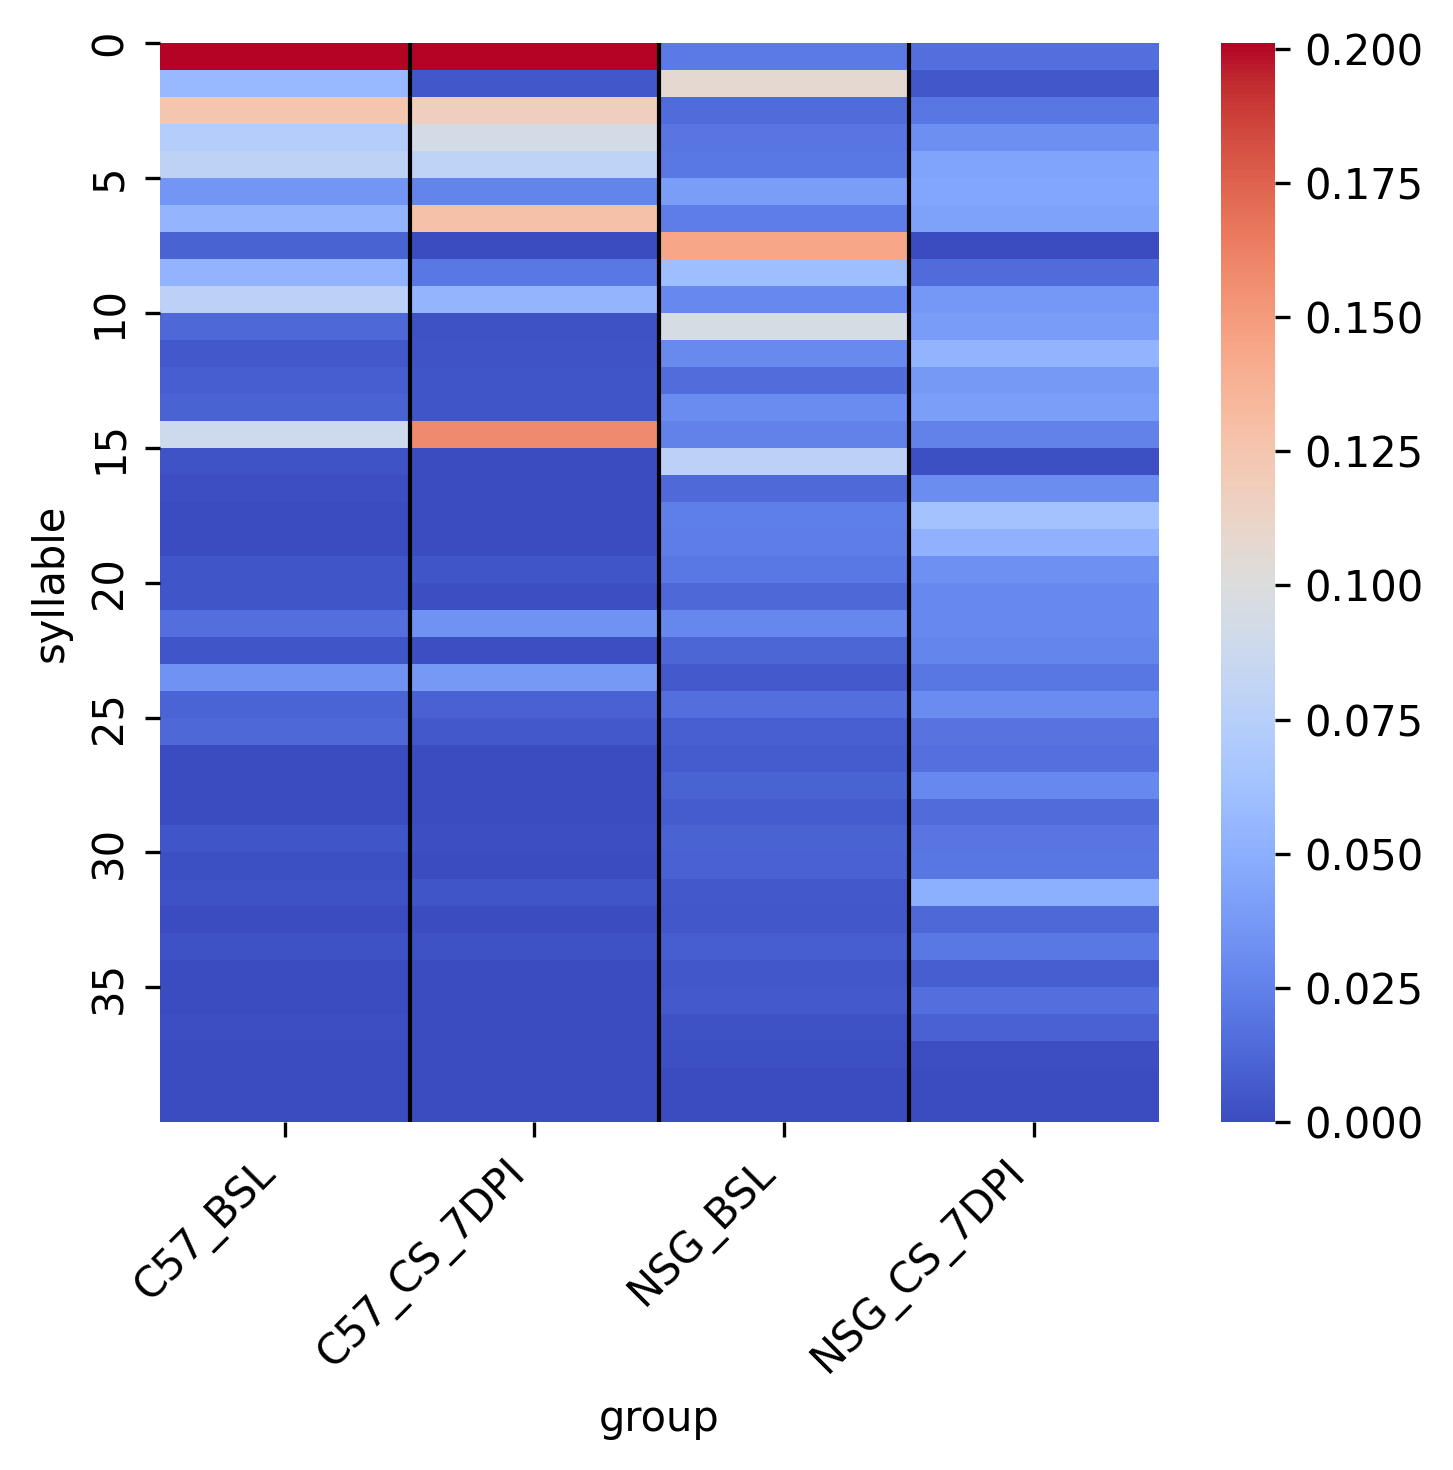

In [63]:
plt.figure(figsize=(5, 5), dpi=300)

proportions = proportions[['C57_BSL', 'C57_CS_7DPI', 'NSG_BSL','NSG_CS_7DPI']]
ax = sns.heatmap(
    proportions,
    cbar=True,
    cmap='coolwarm'
)

# rotate x labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# add vertical separators between columns
for i in range(1, proportions.shape[1]):
    ax.axvline(i, linewidth=1, color='black')

yticks = np.arange(0, max(proportions.index), 5)
ax.set_yticks(yticks)
ax.set_yticklabels(yticks)

ax.set_xlabel("group")
ax.set_ylabel("syllable")

plt.tight_layout()
#plt.savefig(SAVE_PATH / 'HEATMAP_NSG_vs_Bl6_BSL_vs_Bl6_CS7dpi_All_Syllables-4groups.pdf')
plt.show()

## 4.2 Per-Cluster Syllable Usage Heatmaps

For each of the four behavioral clusters, plot a heatmap of mean syllable usage (averaged across animals per group). This shows which specific syllables within a cluster drive differences between groups.

In [51]:
usage = (
    moseq_df
    .groupby(["uuid", "group", "labels (usage sort)", "cluster"])
    .size()
    .rename("count")
    .reset_index()
)

# normalize within each session
usage["usage"] = usage.groupby("uuid")["count"].transform(lambda x: x / x.sum())

In [52]:
# helper function to get data
def get_heatmap_data(cluster_name):
    df = usage[usage["cluster"] == cluster_name]

    # mean usage across sessions
    mean_usage = (
        df.groupby(["labels (usage sort)", "group"])["usage"]
        .mean()
        .unstack(fill_value=0)
    )

    # enforce column order
    return mean_usage[["C57_BSL", "C57_CS_7DPI", "NSG_BSL", "NSG_CS_7DPI"]]

In [38]:
usage['group'].unique()

array(['NSG_CS_7DPI', 'NSG_BSL', 'C57_CS_7DPI', 'C57_BSL'], dtype=object)

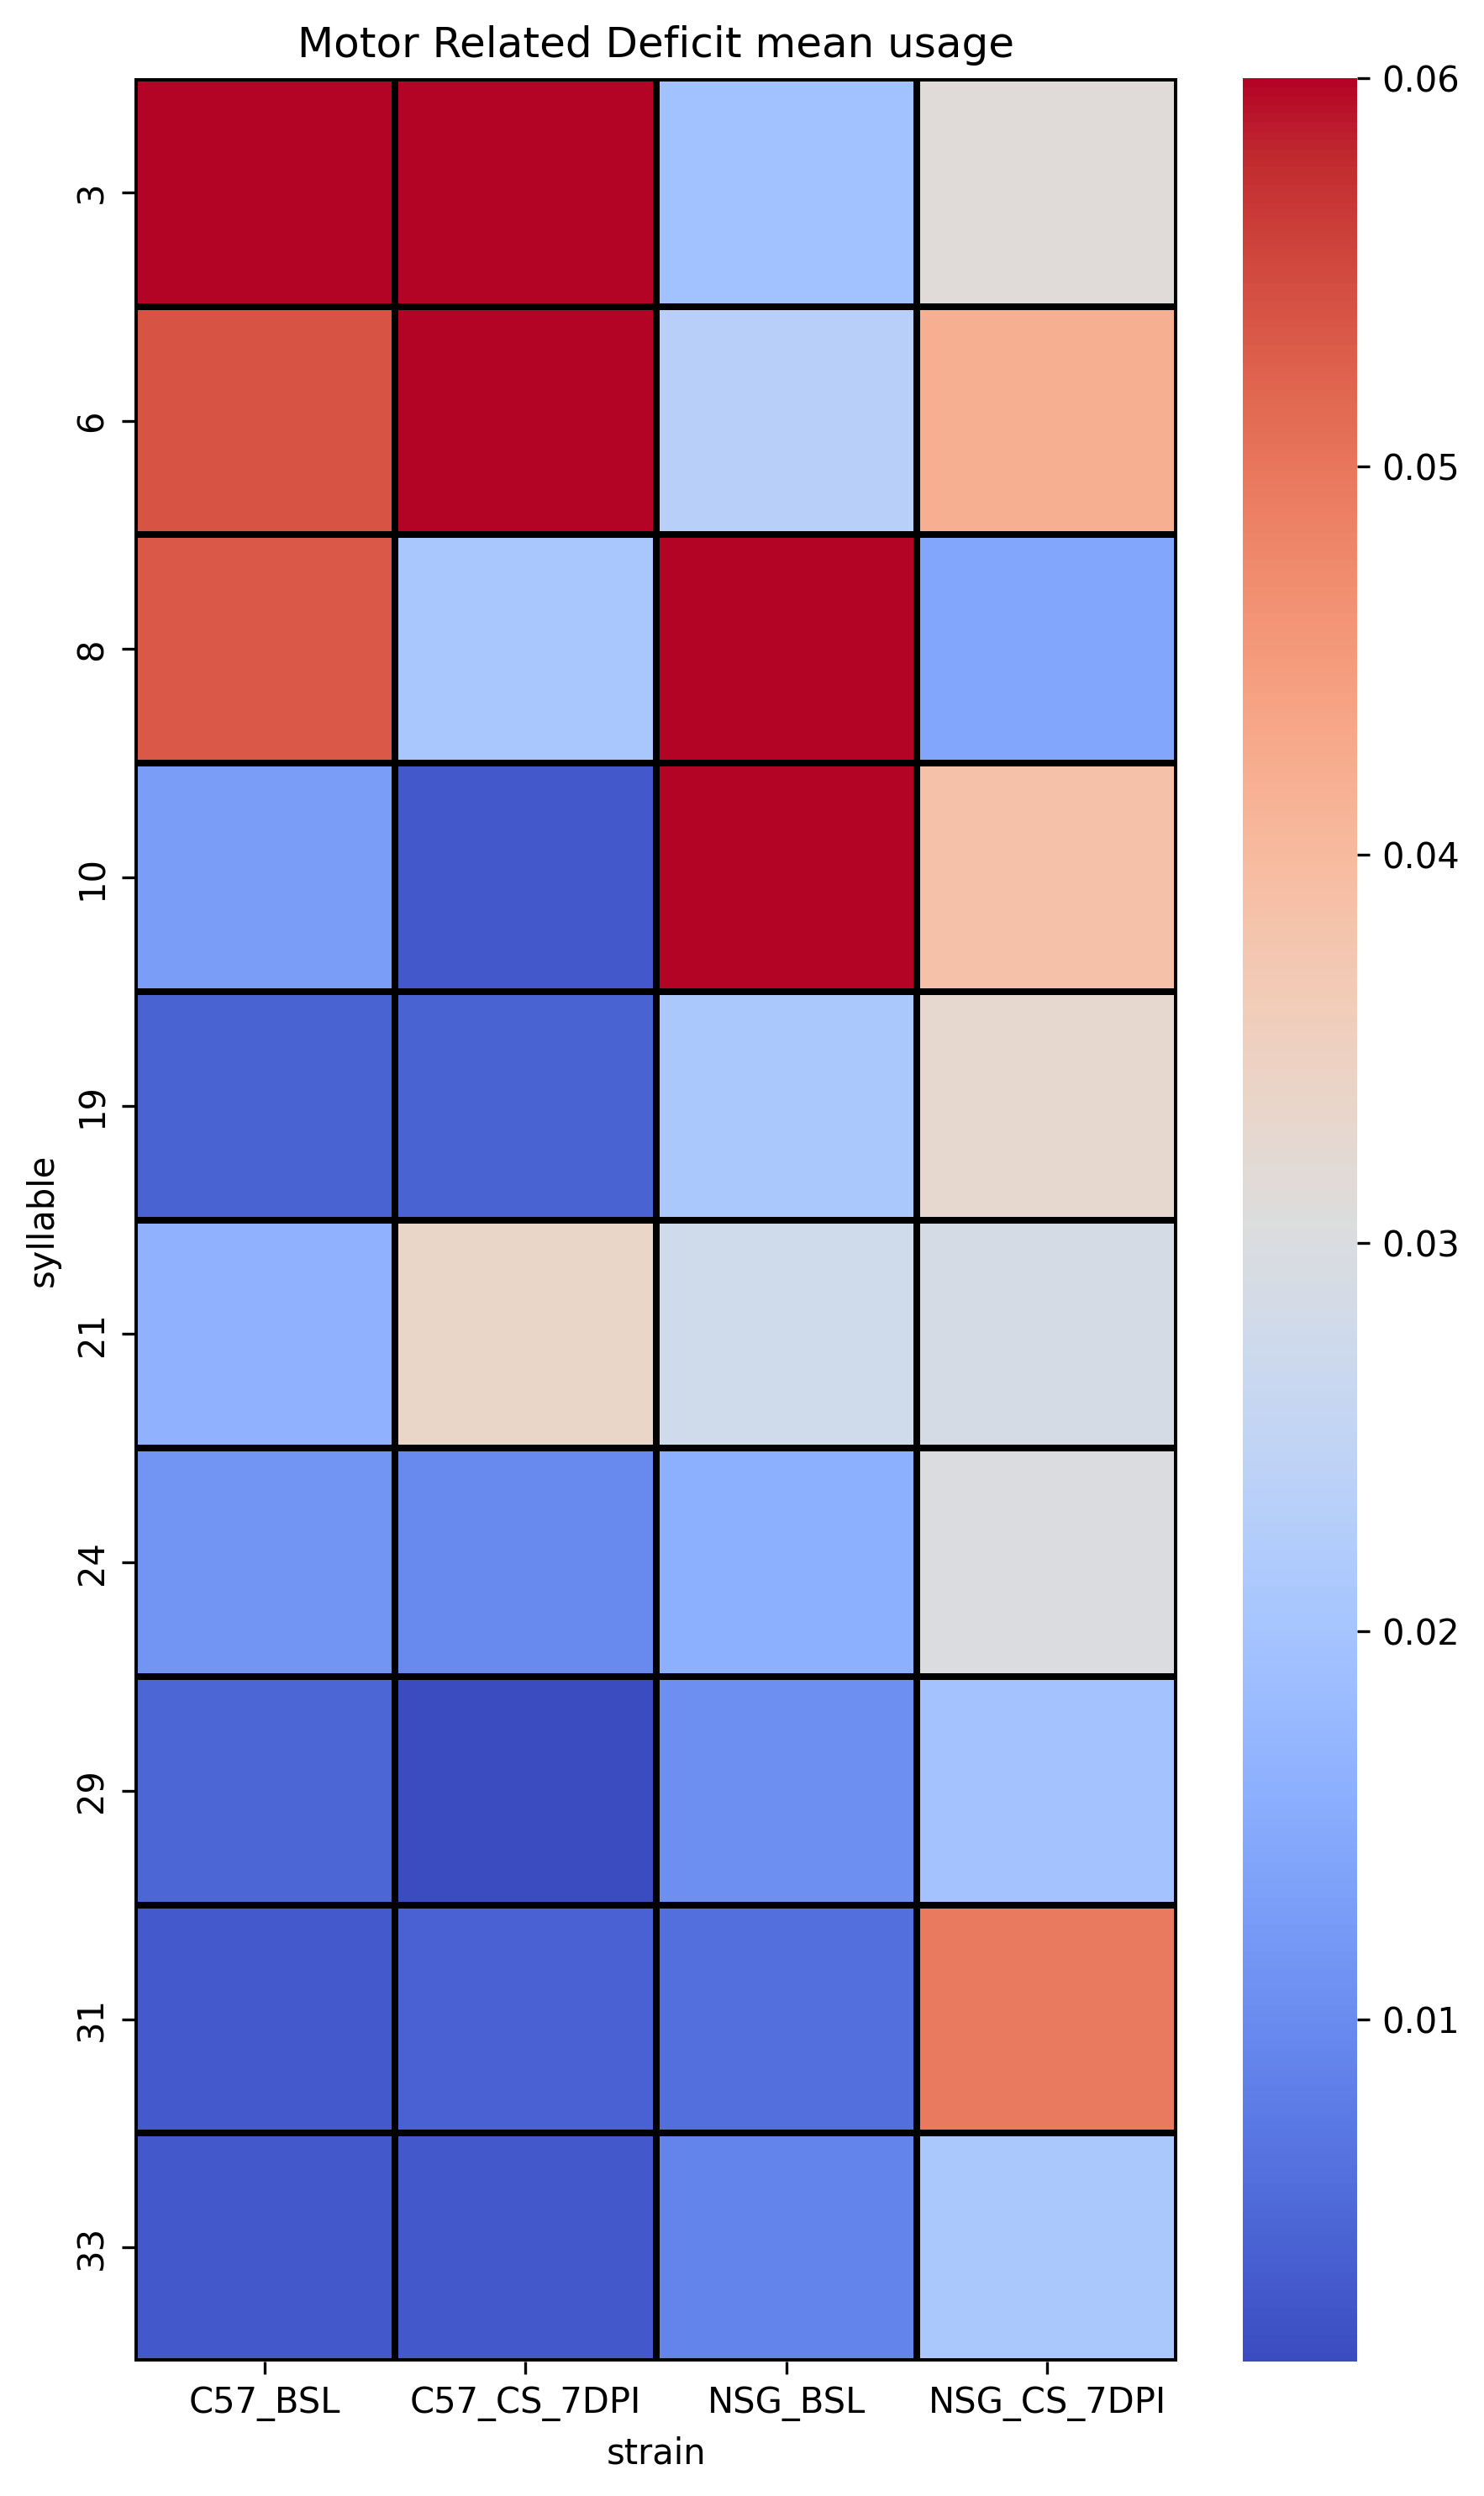

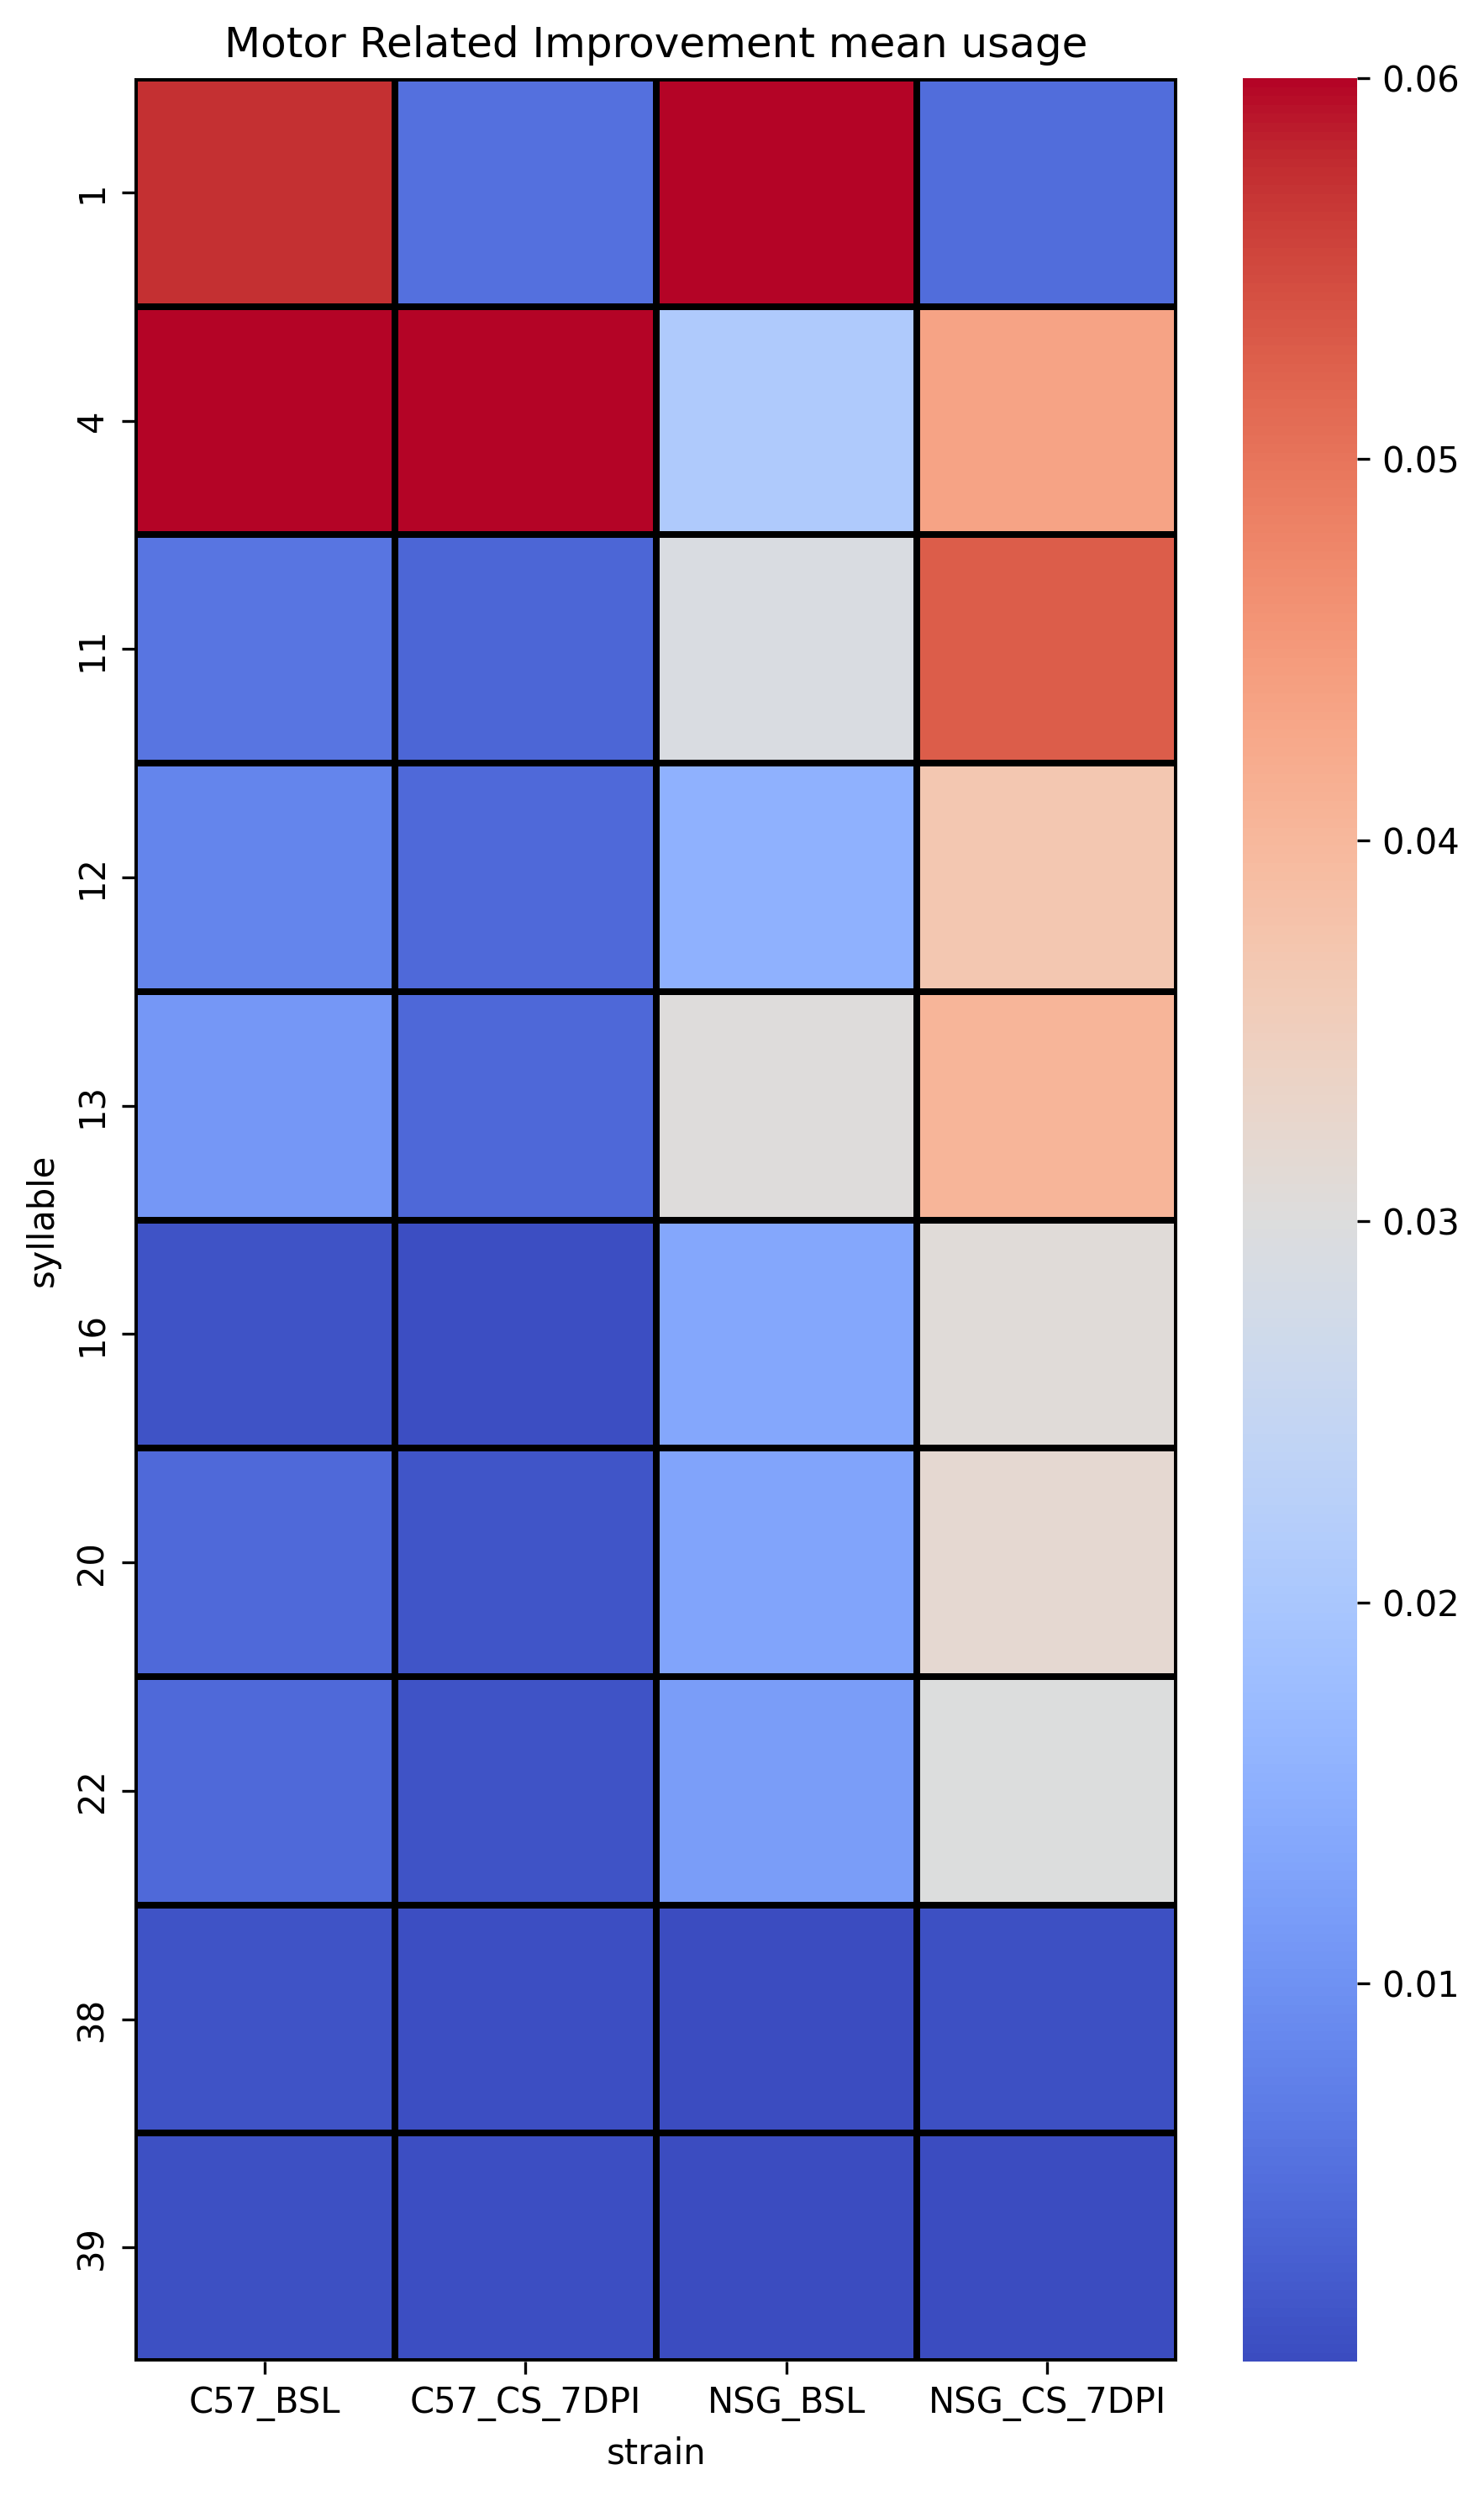

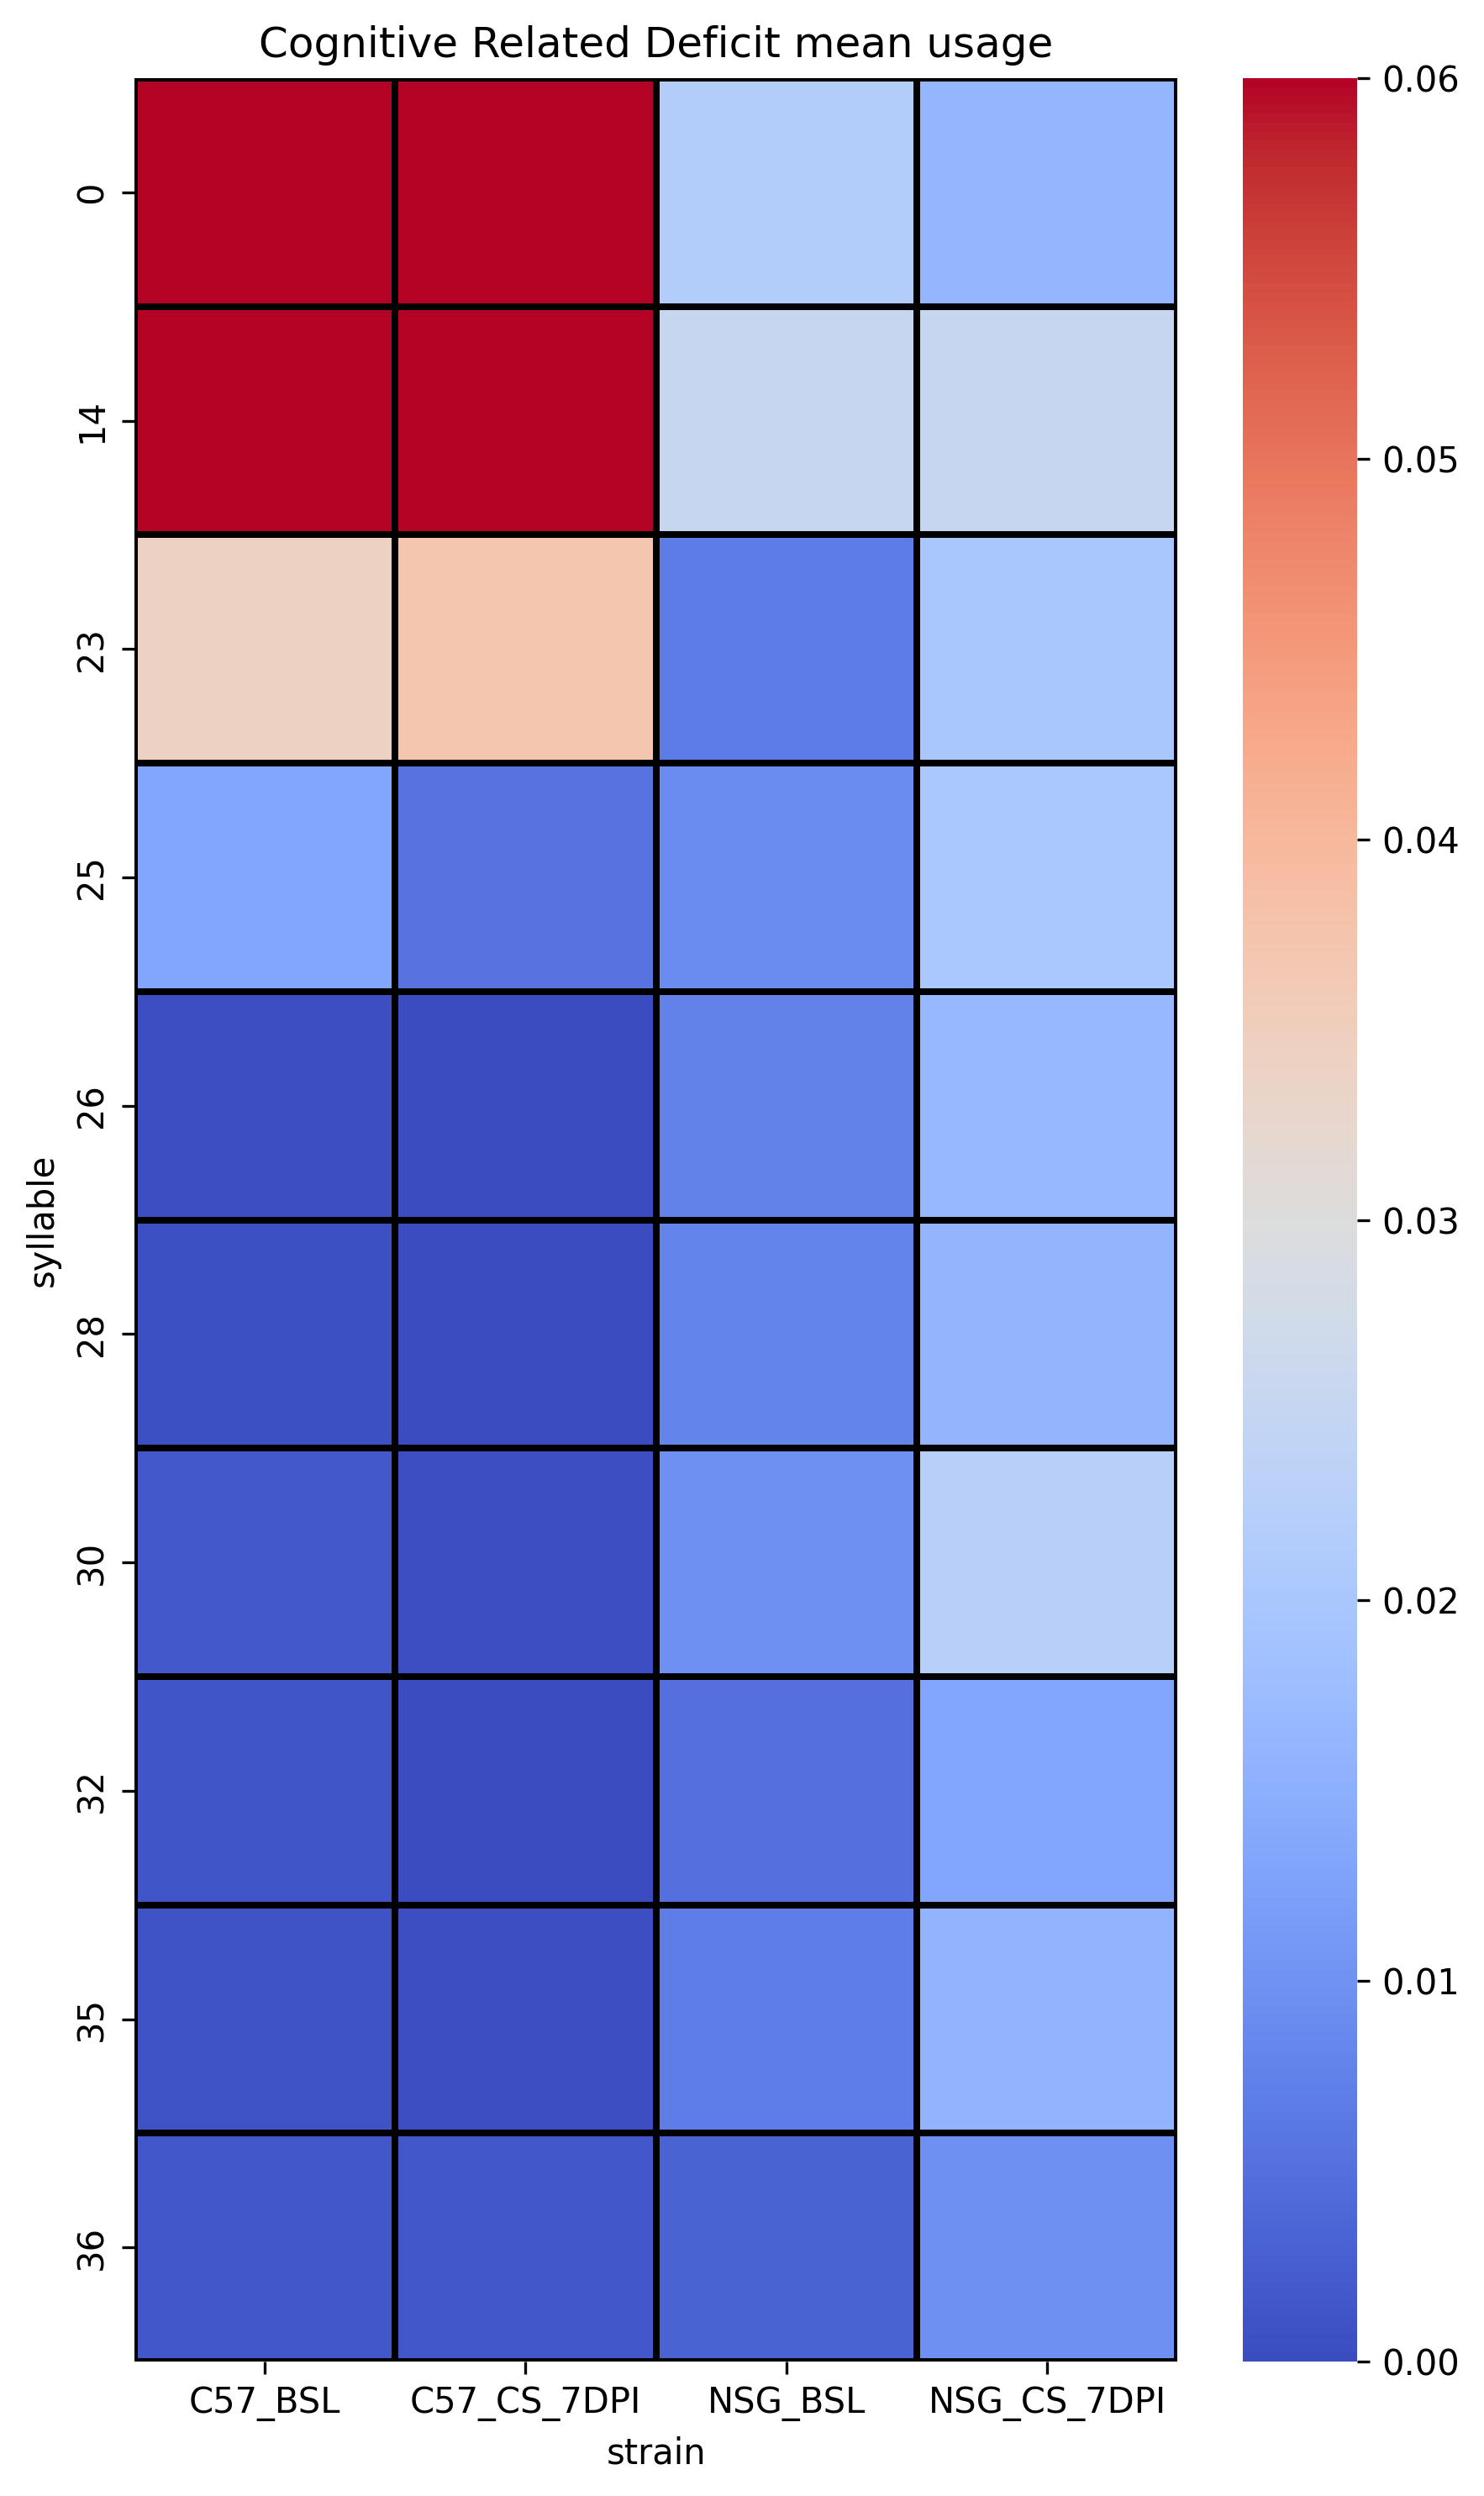

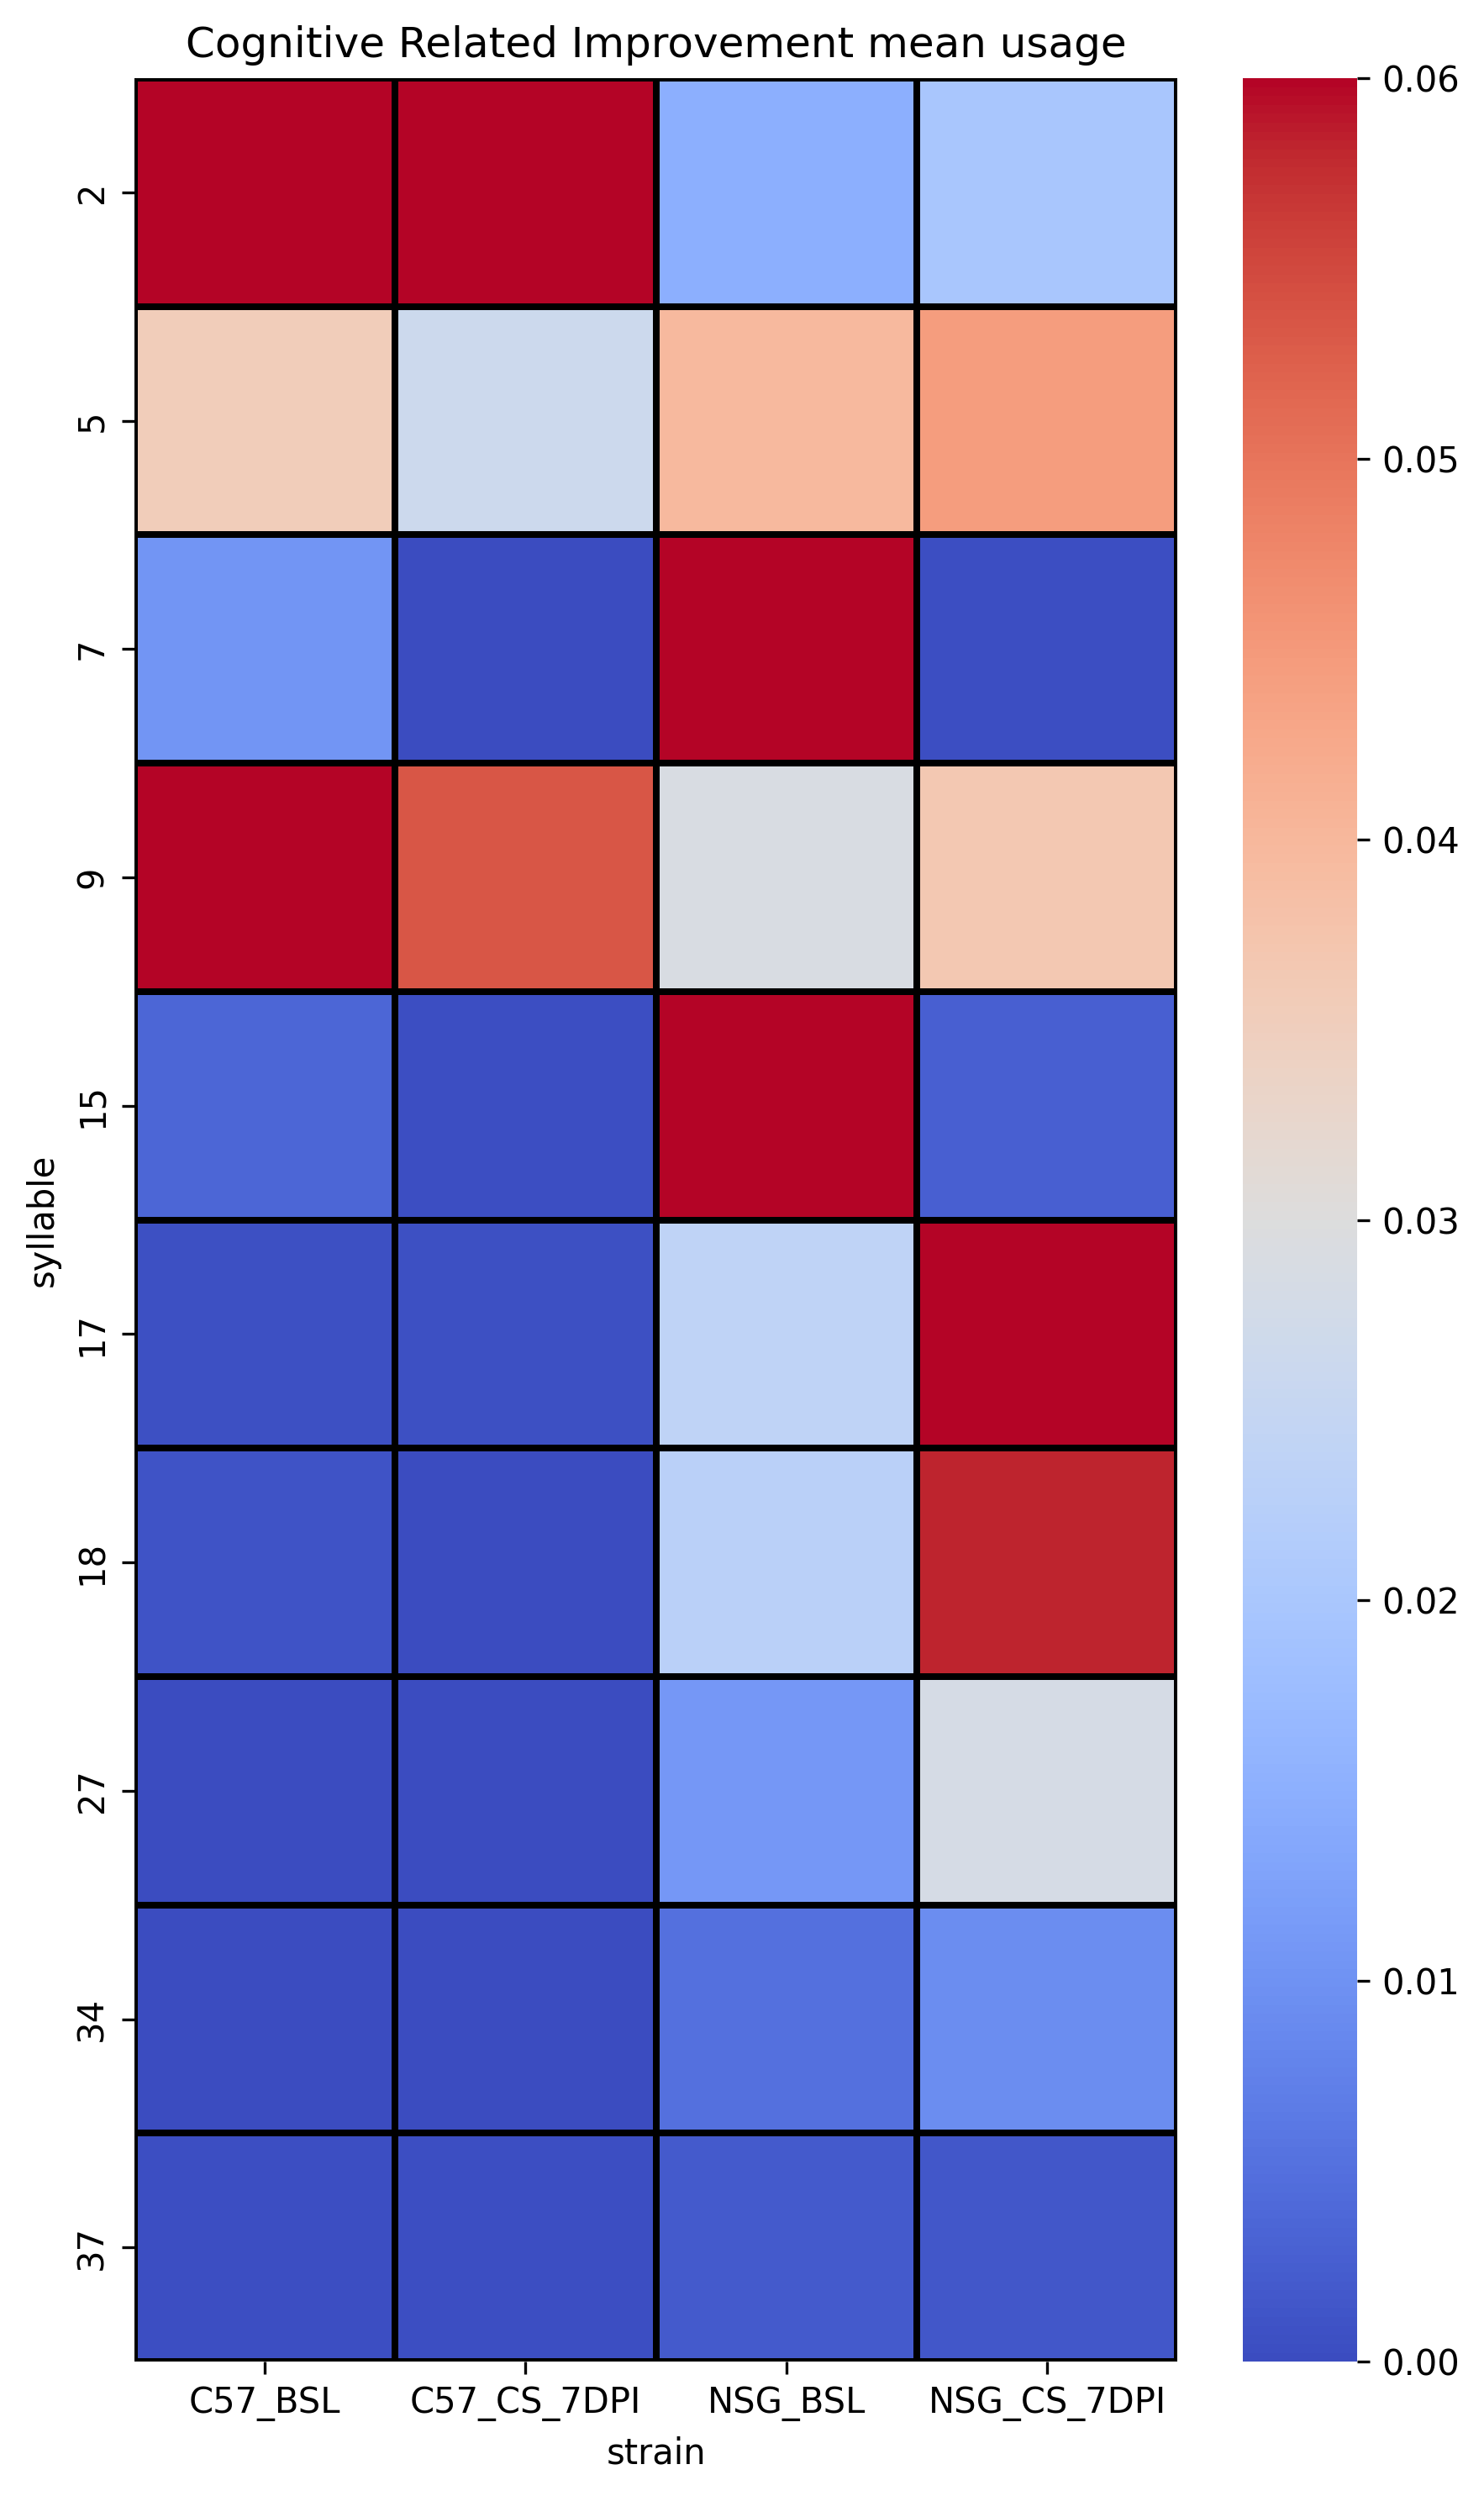

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_map = {
    "high_disp_low_vel": "Motor Related Deficit",
    "high_disp_high_vel": "Motor Related Improvement",
    "low_disp_low_vel": "Cognitive Related Deficit",
    "low_disp_high_vel": "Cognitive Related Improvement",
}

for cluster_name, title in cluster_map.items():
    data = get_heatmap_data(cluster_name)

    plt.figure(figsize=(6, 10),dpi=300)

    sns.heatmap(
        data,
        cmap="coolwarm",
        linewidths=1.5,
        linecolor="black",
        vmax=0.06,
        cbar=True
    )


    plt.title(f"{title} mean usage")
    plt.xlabel("strain")
    plt.ylabel("syllable")

    plt.tight_layout()
    #plt.savefig(SAVE_PATH/f'{title}_usage_heatmap_4groups.pdf')
    plt.show()

In [54]:
animal_cluster_usage = (
    usage
    .groupby(["uuid", "group", "cluster"])["usage"]
    .sum()
    .reset_index()
)

## 4.3 Cluster Usage Bar Plots

Compute total cluster usage per animal by summing syllable usage within each cluster. This collapses the per-syllable heatmap into a single usage score per cluster per animal, enabling group-level statistical comparisons. Pairs tested: BSL vs. 7DPI within each strain, and BSL vs. BSL / 7DPI vs. 7DPI between strains.

In [55]:
print(usage.groupby("cluster")["labels (usage sort)"].unique())

cluster
high_disp_high_vel     [1, 4, 11, 12, 13, 16, 20, 22, 38, 39]
high_disp_low_vel       [3, 6, 8, 10, 19, 21, 24, 29, 31, 33]
low_disp_high_vel        [2, 5, 7, 9, 15, 17, 18, 27, 34, 37]
low_disp_low_vel      [0, 14, 23, 25, 26, 28, 30, 32, 35, 36]
Name: labels (usage sort), dtype: object


/tmp/ipykernel_2122/2861284931.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: t-test independent samples, P_val:1.418e-02 t=-2.700e+00
NSG_BSL vs. NSG_CS_7DPI: t-test independent samples, P_val:4.136e-01 t=-8.254e-01
C57_BSL vs. NSG_BSL: t-test independent samples, P_val:3.041e-03 t=-3.133e+00
C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:8.490e-01 t=-1.932e-01


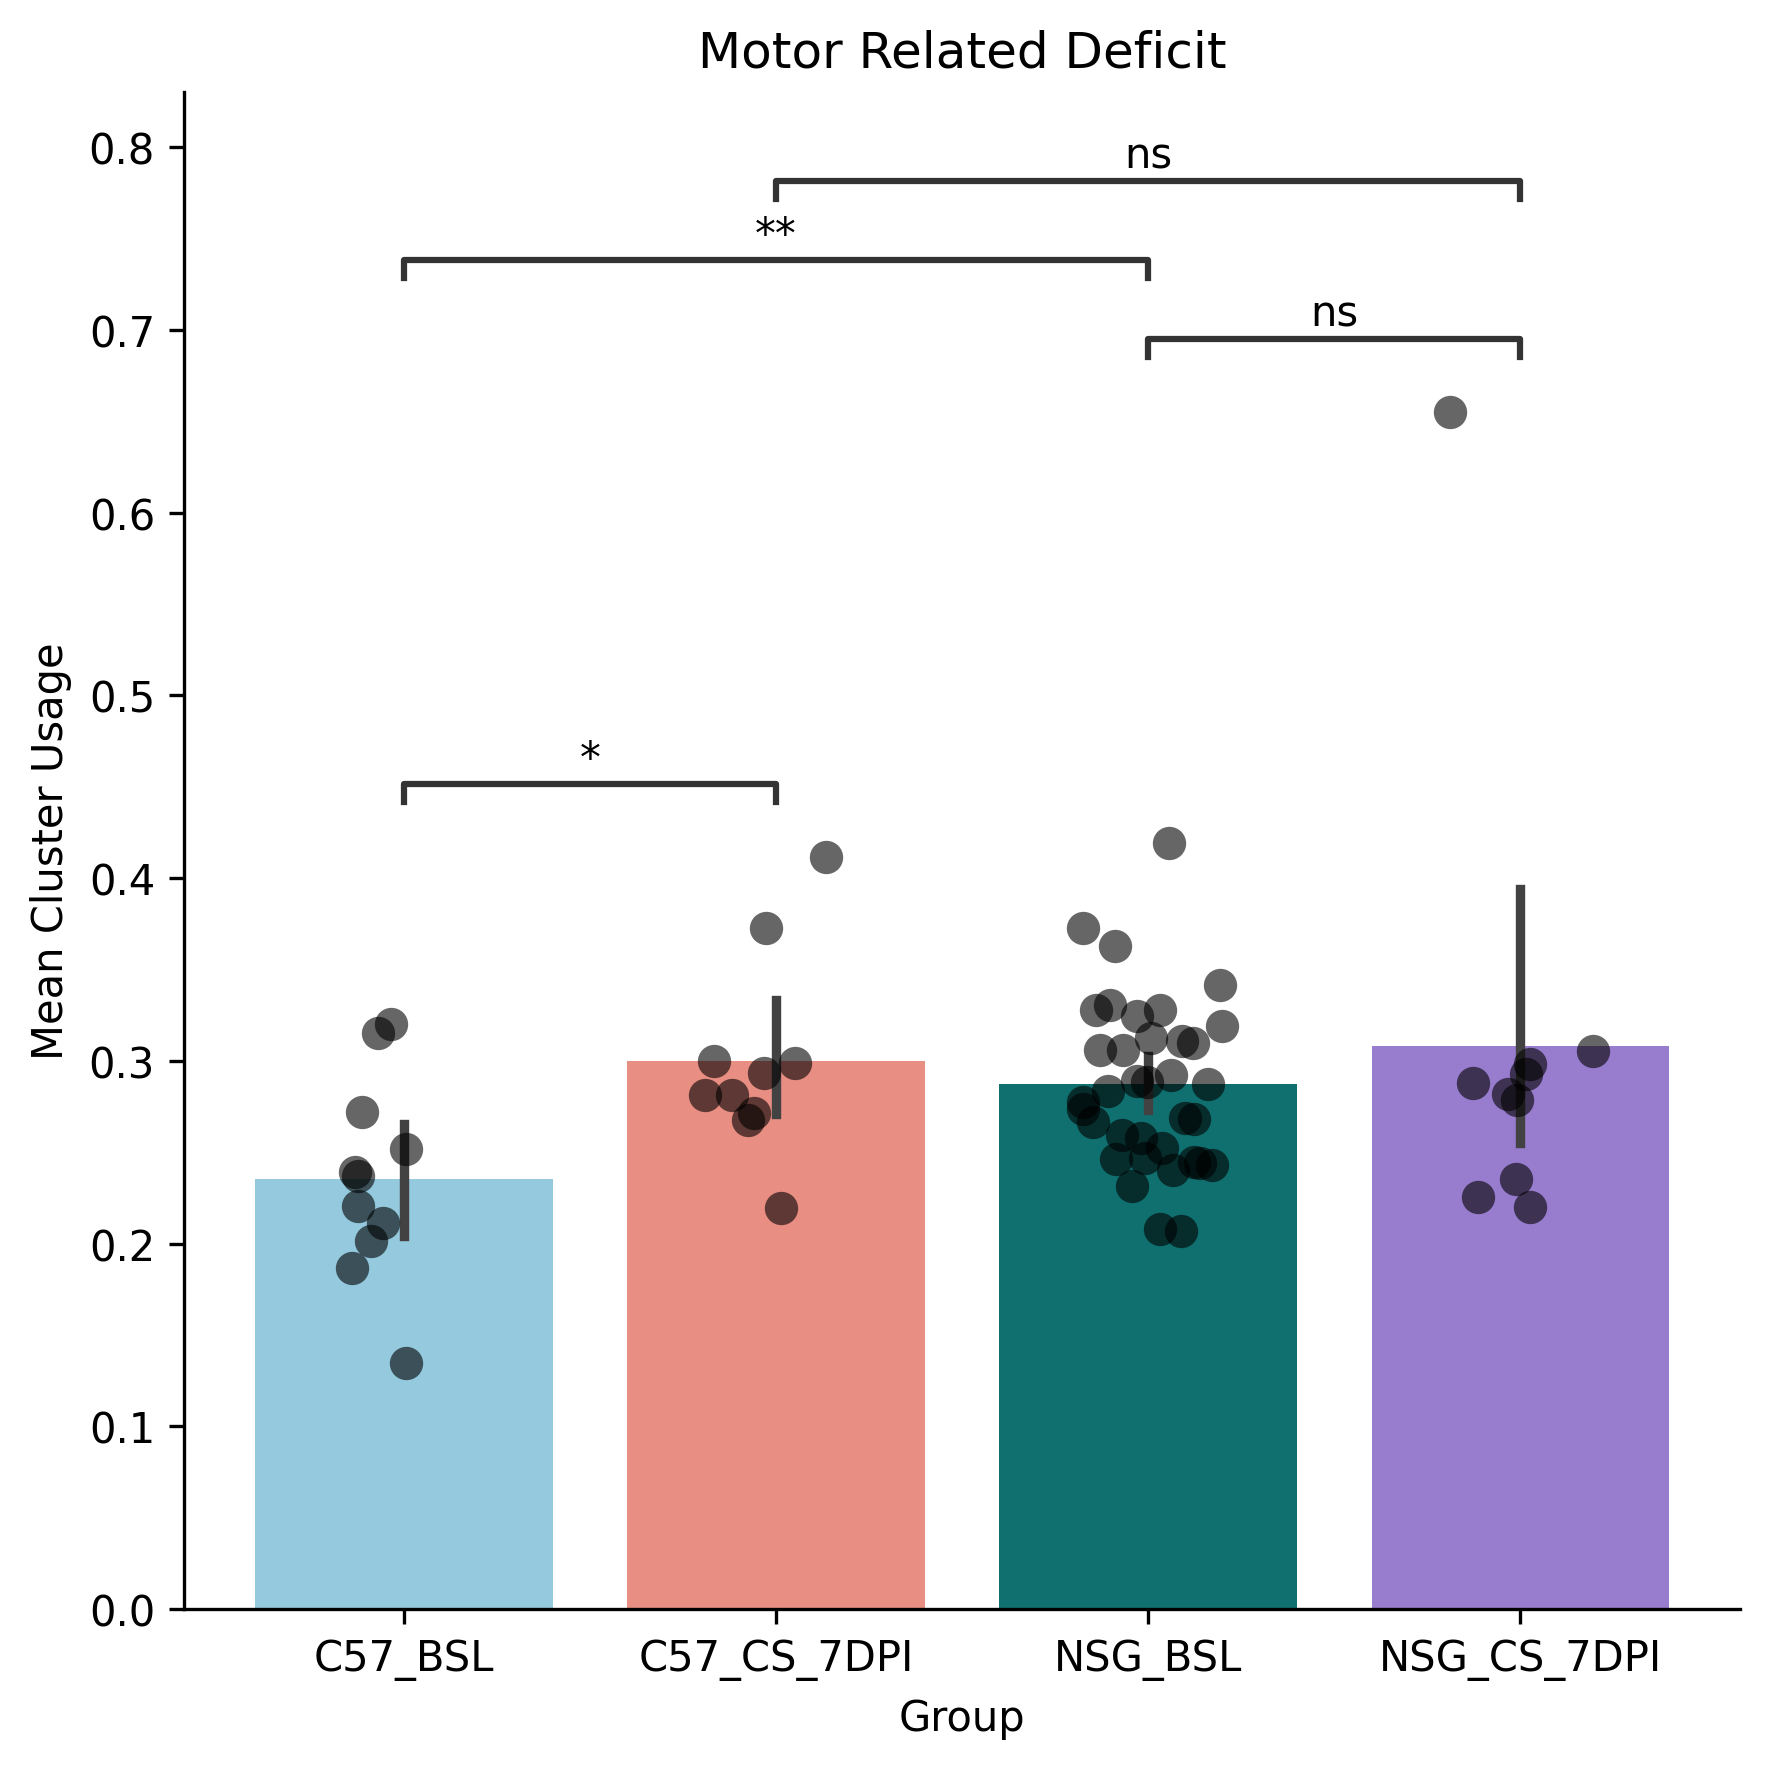

/tmp/ipykernel_2122/2861284931.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: t-test independent samples, P_val:1.777e-04 t=4.642e+00
NSG_BSL vs. NSG_CS_7DPI: t-test independent samples, P_val:1.665e-01 t=-1.407e+00
C57_BSL vs. NSG_BSL: t-test independent samples, P_val:5.033e-08 t=-6.533e+00
C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:2.614e-05 t=-5.594e+00


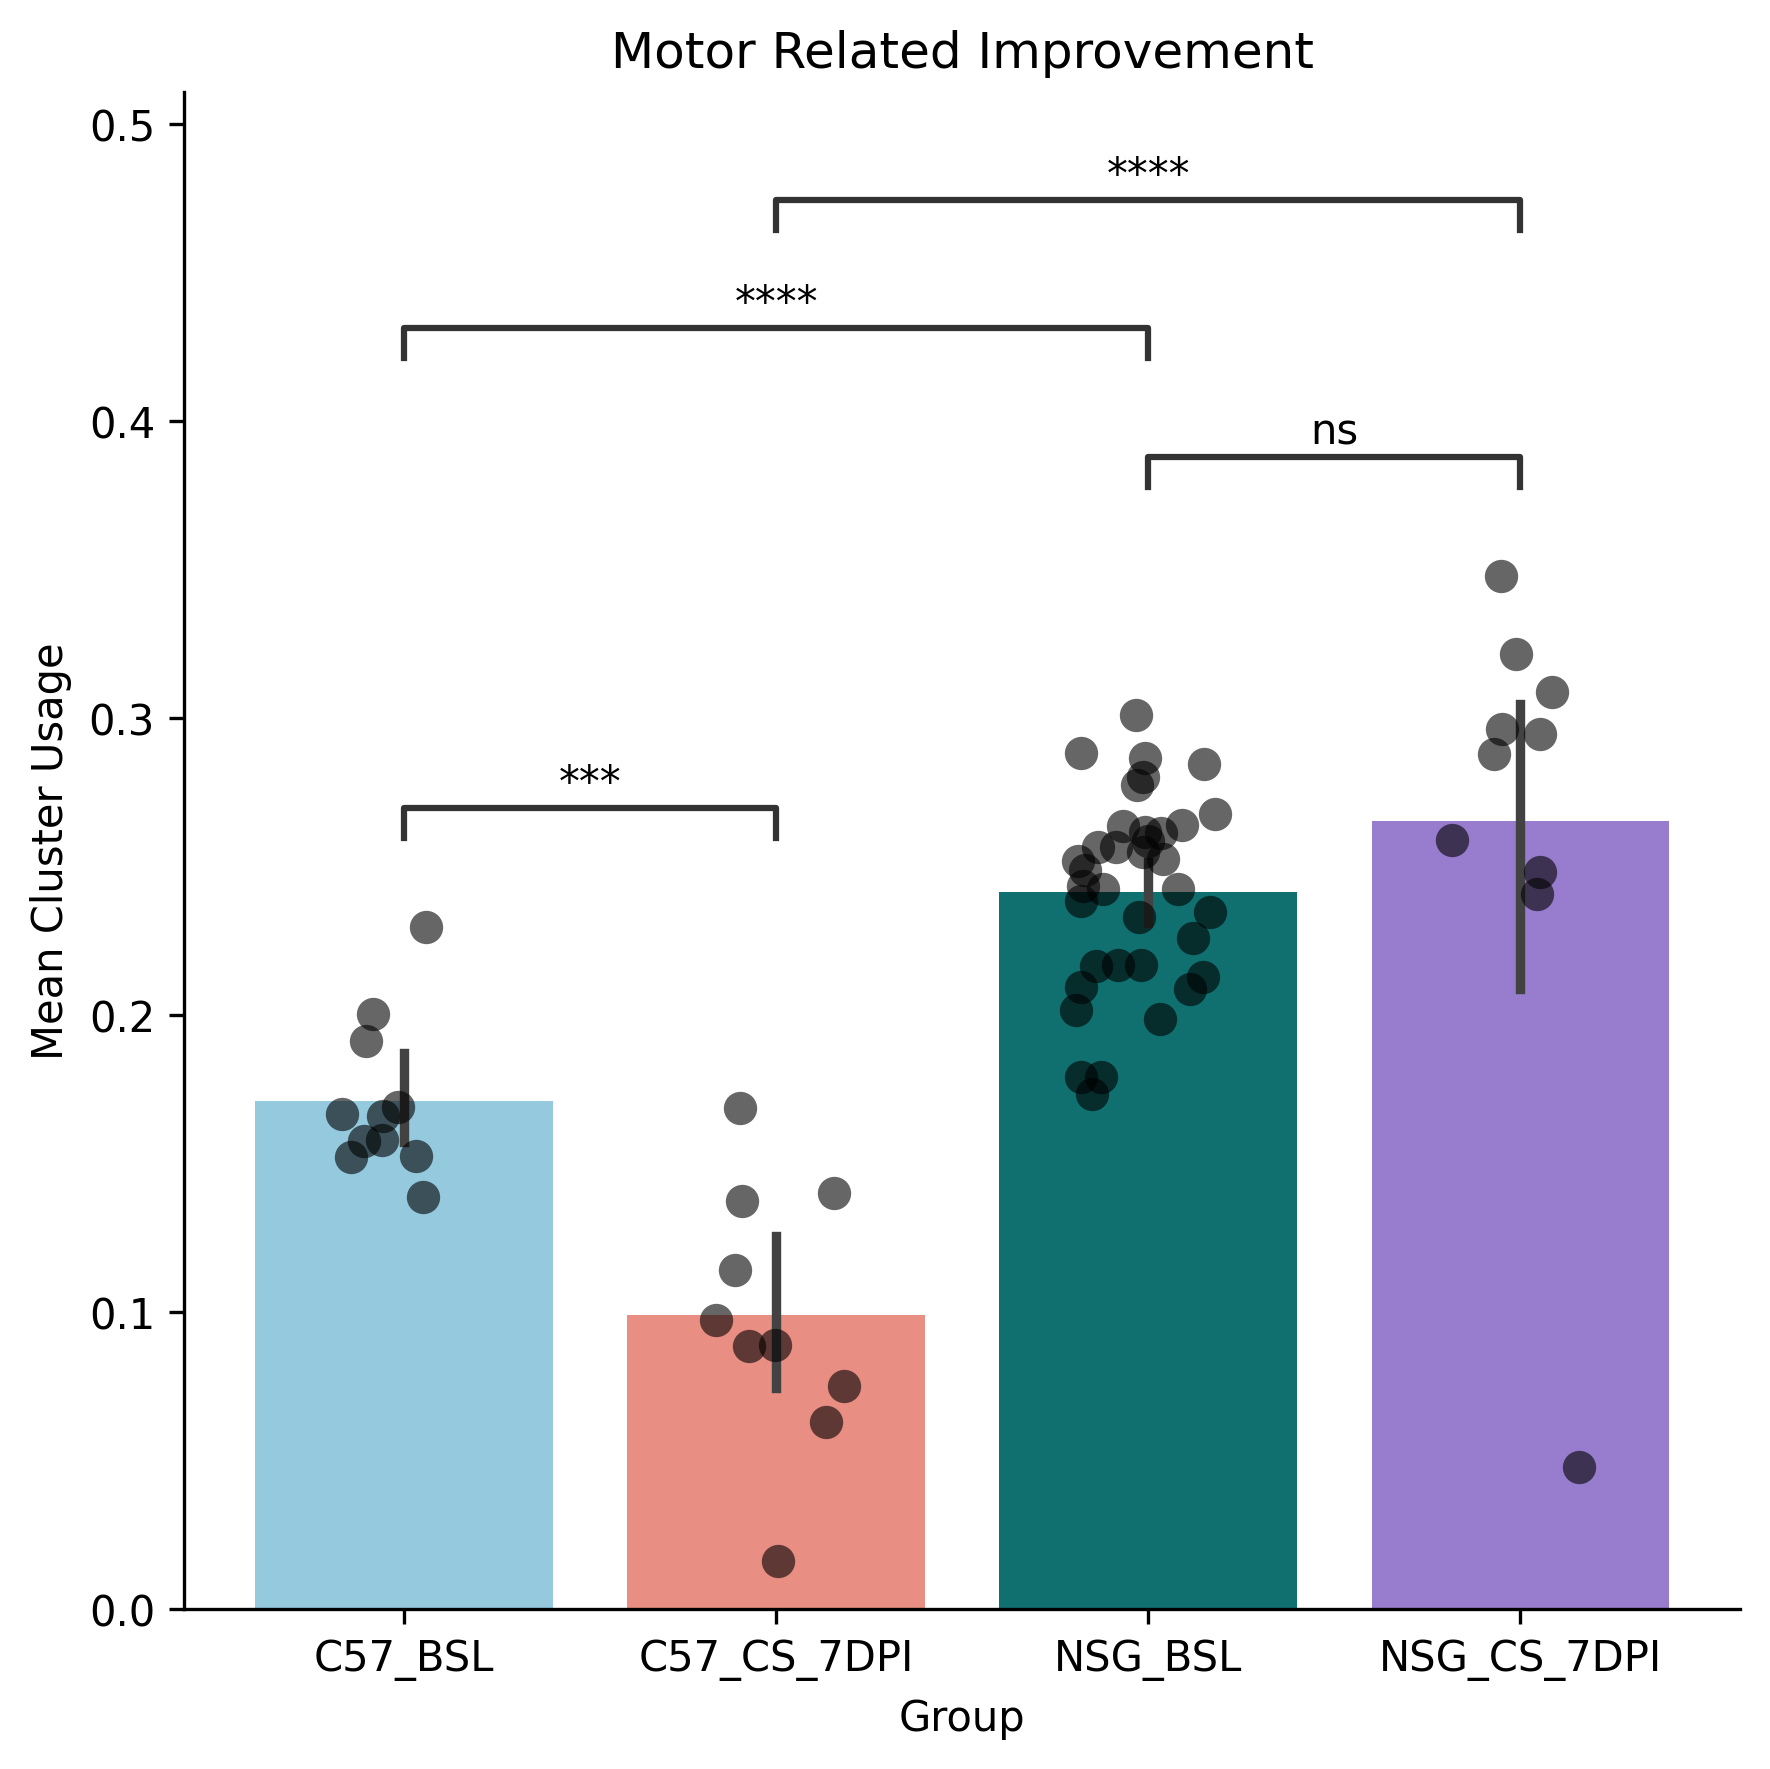

/tmp/ipykernel_2122/2861284931.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: t-test independent samples, P_val:9.836e-02 t=-1.738e+00
NSG_BSL vs. NSG_CS_7DPI: t-test independent samples, P_val:4.601e-05 t=-4.521e+00
C57_BSL vs. NSG_BSL: t-test independent samples, P_val:5.911e-23 t=1.882e+01
C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:1.279e-05 t=5.939e+00


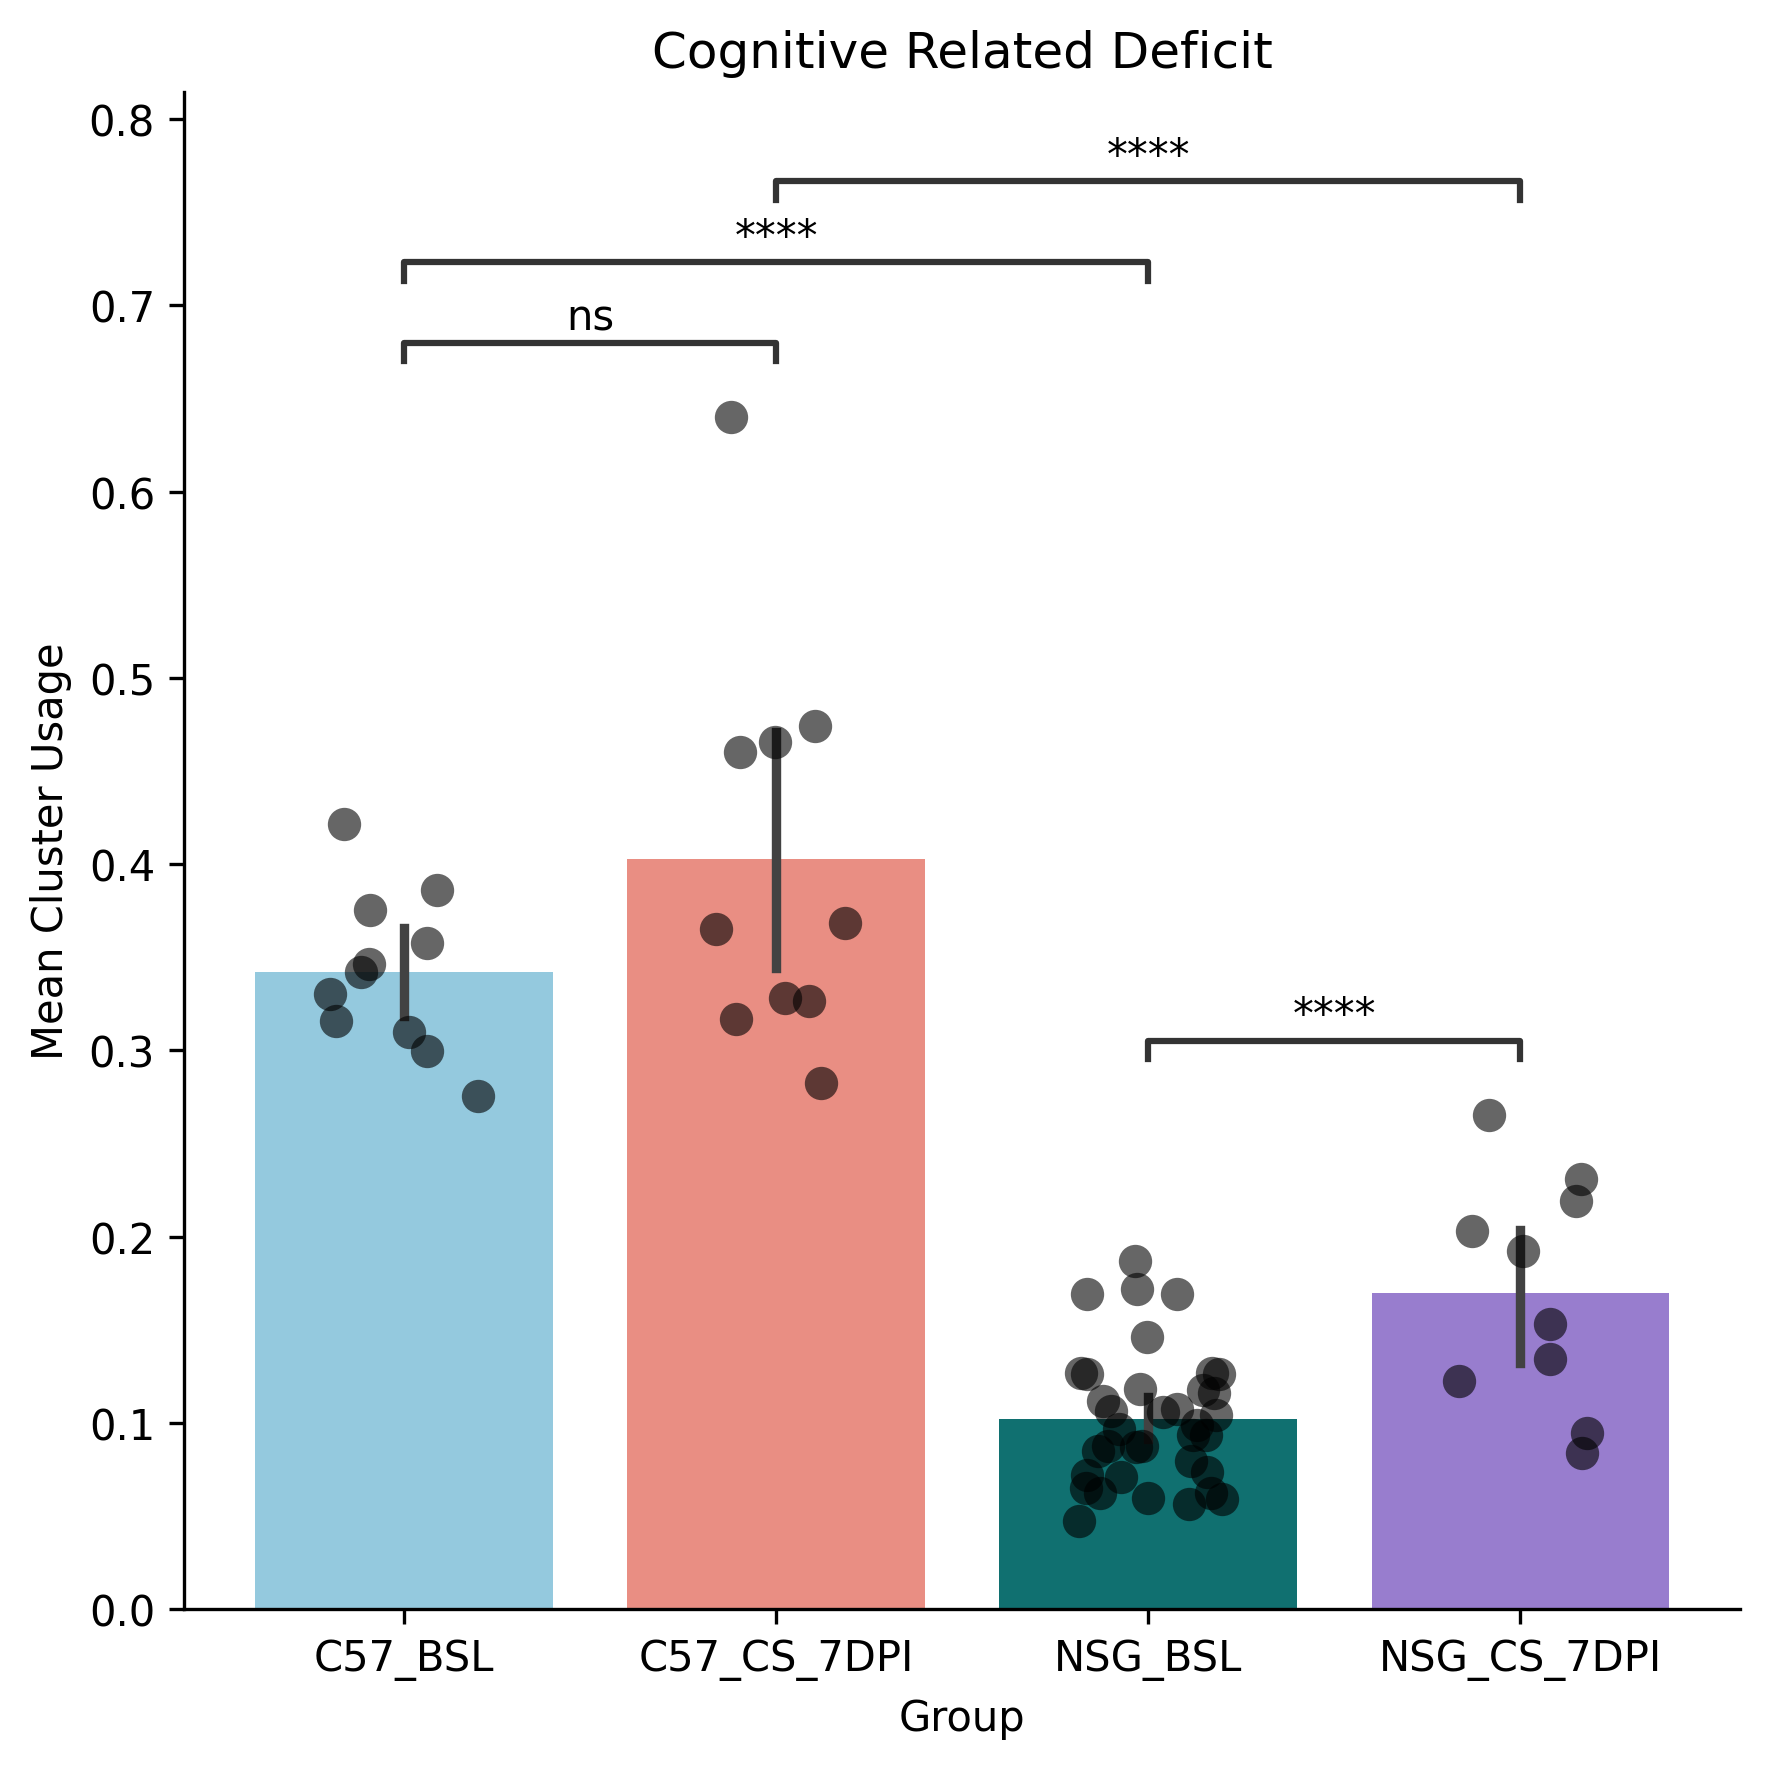

/tmp/ipykernel_2122/2861284931.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: t-test independent samples, P_val:7.685e-02 t=1.871e+00
NSG_BSL vs. NSG_CS_7DPI: t-test independent samples, P_val:5.858e-06 t=5.150e+00
C57_BSL vs. NSG_BSL: t-test independent samples, P_val:9.159e-09 t=-7.031e+00
C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:1.562e-01 t=-1.480e+00


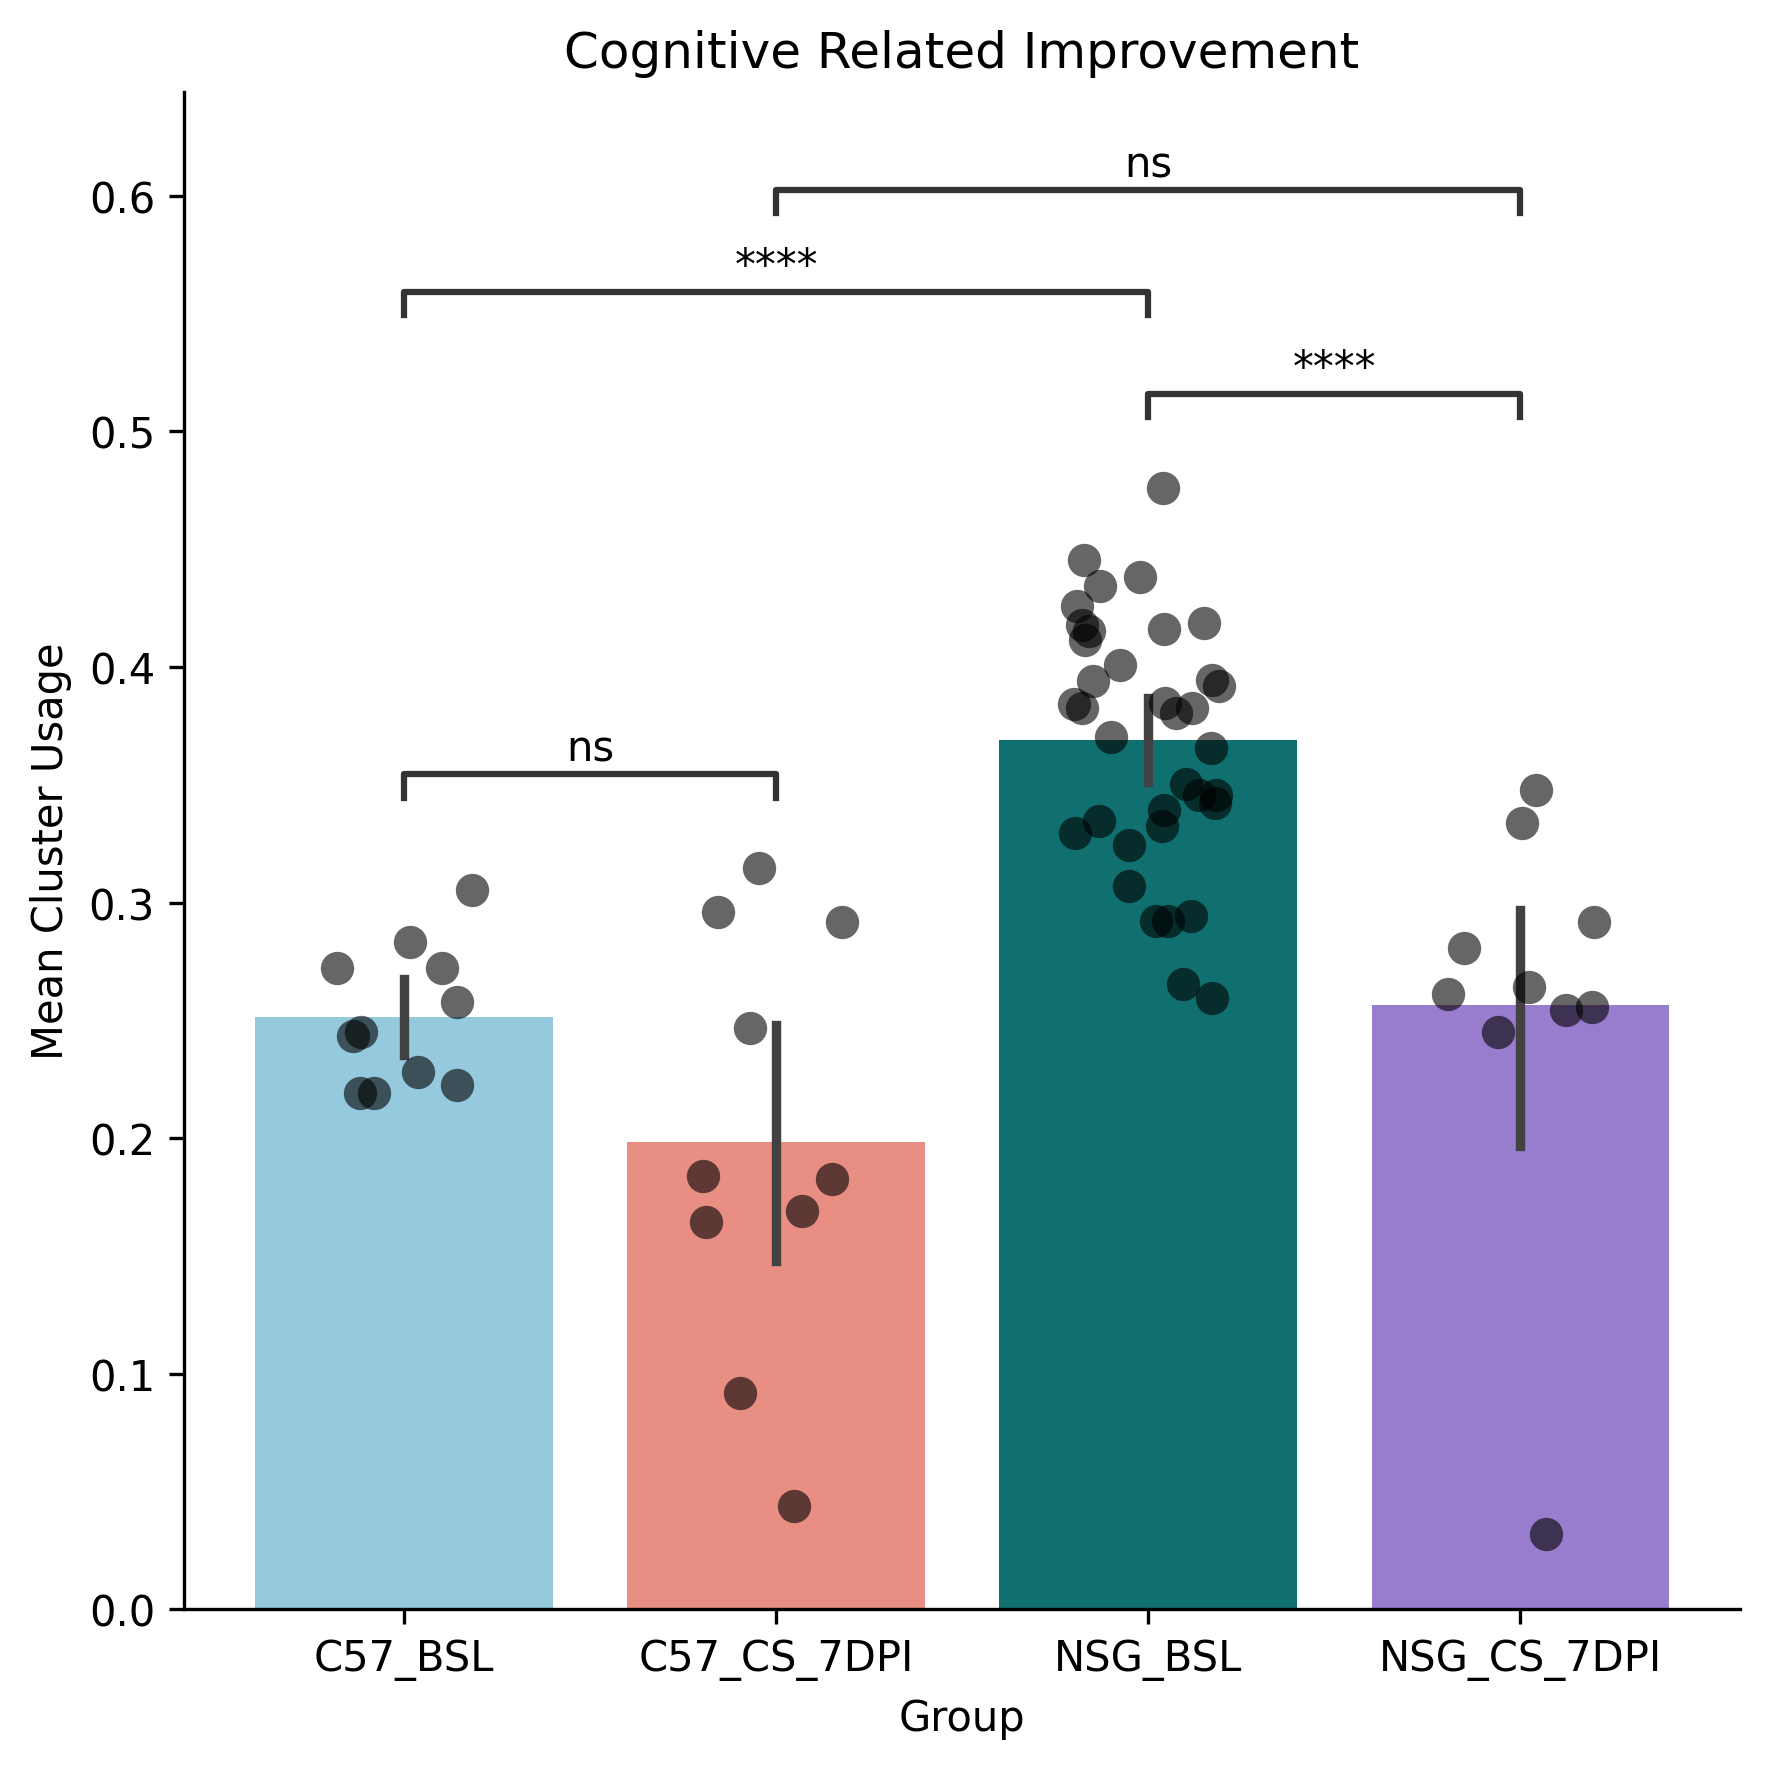

In [56]:
for cluster_name, title in cluster_map.items():
    data = animal_cluster_usage[animal_cluster_usage["cluster"] == cluster_name]
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    ax.set_ylim(0, 0.5)

    order = ["C57_BSL", "C57_CS_7DPI", "NSG_BSL", "NSG_CS_7DPI"]
    palette = {
        "C57_BSL": "skyblue",
        "C57_CS_7DPI": "salmon",
        "NSG_BSL": "Teal",
        "NSG_CS_7DPI": "mediumpurple"
    }

    sns.barplot(
        data=data,
        x="group", y="usage",
        order=order,
        palette=palette,
        zorder=1,
        ax=ax
    )
    sns.stripplot(
        data=data,
        x="group", y="usage",
        order=order,
        color="black", size=8, alpha=0.6, jitter=0.2,
        ax=ax
    )

    pairs = [
        ("C57_BSL", "C57_CS_7DPI"),
        ("NSG_BSL", "NSG_CS_7DPI"),
        ("C57_BSL", "NSG_BSL"),
        ("C57_CS_7DPI", "NSG_CS_7DPI"),
    ]

    annotator = Annotator(
        ax, pairs=pairs,
        data=data, x="group", y="usage", order=order
    )
    annotator.configure(test="t-test_ind", text_format="star", loc="inside", verbose=2)
    annotator.apply_and_annotate()

    ax.set_title(title)
    ax.set_xlabel("Group")
    ax.set_ylabel("Mean Cluster Usage")
    ax.set_ylim(bottom=0)
    sns.despine(ax=ax)
    plt.tight_layout()
    #plt.savefig(SAVE_PATH / f'{title}_NSG_vs_Bl6_BSL_Bl6_CS7dpi_cluster_usage_barchart.pdf', bbox_inches='tight')
    plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:2.155e-01 t=1.284e+00


/tmp/ipykernel_2122/1256983838.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


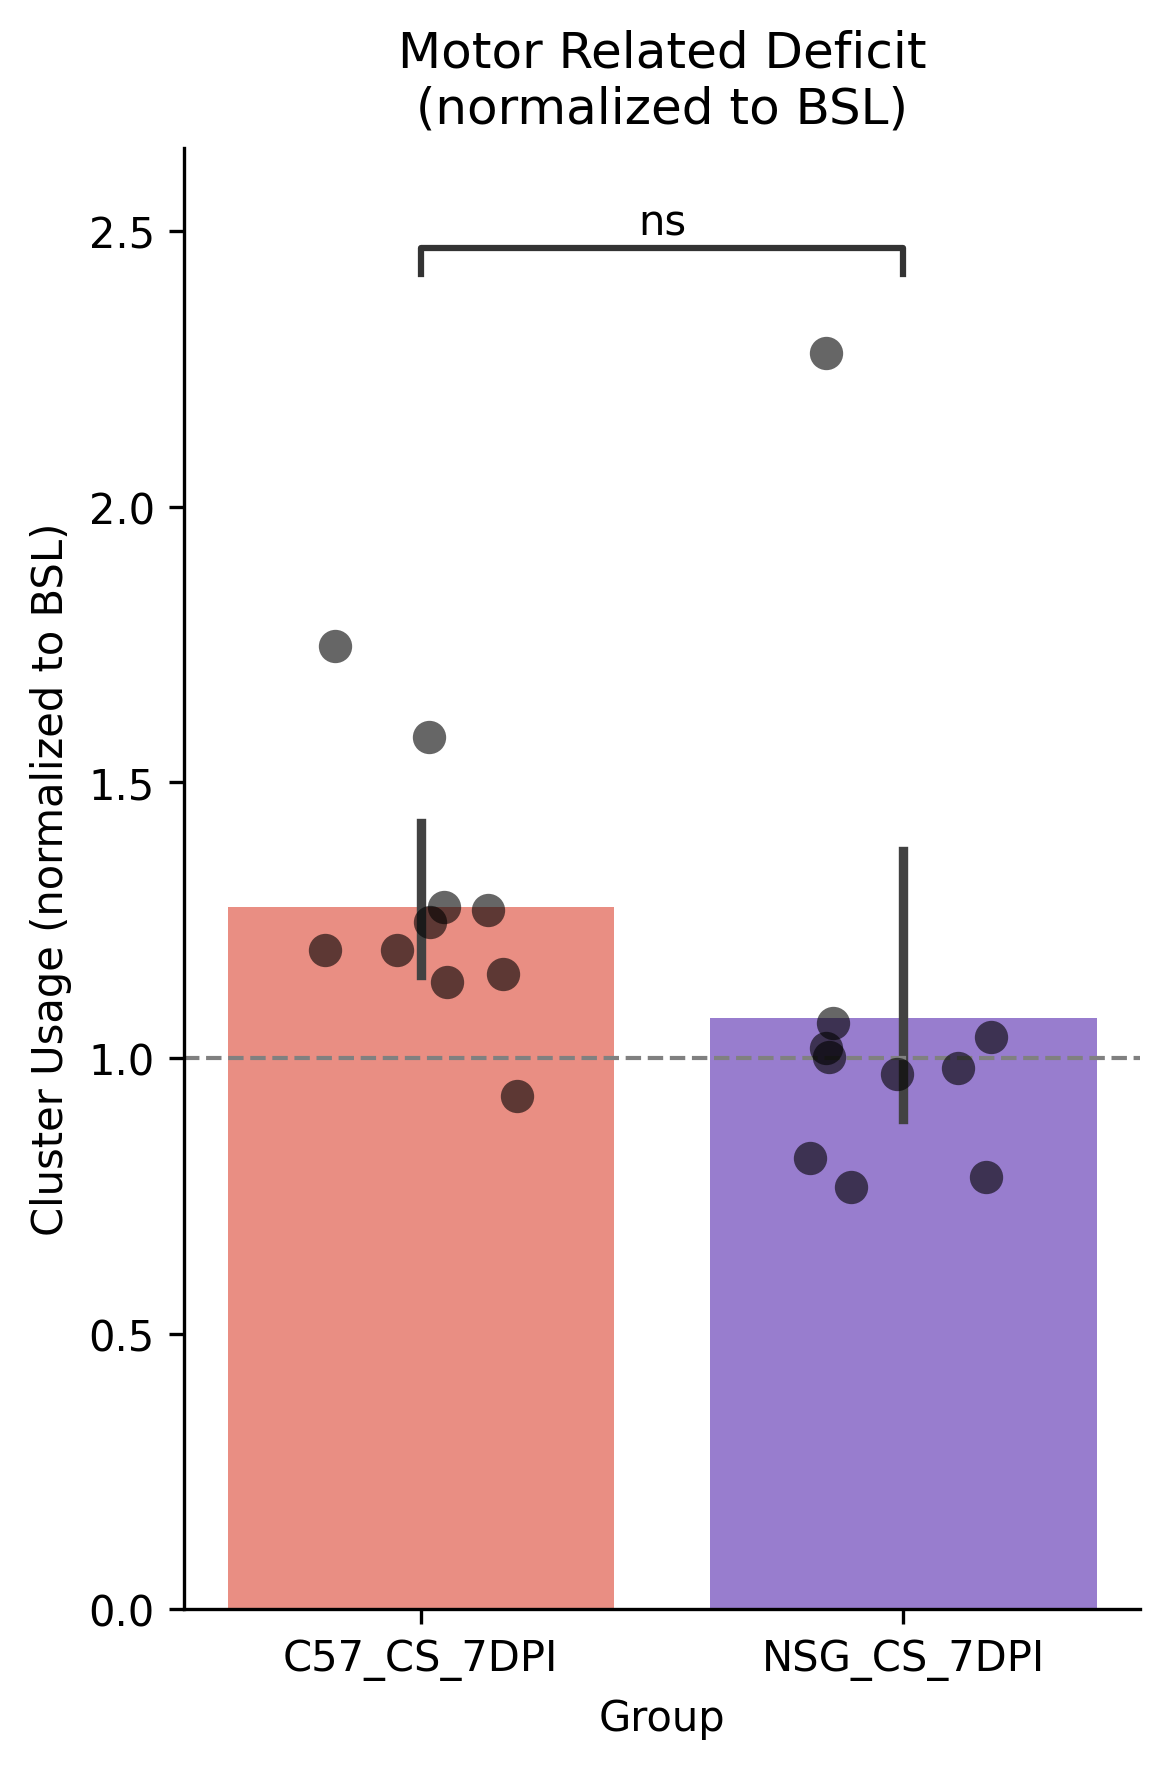

/tmp/ipykernel_2122/1256983838.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:1.211e-03 t=-3.836e+00


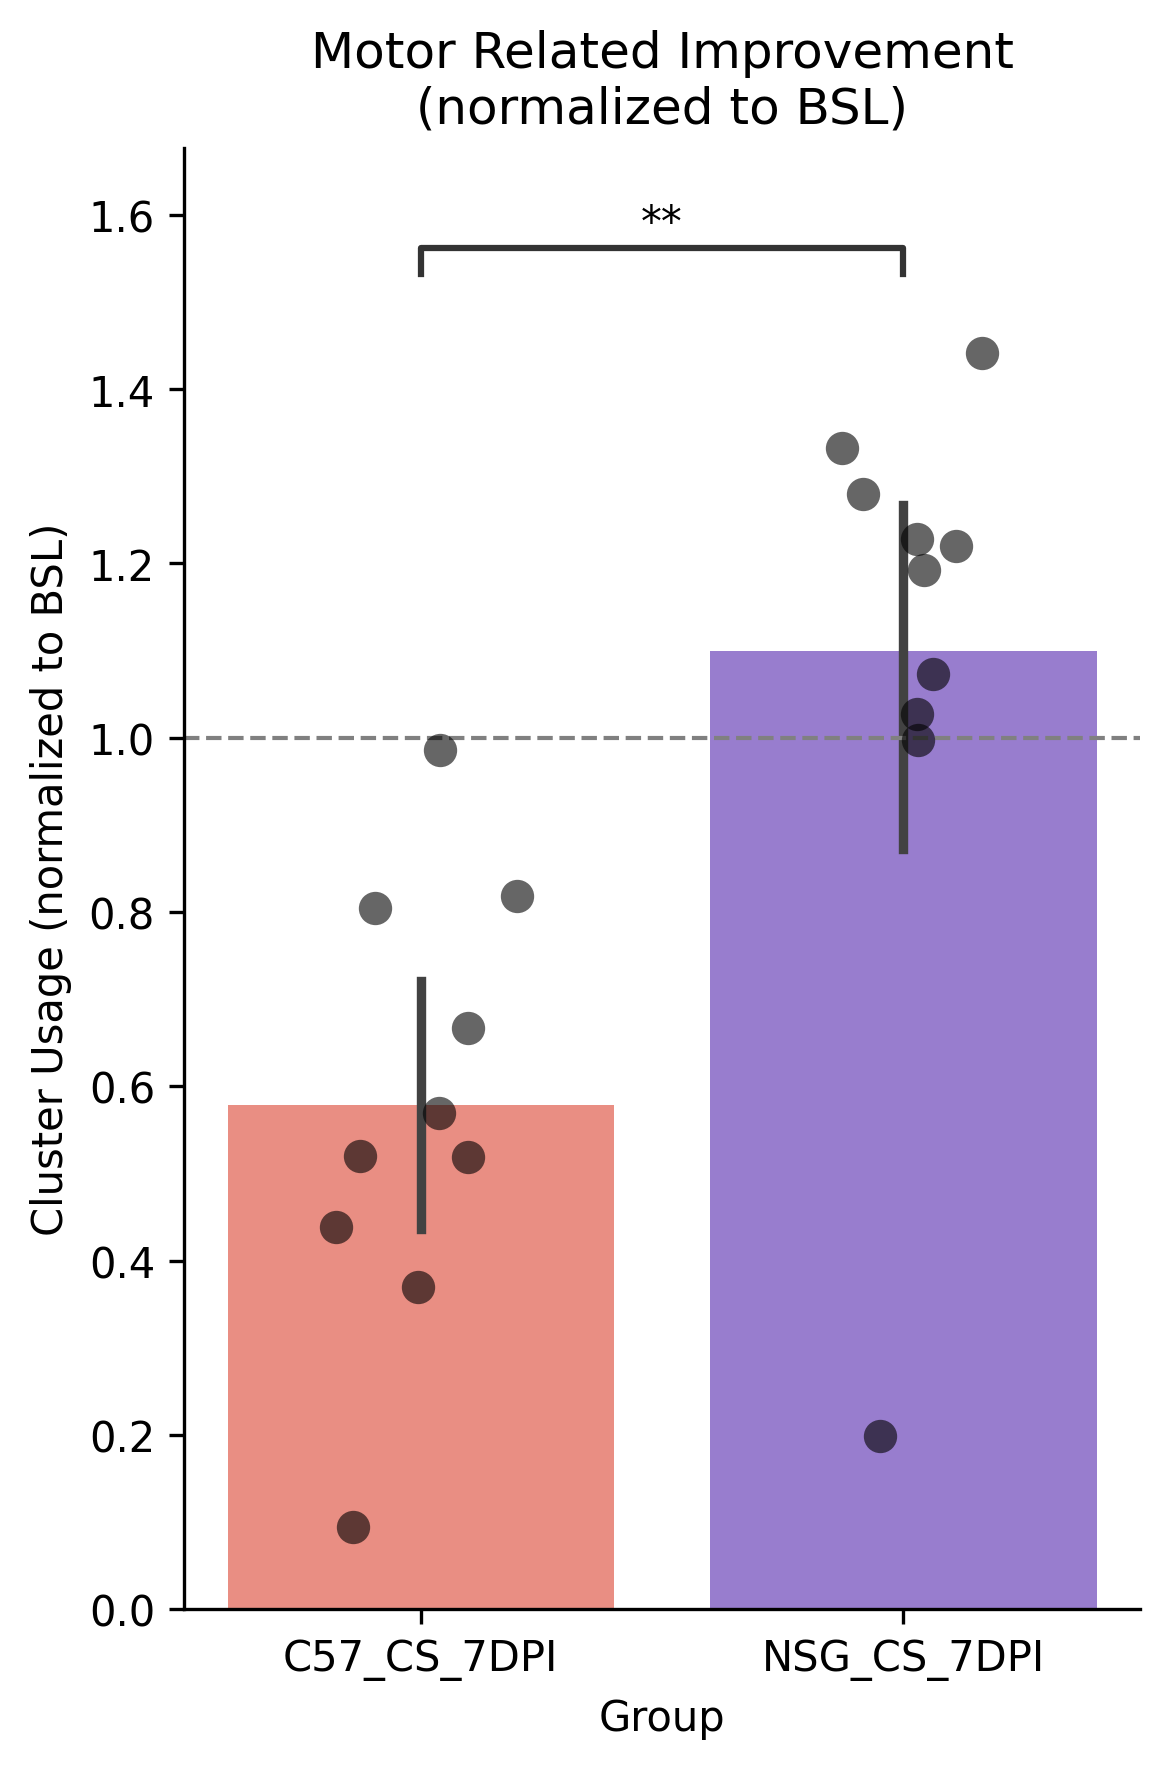

/tmp/ipykernel_2122/1256983838.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:3.571e-02 t=-2.270e+00


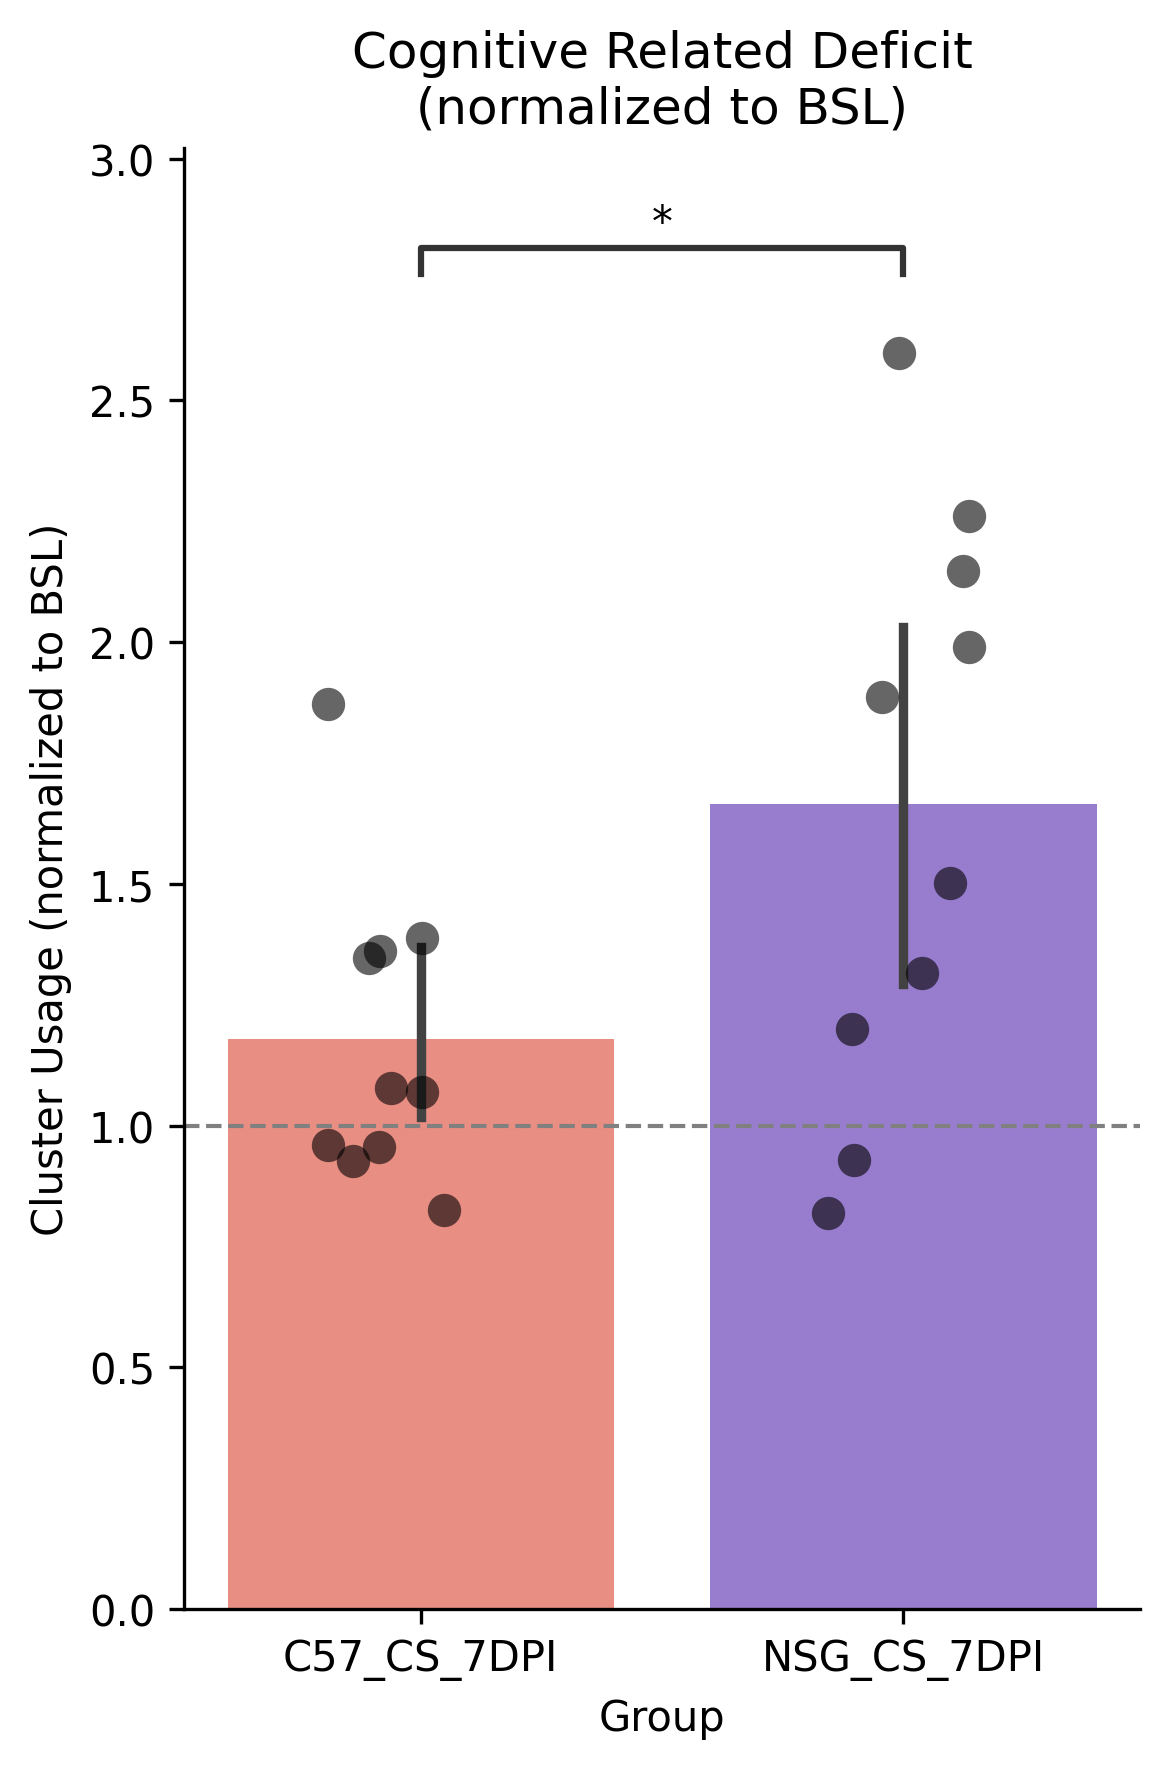

/tmp/ipykernel_2122/1256983838.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:4.948e-01 t=6.969e-01


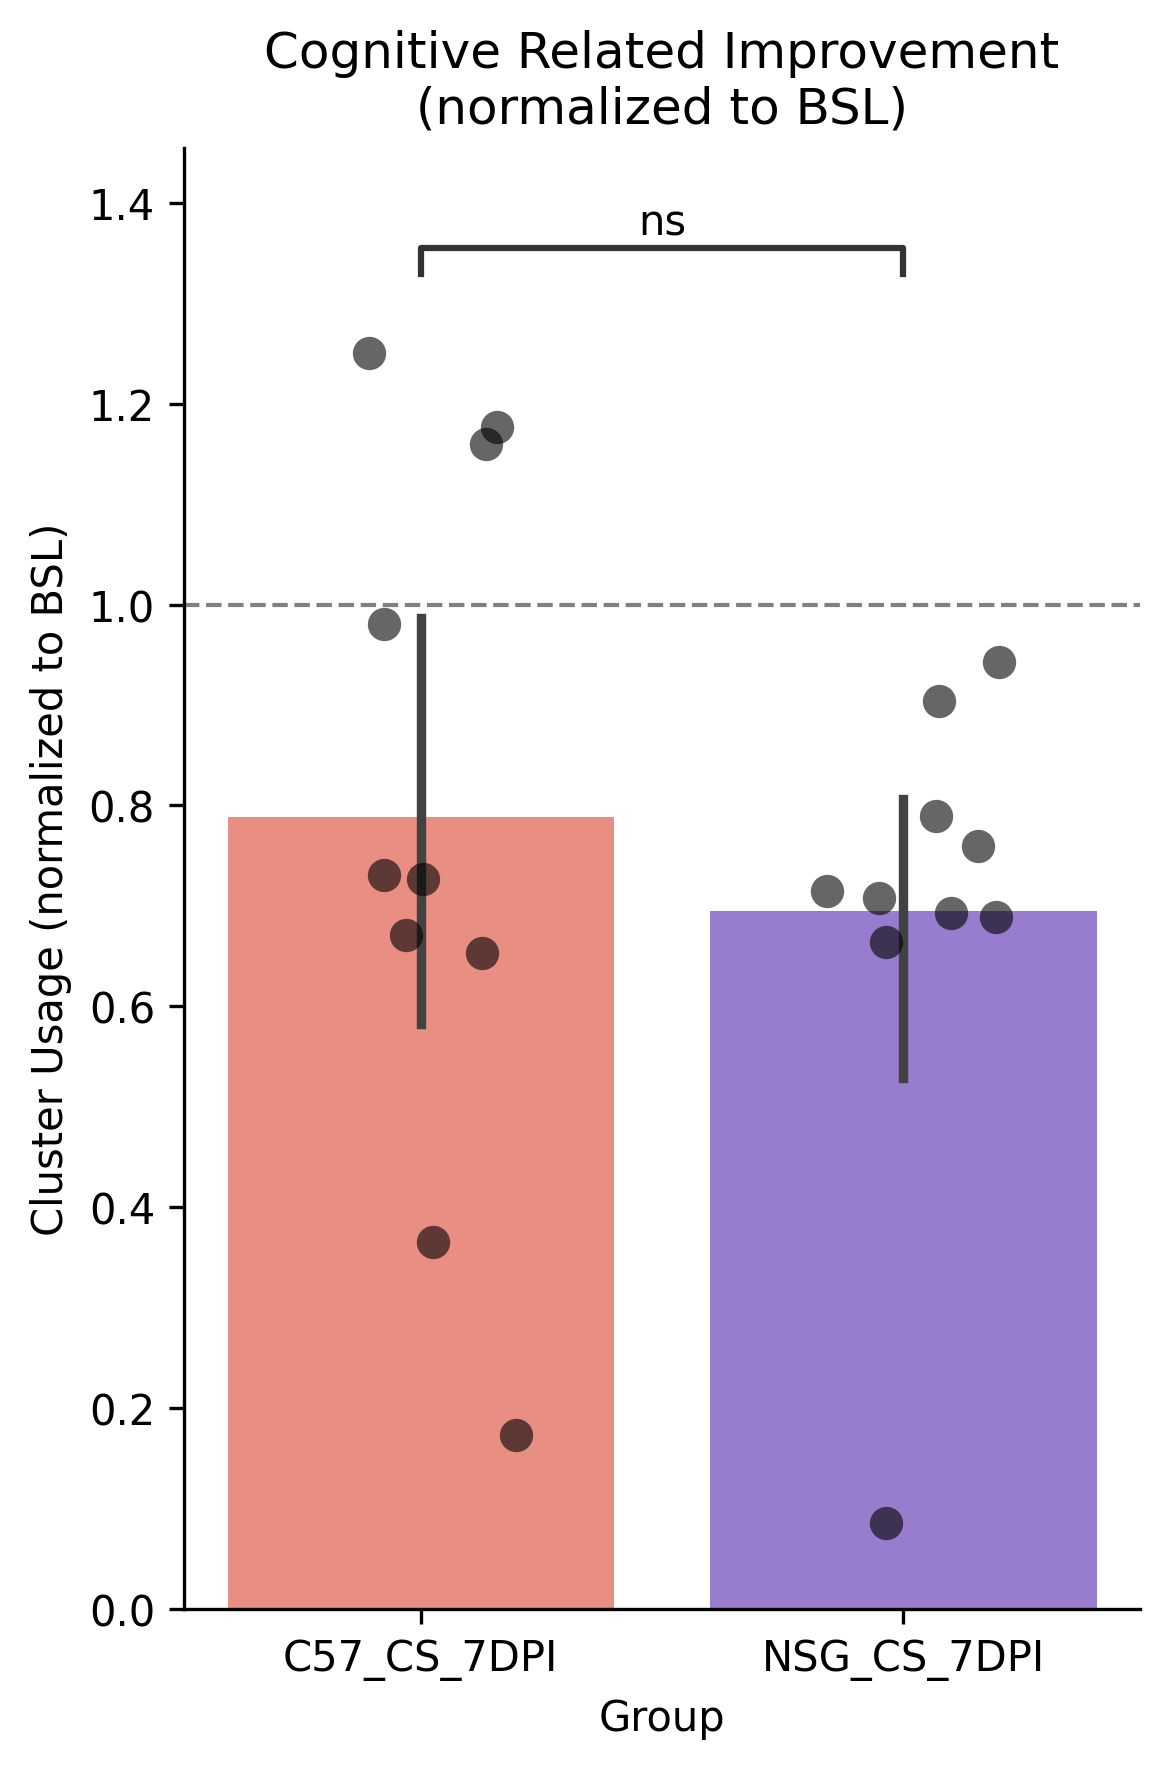

In [57]:
for cluster_name, title in cluster_map.items():
    data = animal_cluster_usage[animal_cluster_usage["cluster"] == cluster_name].copy()

    # compute per-animal normalization by BSL mean of same strain
    c57_bsl_mean = data[data["group"] == "C57_BSL"]["usage"].mean()
    nsg_bsl_mean = data[data["group"] == "NSG_BSL"]["usage"].mean()

    def normalize(row):
        if row["group"] in ["C57_BSL", "C57_CS_7DPI"]:
            return row["usage"] / c57_bsl_mean if c57_bsl_mean > 0 else np.nan
        elif row["group"] in ["NSG_BSL", "NSG_CS_7DPI"]:
            return row["usage"] / nsg_bsl_mean if nsg_bsl_mean > 0 else np.nan
        return np.nan

    data["usage_norm"] = data.apply(normalize, axis=1)

    # keep only 7DPI groups
    plot_data = data[data["group"].isin(["C57_CS_7DPI", "NSG_CS_7DPI"])]

    order_2 = ["C57_CS_7DPI", "NSG_CS_7DPI"]
    palette_2 = {
        "C57_CS_7DPI": "salmon",
        "NSG_CS_7DPI": "mediumpurple"
    }

    fig, ax = plt.subplots(figsize=(4, 6), dpi=300)

    sns.barplot(
        data=plot_data,
        x="group", y="usage_norm",
        order=order_2,
        palette=palette_2,
        zorder=1,
        ax=ax
    )
    sns.stripplot(
        data=plot_data,
        x="group", y="usage_norm",
        order=order_2,
        color="black", size=8, alpha=0.6, jitter=0.2,
        ax=ax
    )

    annotator = Annotator(
        ax, pairs=[("C57_CS_7DPI", "NSG_CS_7DPI")],
        data=plot_data, x="group", y="usage_norm", order=order_2
    )
    annotator.configure(test="t-test_ind", text_format="star", loc="inside", verbose=2)
    annotator.apply_and_annotate()

    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="BSL baseline")
    ax.set_title(f"{title}\n(normalized to BSL)")
    ax.set_xlabel("Group")
    ax.set_ylabel("Cluster Usage (normalized to BSL)")
    sns.despine(ax=ax)
    plt.tight_layout()
    #plt.savefig(SAVE_PATH / f'{title}_C57_vs_NSG_CS7dpi_BSLnorm_cluster_usage_barchart.pdf', bbox_inches='tight')
    plt.show()

## 4.4 BSL-Normalized Cluster Usage (7DPI Only)

Normalize each animal's cluster usage to its strain's mean baseline usage, then plot only the 7DPI groups. This removes strain-level baseline differences in syllable repertoire and isolates the post-stroke change relative to each strain's own baseline.

/tmp/ipykernel_2122/3196807661.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: t-test independent samples, P_val:1.575e-02 t=2.651e+00
NSG_BSL vs. NSG_CS_7DPI: t-test independent samples, P_val:3.265e-01 t=9.922e-01
C57_BSL vs. NSG_BSL: t-test independent samples, P_val:7.601e-07 t=-5.739e+00
C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:2.999e-03 t=-3.428e+00


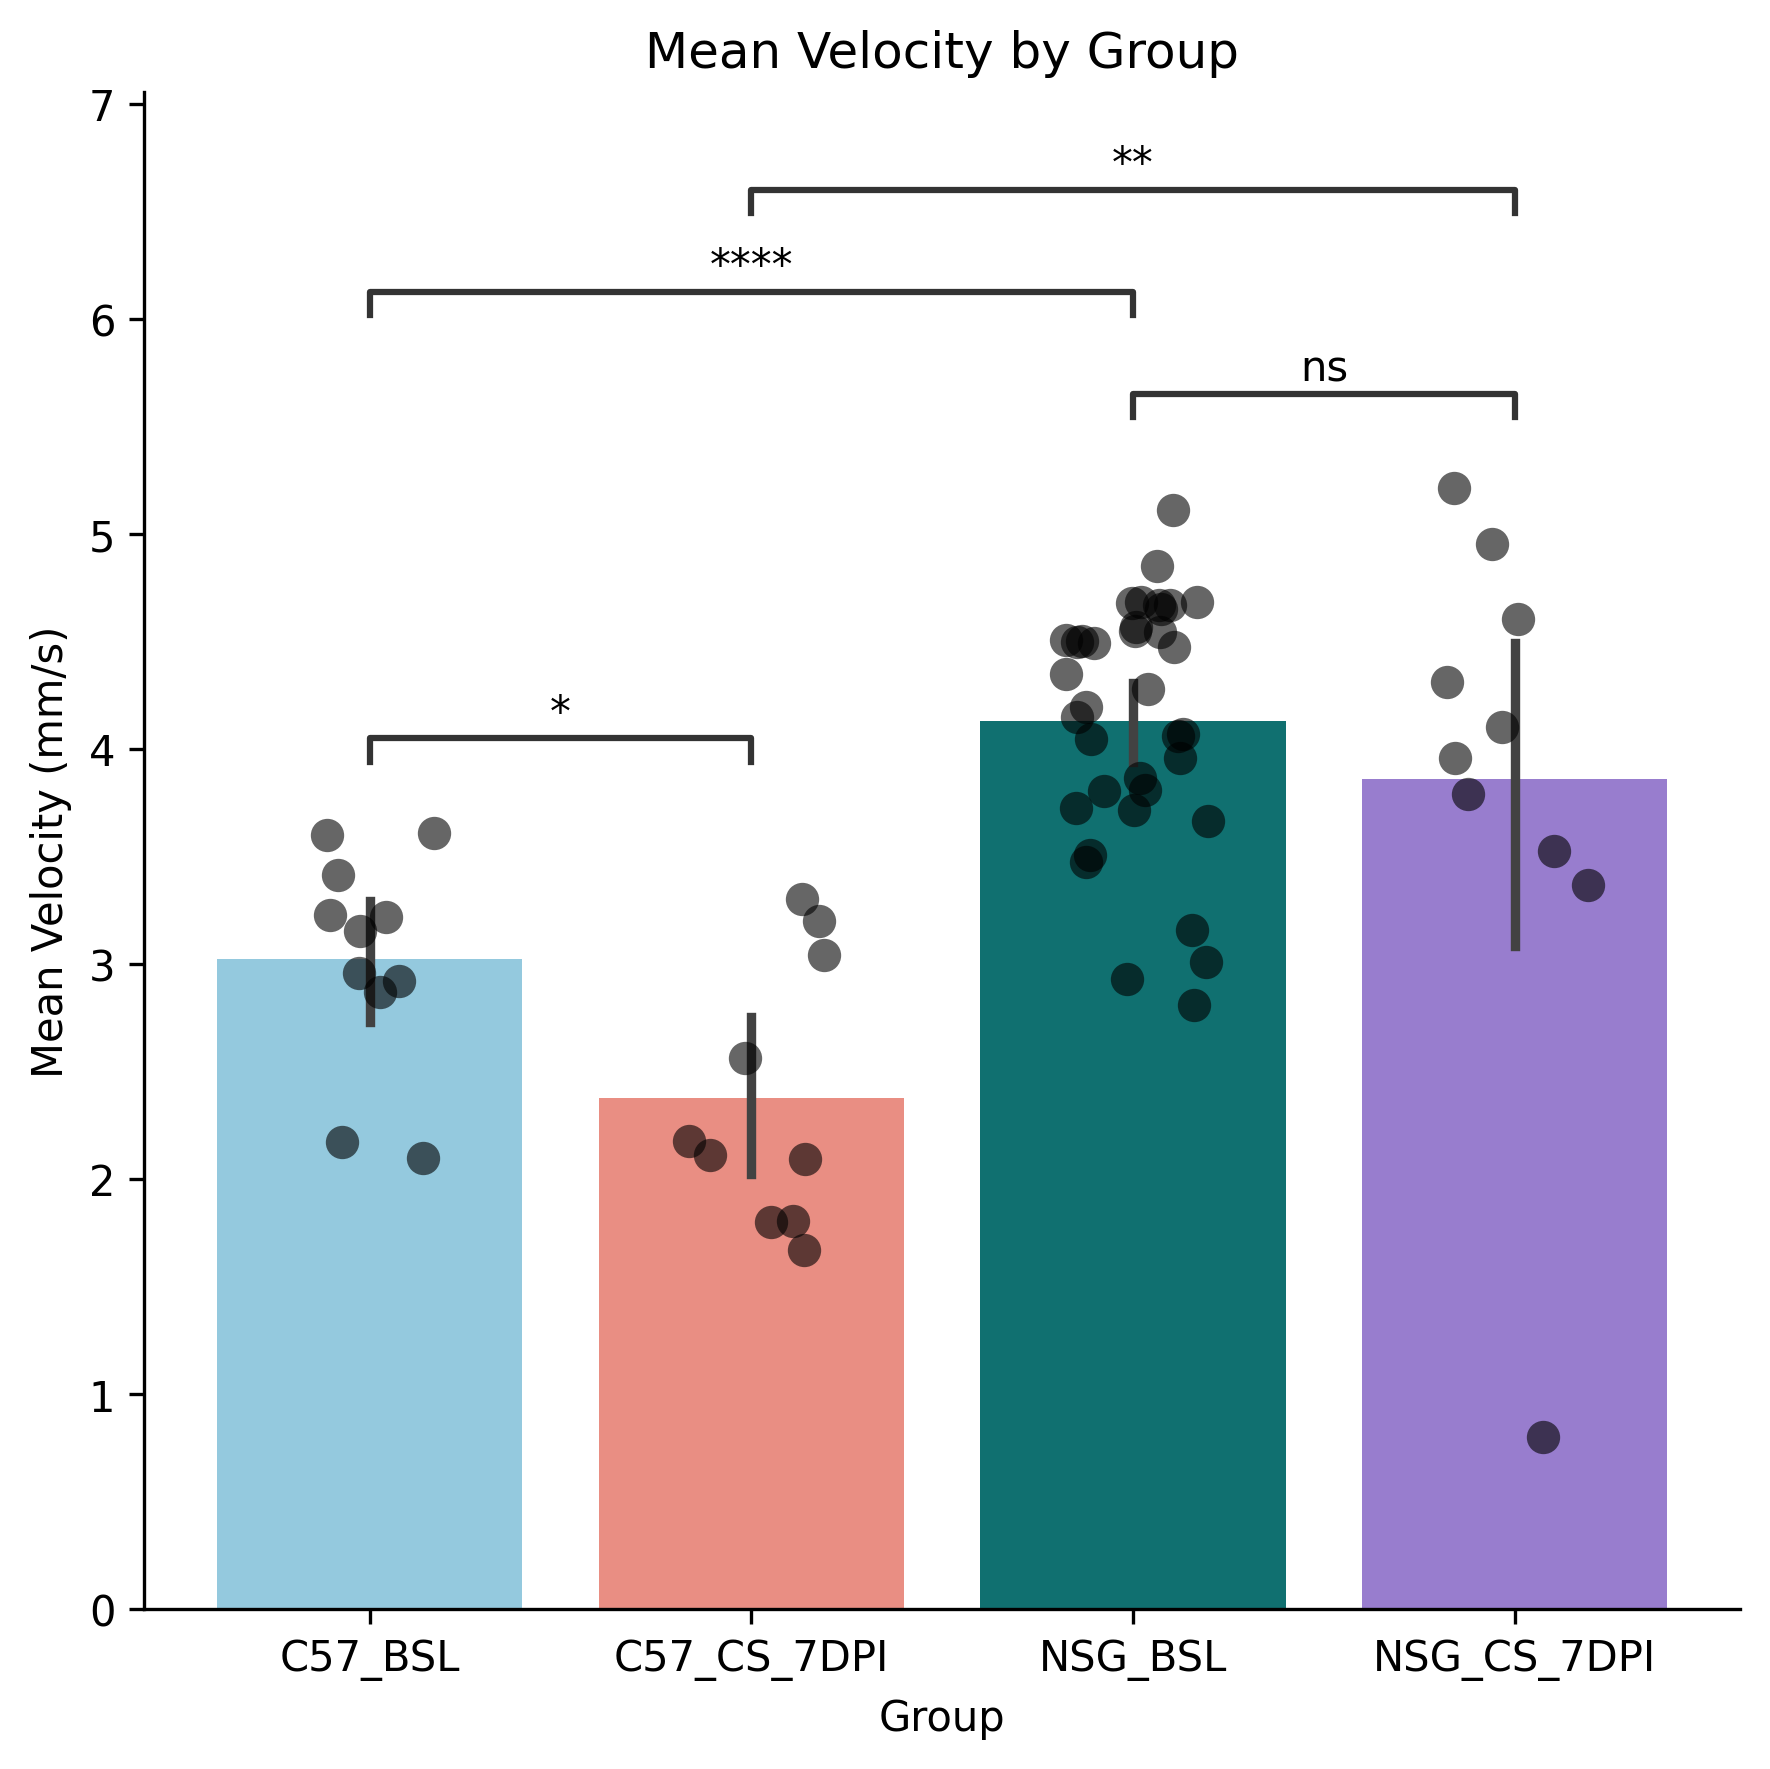

In [58]:
# --- Raw mean velocity ---
vel_data = moseq_df.groupby(["uuid", "group"])["velocity_2d_mm"].mean().reset_index()
vel_data.columns = ["animal_id", "group", "mean_velocity"]

order = ["C57_BSL", "C57_CS_7DPI", "NSG_BSL", "NSG_CS_7DPI"]
palette = {
    "C57_BSL": "skyblue",
    "C57_CS_7DPI": "salmon",
    "NSG_BSL": "Teal",
    "NSG_CS_7DPI": "mediumpurple"
}

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

sns.barplot(
    data=vel_data, x="group", y="mean_velocity",
    order=order, palette=palette, zorder=1, ax=ax
)
sns.stripplot(
    data=vel_data, x="group", y="mean_velocity",
    order=order, color="black", size=8, alpha=0.6, jitter=0.2, ax=ax
)

pairs = [
    ("C57_BSL", "C57_CS_7DPI"),
    ("NSG_BSL", "NSG_CS_7DPI"),
    ("C57_BSL", "NSG_BSL"),
    ("C57_CS_7DPI", "NSG_CS_7DPI"),
]
annotator = Annotator(ax, pairs=pairs, data=vel_data, x="group", y="mean_velocity", order=order)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", verbose=2)
annotator.apply_and_annotate()

ax.set_title("Mean Velocity by Group")
ax.set_xlabel("Group")
ax.set_ylabel("Mean Velocity (mm/s)")
ax.set_ylim(bottom=0)
sns.despine(ax=ax)
plt.tight_layout()
#plt.savefig(SAVE_PATH / "Mean_Velocity_4groups.pdf", bbox_inches="tight")
plt.show()

## 4.5 Mean Locomotor Velocity

Compute each animal's mean 2D velocity across all frames as a single summary of locomotor output. Plotted raw across all four groups, then normalized to strain baseline (7DPI only) to isolate stroke-induced changes.

/tmp/ipykernel_2122/1705705578.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:2.069e-01 t=-1.309e+00


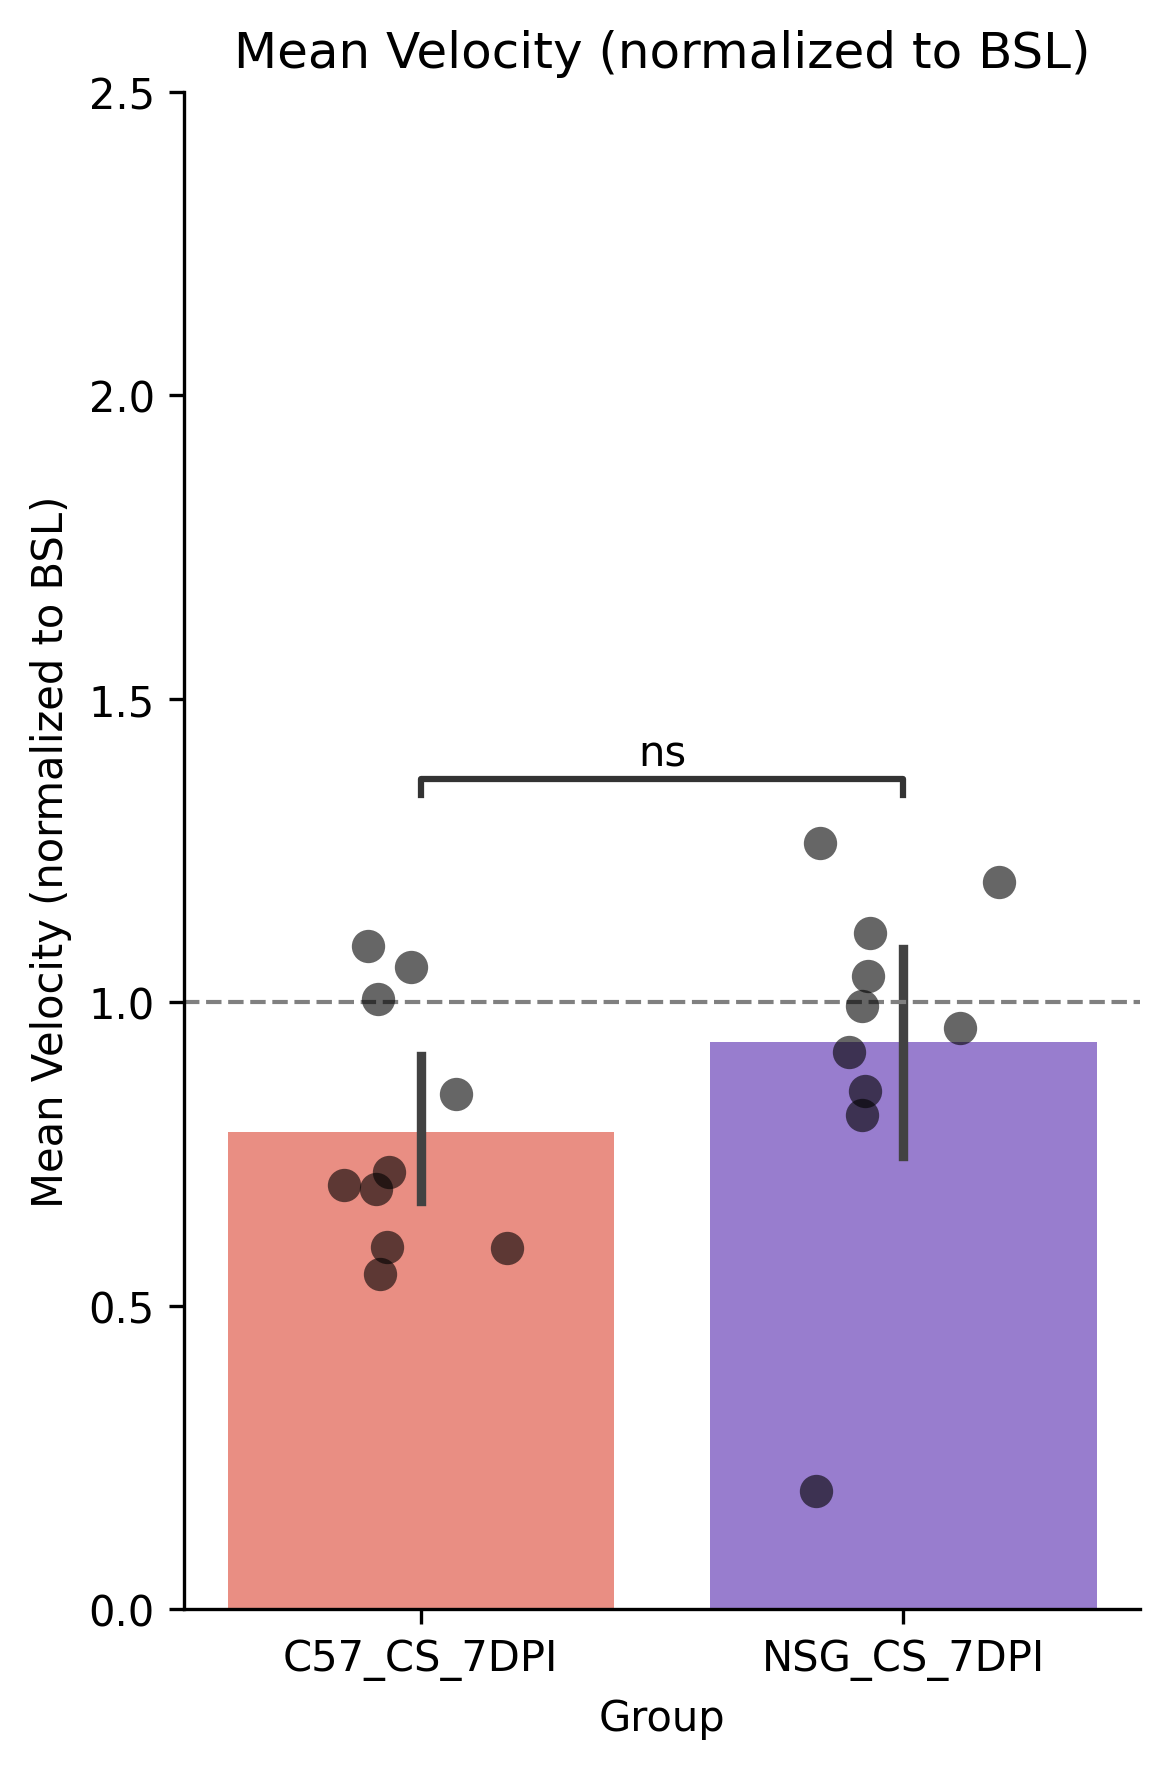

In [59]:

# --- Normalized mean velocity (7DPI only, normalized to strain BSL mean) ---
vel_data = vel_data.copy()

c57_bsl_mean = vel_data[vel_data["group"] == "C57_BSL"]["mean_velocity"].mean()
nsg_bsl_mean = vel_data[vel_data["group"] == "NSG_BSL"]["mean_velocity"].mean()

def normalize_vel(row):
    if row["group"] in ["C57_BSL", "C57_CS_7DPI"]:
        return row["mean_velocity"] / c57_bsl_mean if c57_bsl_mean > 0 else np.nan
    elif row["group"] in ["NSG_BSL", "NSG_CS_7DPI"]:
        return row["mean_velocity"] / nsg_bsl_mean if nsg_bsl_mean > 0 else np.nan
    return np.nan

vel_data["velocity_norm"] = vel_data.apply(normalize_vel, axis=1)
plot_vel_norm = vel_data[vel_data["group"].isin(["C57_CS_7DPI", "NSG_CS_7DPI"])]

order_2 = ["C57_CS_7DPI", "NSG_CS_7DPI"]
palette_2 = {"C57_CS_7DPI": "salmon", "NSG_CS_7DPI": "mediumpurple"}

fig, ax = plt.subplots(figsize=(4, 6), dpi=300)

sns.barplot(
    data=plot_vel_norm, x="group", y="velocity_norm",
    order=order_2, palette=palette_2, zorder=1, ax=ax
)
sns.stripplot(
    data=plot_vel_norm, x="group", y="velocity_norm",
    order=order_2, color="black", size=8, alpha=0.6, jitter=0.2, ax=ax
)

annotator = Annotator(
    ax, pairs=[("C57_CS_7DPI", "NSG_CS_7DPI")],
    data=plot_vel_norm, x="group", y="velocity_norm", order=order_2
)
annotator.configure(test="t-test_ind", text_format="star", loc="inside", verbose=2)
annotator.apply_and_annotate()

ax.set_ylim(0, 2.5)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="BSL baseline")
ax.set_title("Mean Velocity (normalized to BSL)")
ax.set_xlabel("Group")
ax.set_ylabel("Mean Velocity (normalized to BSL)")
sns.despine(ax=ax)
plt.tight_layout()
#plt.savefig(SAVE_PATH / "Mean_Velocity_BSLnorm_C57_vs_NSG_CS7dpi.pdf", bbox_inches="tight")
plt.show()

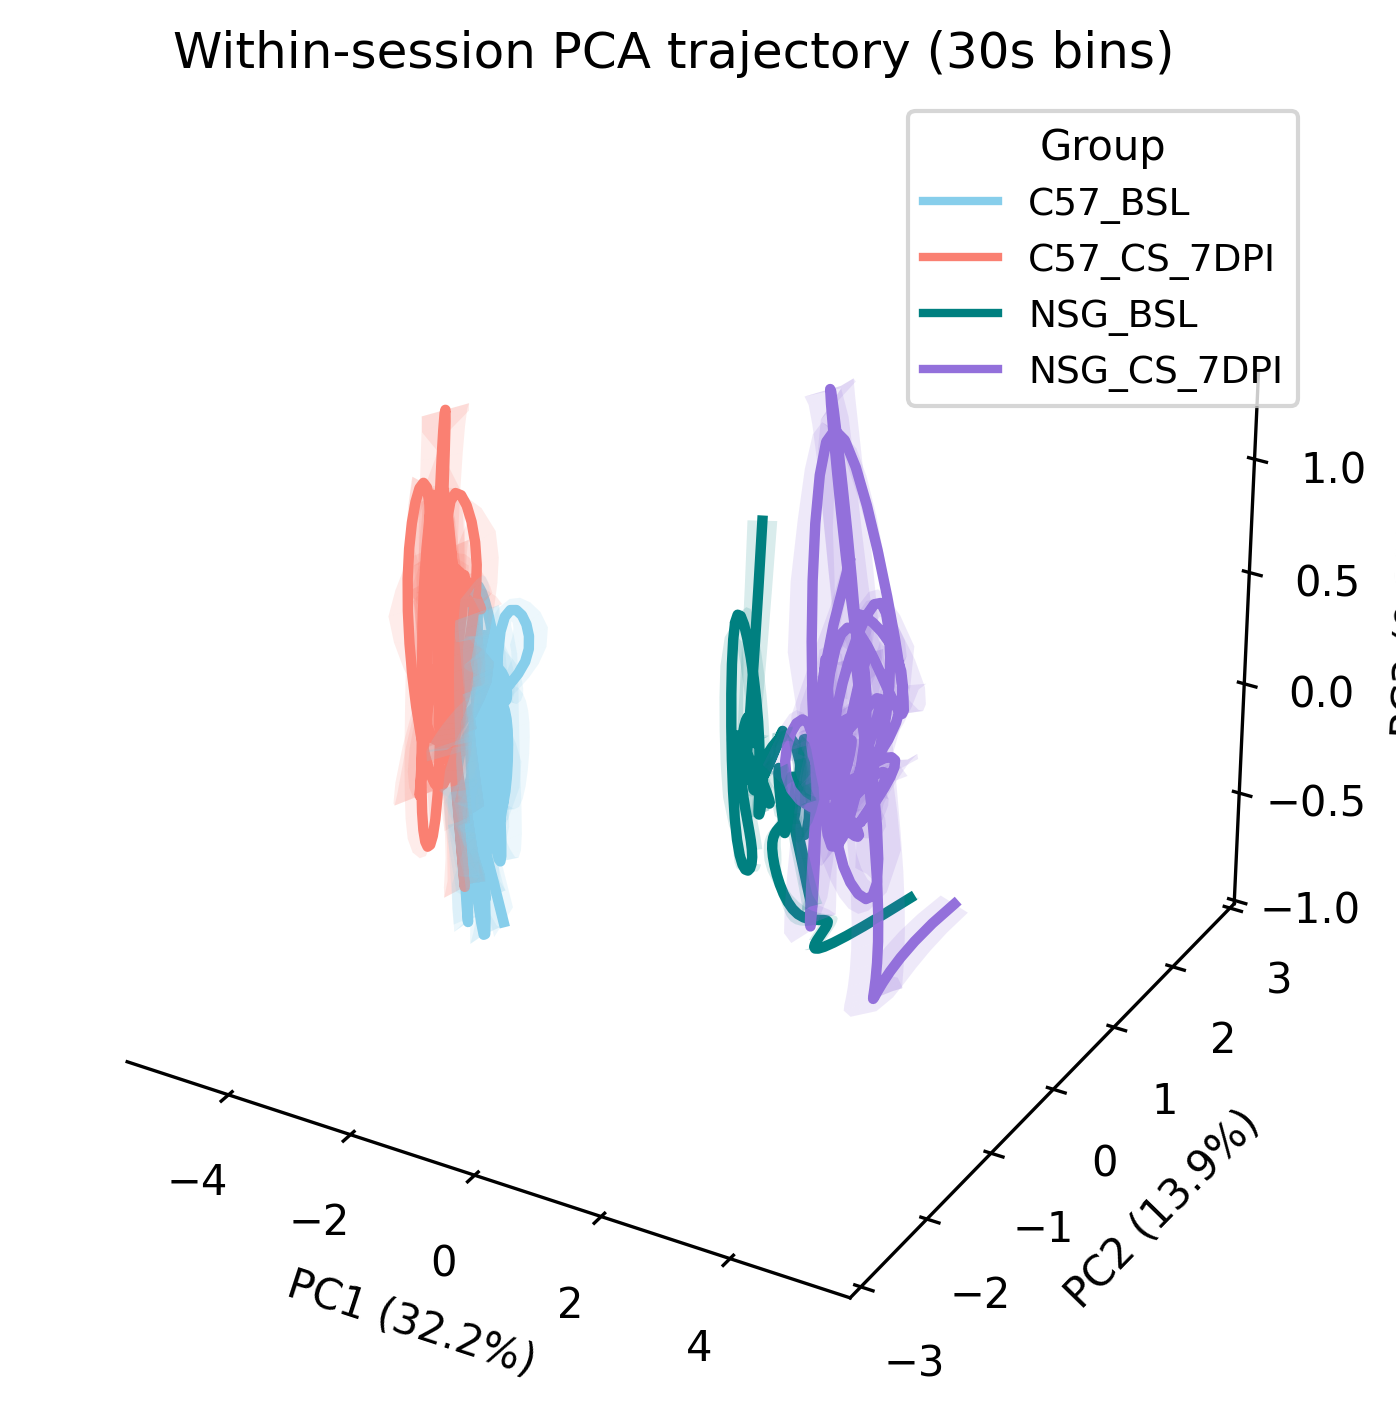

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.interpolate import make_interp_spline, interp1d
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# --- settings ---
FPS = 30
BIN_SECONDS = 30
FRAMES_PER_BIN = FPS * BIN_SECONDS

feature_cols = [c for c in moseq_df.columns
                if moseq_df[c].dtype in [np.float64, np.float32, np.int64]
                and c != "frame index"]

moseq_clean = moseq_df.copy()
moseq_clean["frame index"] = (
    moseq_clean["frame index"]
    .interpolate(method="linear")
    .ffill()
    .bfill()
)
moseq_clean["time_bin"] = (moseq_clean["frame index"] // FRAMES_PER_BIN).astype(int)

animal_bin_means = (
    moseq_clean.groupby(["uuid", "group", "time_bin"])[feature_cols]
    .mean()
    .reset_index()
)

X = animal_bin_means[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
coords = pca.fit_transform(X_scaled)
animal_bin_means["PC1"] = coords[:, 0]
animal_bin_means["PC2"] = coords[:, 1]
animal_bin_means["PC3"] = coords[:, 2]

def sem(x):
    return x.std() / np.sqrt(len(x))

traj = (
    animal_bin_means.groupby(["group", "time_bin"])[["PC1", "PC2", "PC3"]]
    .agg(["mean", sem])
    .reset_index()
)
traj.columns = ["group", "time_bin",
                "PC1_mean", "PC1_sem",
                "PC2_mean", "PC2_sem",
                "PC3_mean", "PC3_sem"]

fig = plt.figure(dpi=300)
ax = fig.add_subplot(111, projection="3d")

for group in order:
    g = traj[traj["group"] == group].sort_values("time_bin")
    color = palette[group]
    x = g["PC1_mean"].values
    y = g["PC2_mean"].values
    z = g["PC3_mean"].values
    xe = g["PC1_sem"].values
    ye = g["PC2_sem"].values
    ze = g["PC3_sem"].values
    n_bins = len(x)

    if n_bins > 3:
        t = np.arange(n_bins)
        t_smooth = np.linspace(0, n_bins - 1, 300)
        x_smooth = make_interp_spline(t, x, k=3)(t_smooth)
        y_smooth = make_interp_spline(t, y, k=3)(t_smooth)
        z_smooth = make_interp_spline(t, z, k=3)(t_smooth)
        xe_smooth = make_interp_spline(t, xe, k=3)(t_smooth)
        ye_smooth = make_interp_spline(t, ye, k=3)(t_smooth)
        ze_smooth = make_interp_spline(t, ze, k=3)(t_smooth)
    else:
        t_smooth = np.linspace(0, n_bins - 1, 300)
        x_smooth = interp1d(np.arange(n_bins), x)(t_smooth)
        y_smooth = interp1d(np.arange(n_bins), y)(t_smooth)
        z_smooth = interp1d(np.arange(n_bins), z)(t_smooth)
        xe_smooth = interp1d(np.arange(n_bins), xe)(t_smooth)
        ye_smooth = interp1d(np.arange(n_bins), ye)(t_smooth)
        ze_smooth = interp1d(np.arange(n_bins), ze)(t_smooth)

    # main trajectory
    ax.plot(x_smooth, y_smooth, z_smooth, color=color, linewidth=2.5)

    # SEM ribbon (perpendicular in 3D using cross product)
    dx = np.gradient(x_smooth)
    dy = np.gradient(y_smooth)
    dz = np.gradient(z_smooth)

    # tangent vector
    tangent = np.stack([dx, dy, dz], axis=1)
    tangent /= (np.linalg.norm(tangent, axis=1, keepdims=True) + 1e-10)

    # use a fixed up vector and cross to get perpendicular
    up = np.array([0, 0, 1.0])
    perp = np.cross(tangent, up)
    perp_norm = np.linalg.norm(perp, axis=1, keepdims=True) + 1e-10
    perp /= perp_norm

    band = (xe_smooth + ye_smooth + ze_smooth) / 3 * 0.5

    upper = np.stack([x_smooth, y_smooth, z_smooth], axis=1) + perp * band[:, None]
    lower = np.stack([x_smooth, y_smooth, z_smooth], axis=1) - perp * band[:, None]

    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    verts = [[upper[i], upper[i+1], lower[i+1], lower[i]] for i in range(len(x_smooth)-1)]
    ribbon = Poly3DCollection(verts, alpha=0.15)
    ribbon.set_facecolor(color)
    ribbon.set_edgecolor("none")
    ax.add_collection3d(ribbon)

var_exp = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)", fontsize=10)
ax.set_zlabel(f"PC3 ({var_exp[2]*100:.1f}%)", fontsize=10)
ax.set_title(f"Within-session PCA trajectory ({BIN_SECONDS}s bins)", fontsize=12)

ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("none")
ax.yaxis.pane.set_edgecolor("none")
ax.zaxis.pane.set_edgecolor("none")

handles = [Line2D([0], [0], color=palette[g], lw=2, label=g) for g in order]
ax.legend(handles=handles, title="Group", fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.savefig(SAVE_PATH / "PCA_within_session_trajectory_3D.pdf", bbox_inches="tight")
plt.show()

## 4.6 Within-Session PCA Trajectories

Bin each session into 30-second windows and compute the mean of all numeric kinematic features per animal per bin. Apply PCA across all animals and bins to project behavioral state into a low-dimensional space. The resulting trajectory shows how behavioral state evolves across the session for each group, with SEM ribbons indicating inter-animal variability.

Trajectories are plotted in both 3D (PC1–PC3) and 2D (PC1–PC2).

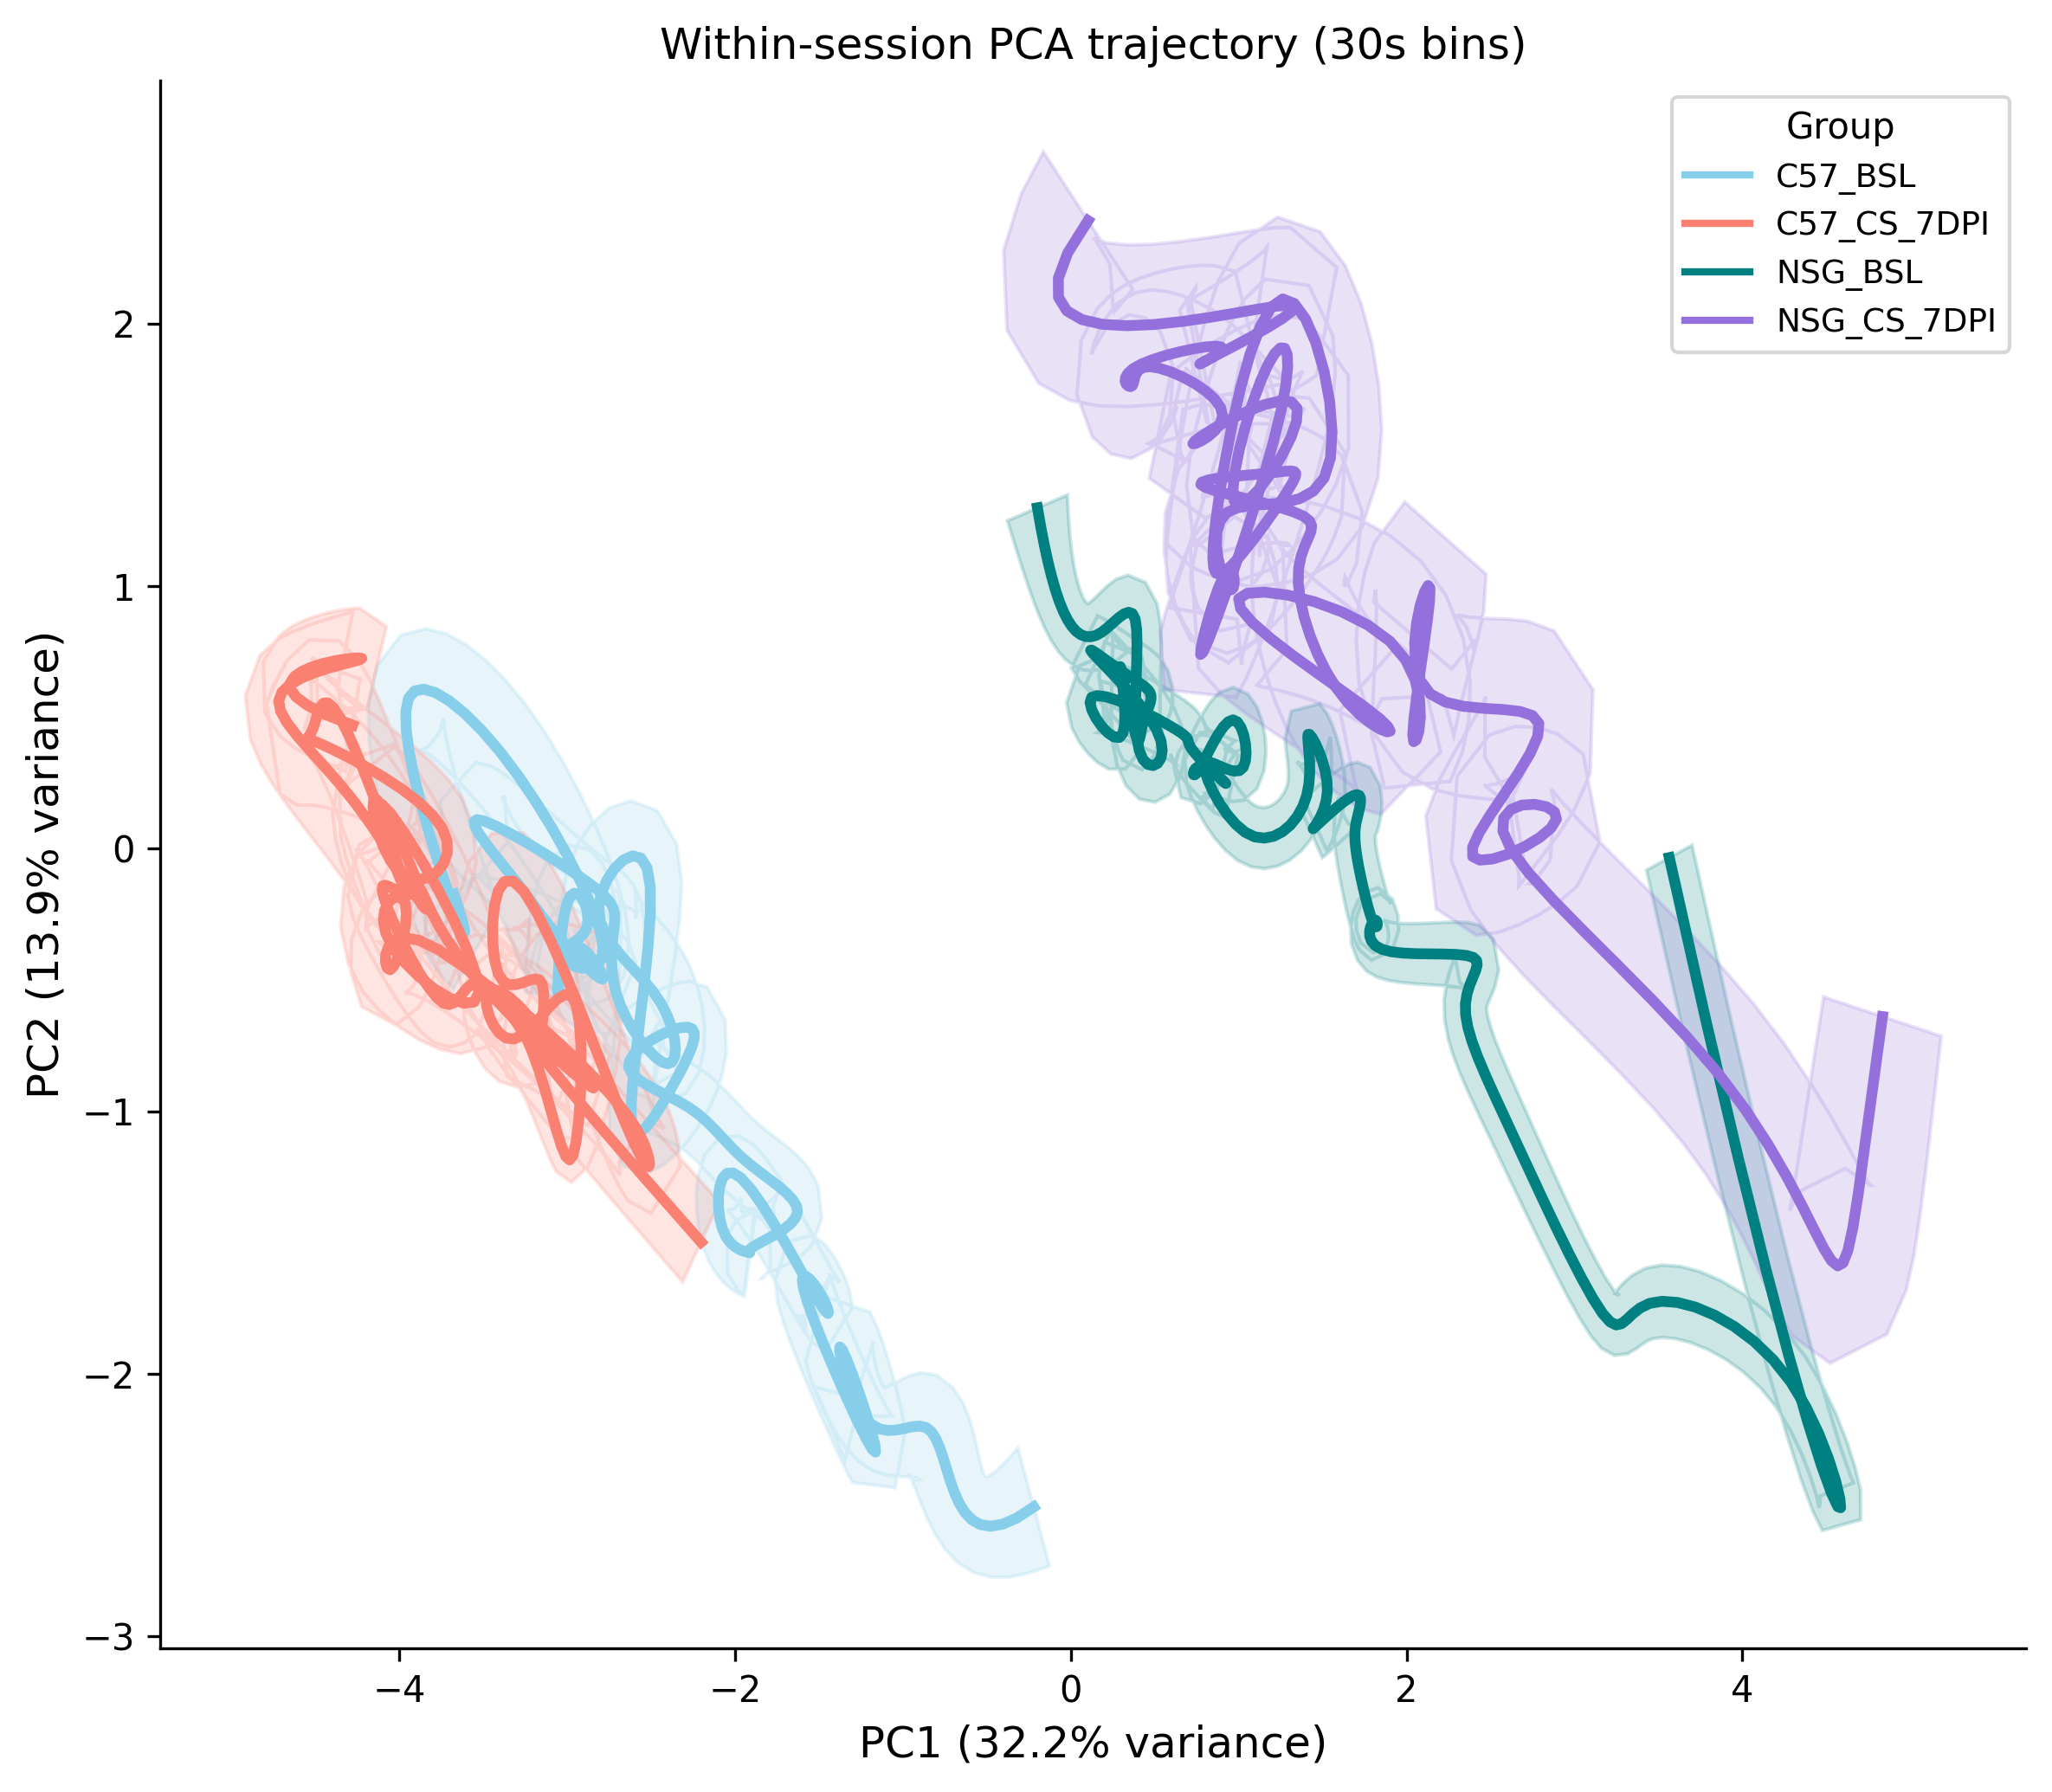

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.interpolate import make_interp_spline, interp1d
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

# --- settings ---
FPS = 30
BIN_SECONDS = 30
FRAMES_PER_BIN = FPS * BIN_SECONDS

feature_cols = [c for c in moseq_df.columns
                if moseq_df[c].dtype in [np.float64, np.float32, np.int64]
                and c != "frame index"]

moseq_clean = moseq_df.copy()
moseq_clean["frame index"] = (
    moseq_clean["frame index"]
    .interpolate(method="linear")
    .ffill()
    .bfill()
)
moseq_clean["time_bin"] = (moseq_clean["frame index"] // FRAMES_PER_BIN).astype(int)

animal_bin_means = (
    moseq_clean.groupby(["uuid", "group", "time_bin"])[feature_cols]
    .mean()
    .reset_index()
)

X = animal_bin_means[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
animal_bin_means["PC1"] = coords[:, 0]
animal_bin_means["PC2"] = coords[:, 1]

def sem(x):
    return x.std() / np.sqrt(len(x))

traj = (
    animal_bin_means.groupby(["group", "time_bin"])[["PC1", "PC2"]]
    .agg(["mean", sem])
    .reset_index()
)
traj.columns = ["group", "time_bin", "PC1_mean", "PC1_sem", "PC2_mean", "PC2_sem"]

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

for group in order:
    g = traj[traj["group"] == group].sort_values("time_bin")
    color = palette[group]
    x = g["PC1_mean"].values
    y = g["PC2_mean"].values
    xe = g["PC1_sem"].values
    ye = g["PC2_sem"].values
    n_bins = len(x)

    if n_bins > 3:
        t = np.arange(n_bins)
        t_smooth = np.linspace(0, n_bins - 1, 300)
        x_smooth = make_interp_spline(t, x, k=3)(t_smooth)
        y_smooth = make_interp_spline(t, y, k=3)(t_smooth)
        xe_smooth = make_interp_spline(t, xe, k=3)(t_smooth)
        ye_smooth = make_interp_spline(t, ye, k=3)(t_smooth)
    else:
        t_smooth = np.linspace(0, n_bins - 1, 300)
        x_smooth = interp1d(np.arange(n_bins), x)(t_smooth)
        y_smooth = interp1d(np.arange(n_bins), y)(t_smooth)
        xe_smooth = interp1d(np.arange(n_bins), xe)(t_smooth)
        ye_smooth = interp1d(np.arange(n_bins), ye)(t_smooth)

    dx = np.gradient(x_smooth)
    dy = np.gradient(y_smooth)
    norm = np.sqrt(dx**2 + dy**2) + 1e-10
    px = -dy / norm
    py =  dx / norm

    band = (xe_smooth + ye_smooth) / 2 * 0.5

    upper_x = x_smooth + px * band
    upper_y = y_smooth + py * band
    lower_x = x_smooth - px * band
    lower_y = y_smooth - py * band

    poly_x = np.concatenate([upper_x, lower_x[::-1]])
    poly_y = np.concatenate([upper_y, lower_y[::-1]])
    ax.fill(poly_x, poly_y, color=color, alpha=0.2, zorder=1)

    ax.plot(x_smooth, y_smooth, color=color, linewidth=3, zorder=2)

var_exp = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% variance)", fontsize=12)
ax.set_title(f"Within-session PCA trajectory ({BIN_SECONDS}s bins)", fontsize=12)

handles = [Line2D([0], [0], color=palette[g], lw=2, label=g) for g in order]
ax.legend(handles=handles, title="Group", fontsize=9, title_fontsize=10)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(SAVE_PATH / "PCA_within_session_trajectory_2D.pdf", bbox_inches="tight")
plt.show()

## 4.7 Combined Motor and Cognitive Cluster Usage

Collapse the four clusters into two broader categories by summing the deficit and improvement sub-clusters:
- **Motor Related**: `high_disp_high_vel` + `high_disp_low_vel`
- **Cognitive Related**: `low_disp_high_vel` + `low_disp_low_vel`

This provides a higher-level view of whether stroke shifts the overall balance of motor vs. cognitive behavioral engagement, and whether NSG and Bl6 mice differ in this balance.

/tmp/ipykernel_2122/254664648.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="group", y="usage", order=order, palette=palette, zorder=1, ax=ax)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: t-test independent samples, P_val:7.908e-01 t=2.691e-01
NSG_BSL vs. NSG_CS_7DPI: t-test independent samples, P_val:1.702e-02 t=-2.480e+00
C57_BSL vs. NSG_BSL: t-test independent samples, P_val:4.401e-09 t=-7.246e+00
C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:2.515e-05 t=-5.613e+00


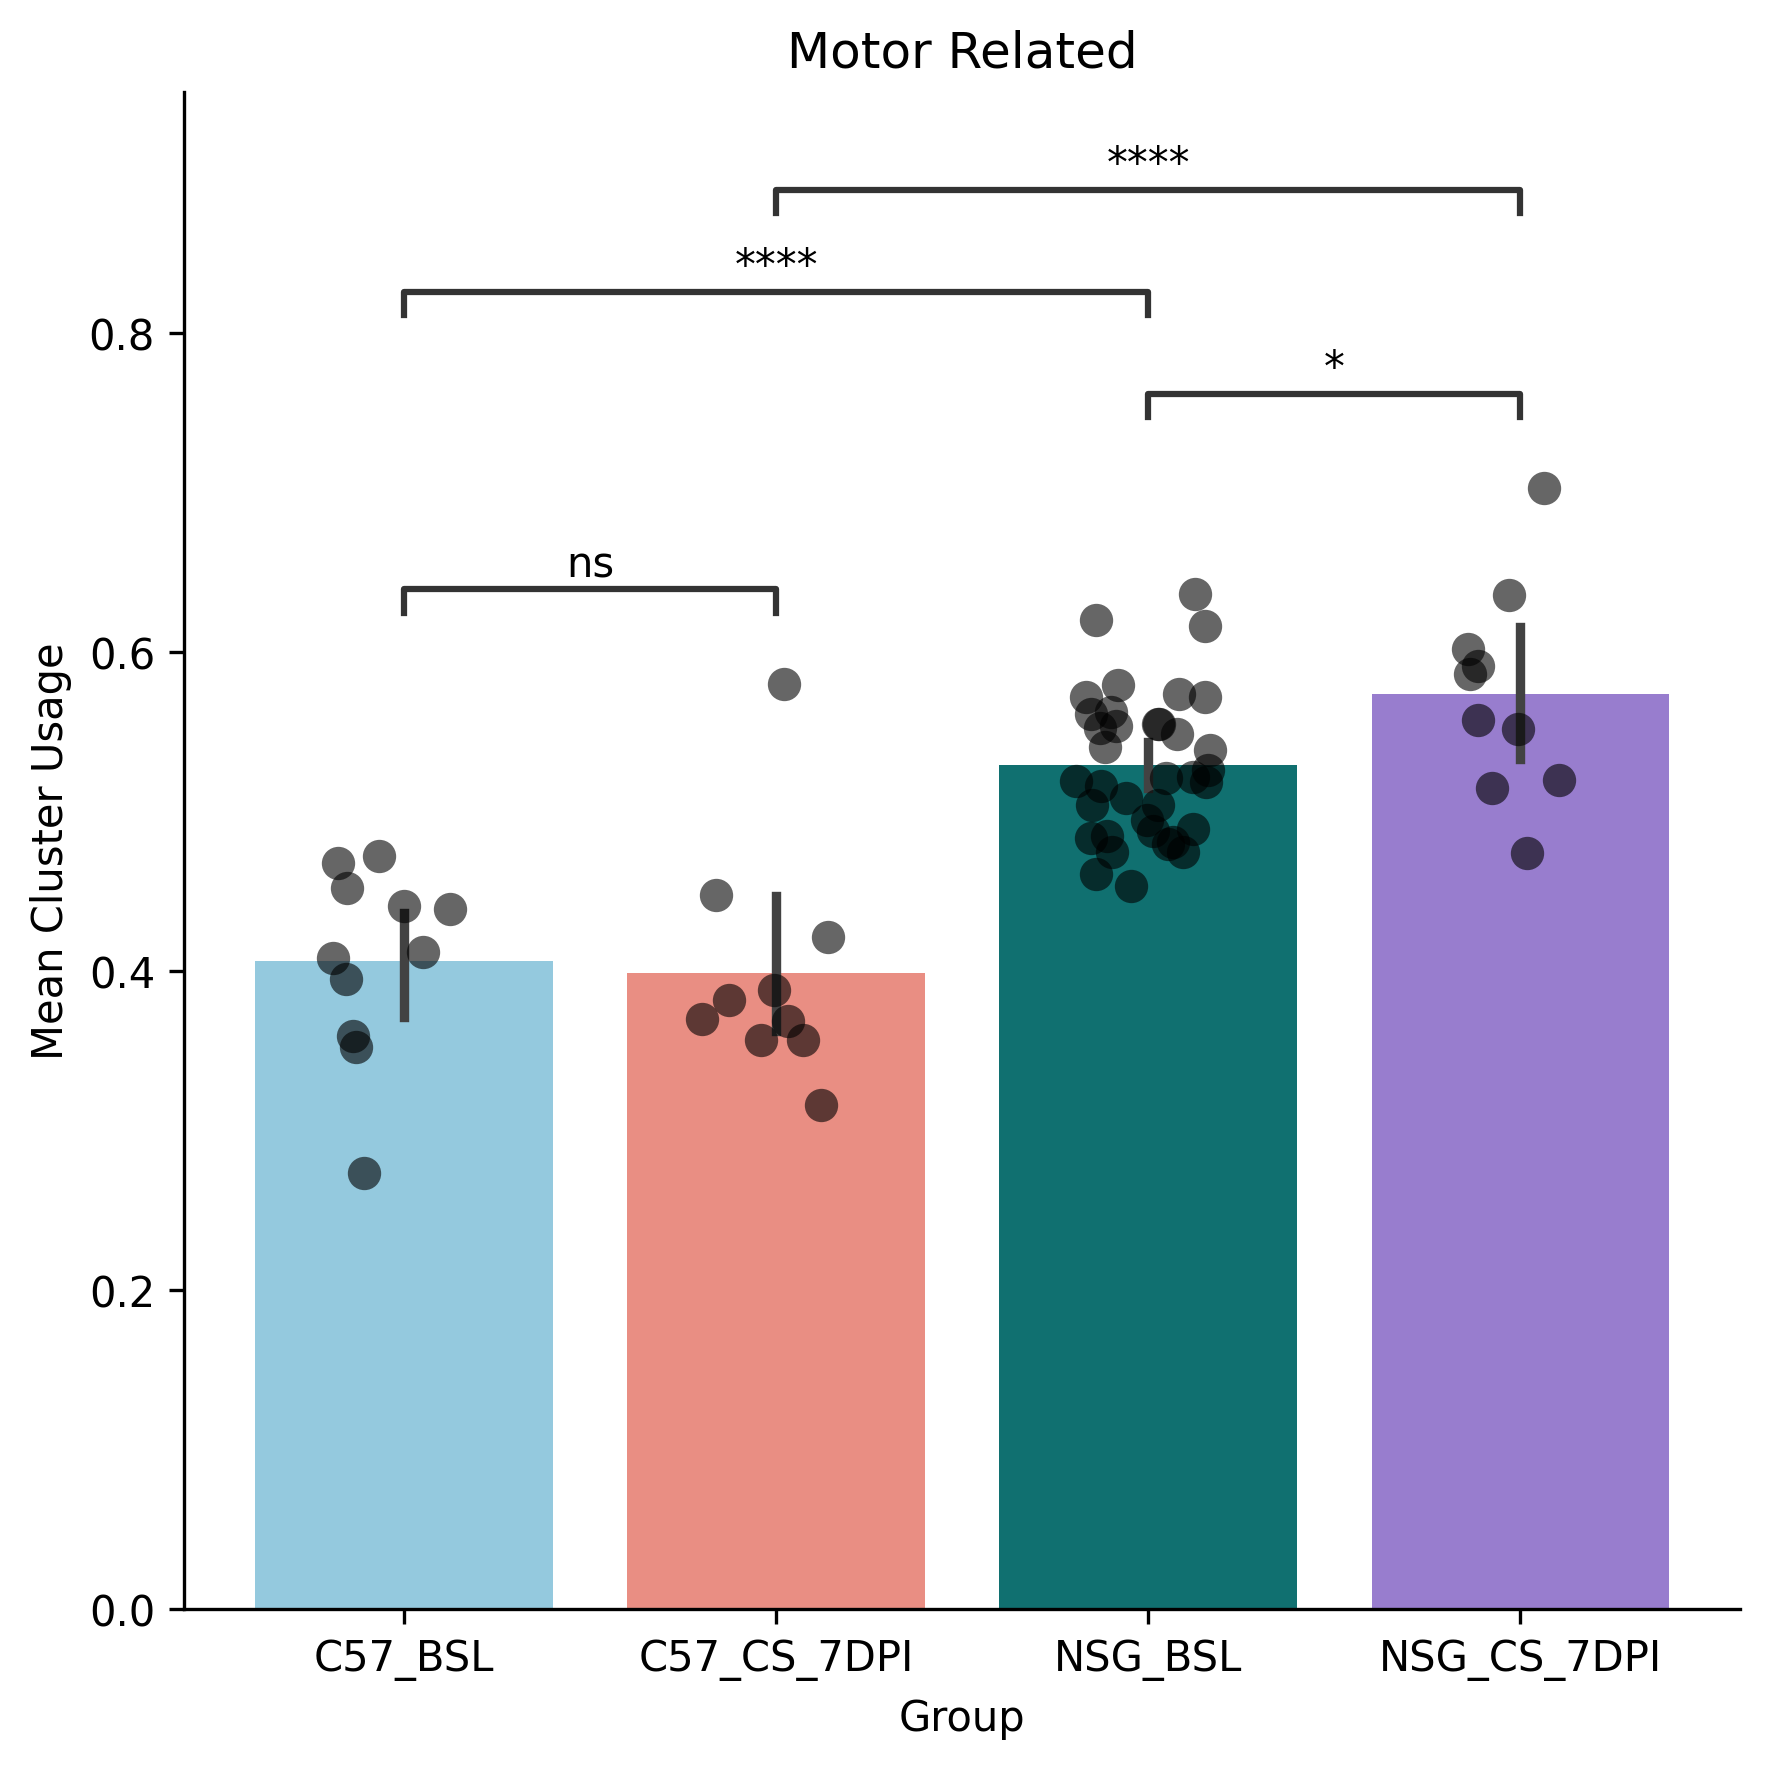

/tmp/ipykernel_2122/254664648.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="group", y="usage", order=order, palette=palette, zorder=1, ax=ax)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

C57_BSL vs. C57_CS_7DPI: t-test independent samples, P_val:7.908e-01 t=-2.691e-01
NSG_BSL vs. NSG_CS_7DPI: t-test independent samples, P_val:1.702e-02 t=2.480e+00
C57_BSL vs. NSG_BSL: t-test independent samples, P_val:4.401e-09 t=7.246e+00
C57_CS_7DPI vs. NSG_CS_7DPI: t-test independent samples, P_val:2.515e-05 t=5.613e+00


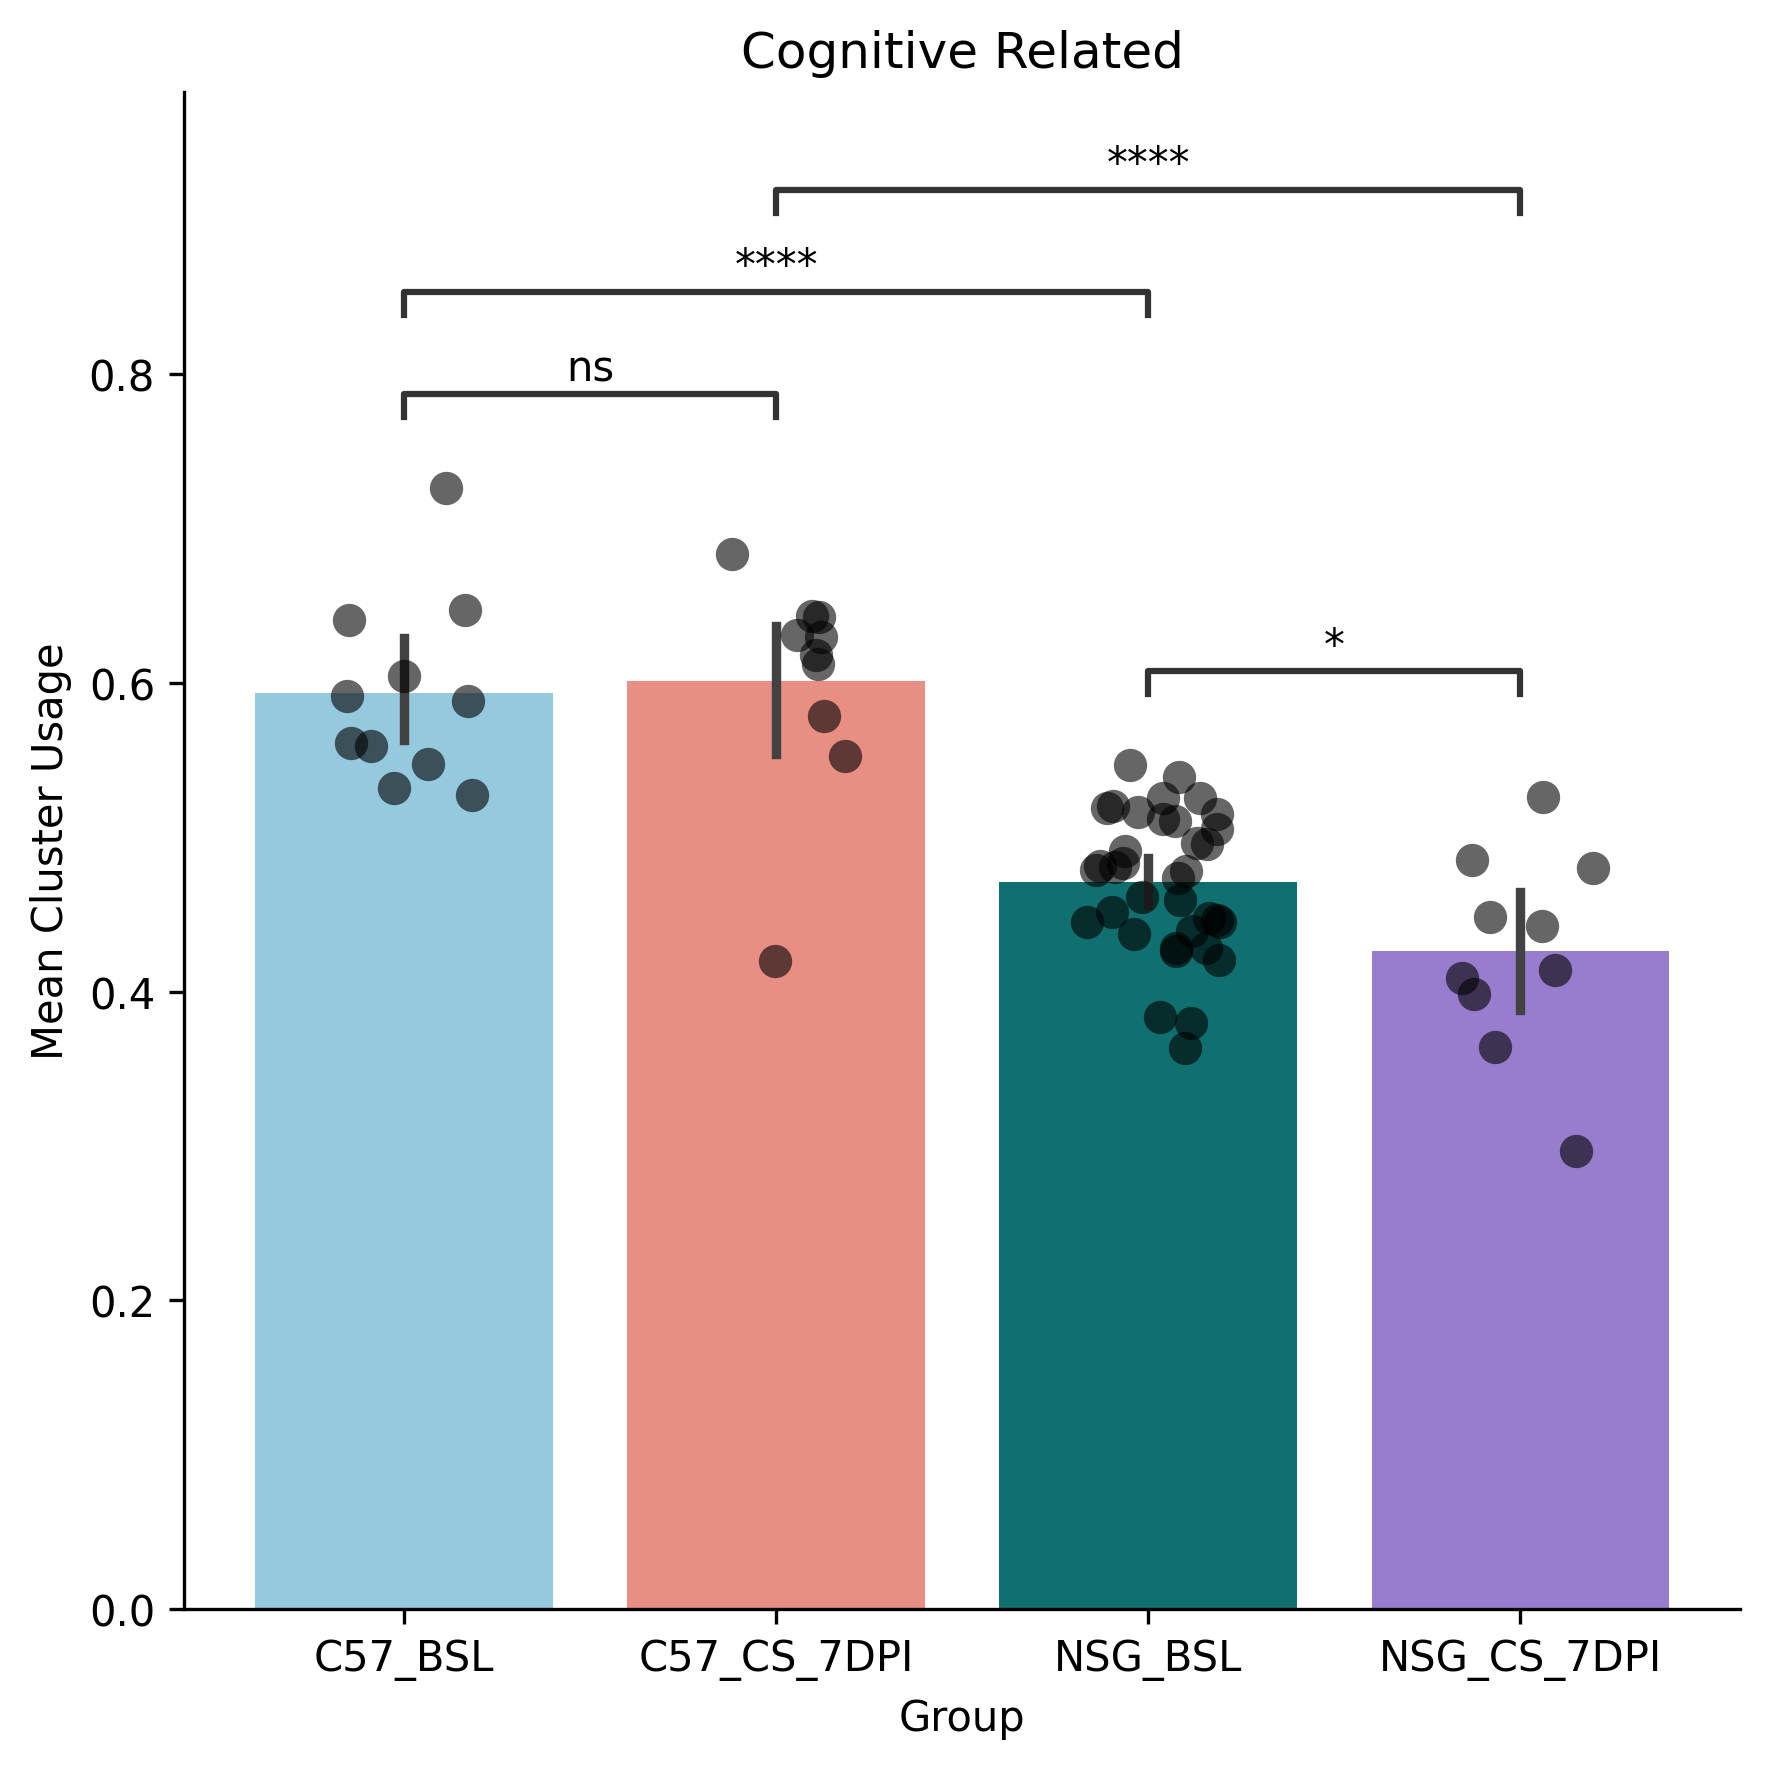

In [61]:
# Combine motor and cognitive regardless of deficit/improvement
motor_cognitive_map = {
    "Motor Related": ["high_disp_low_vel", "high_disp_high_vel"],
    "Cognitive Related": ["low_disp_low_vel", "low_disp_high_vel"],
}

for title, clusters in motor_cognitive_map.items():
    data = animal_cluster_usage[animal_cluster_usage["cluster"].isin(clusters)]

    # sum usage across the two sub-clusters per animal
    data = (
        data
        .groupby(["uuid", "group"])["usage"]
        .sum()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

    order = ["C57_BSL", "C57_CS_7DPI", "NSG_BSL", "NSG_CS_7DPI"]
    palette = {
        "C57_BSL": "skyblue",
        "C57_CS_7DPI": "salmon",
        "NSG_BSL": "Teal",
        "NSG_CS_7DPI": "mediumpurple"
    }

    sns.barplot(data=data, x="group", y="usage", order=order, palette=palette, zorder=1, ax=ax)
    sns.stripplot(data=data, x="group", y="usage", order=order, color="black", size=8, alpha=0.6, jitter=0.2, ax=ax)

    pairs = [
        ("C57_BSL", "C57_CS_7DPI"),
        ("NSG_BSL", "NSG_CS_7DPI"),
        ("C57_BSL", "NSG_BSL"),
        ("C57_CS_7DPI", "NSG_CS_7DPI"),
    ]

    annotator = Annotator(ax, pairs=pairs, data=data, x="group", y="usage", order=order)
    annotator.configure(test="t-test_ind", text_format="star", loc="inside", verbose=2)
    annotator.apply_and_annotate()

    ax.set_title(title)
    ax.set_xlabel("Group")
    ax.set_ylabel("Mean Cluster Usage")
    ax.set_ylim(bottom=0)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(SAVE_PATH / f'{title}_C57_vs_NSG_BSL_CS7dpi_cluster_usage_barchart.pdf', bbox_inches='tight')
    plt.show()

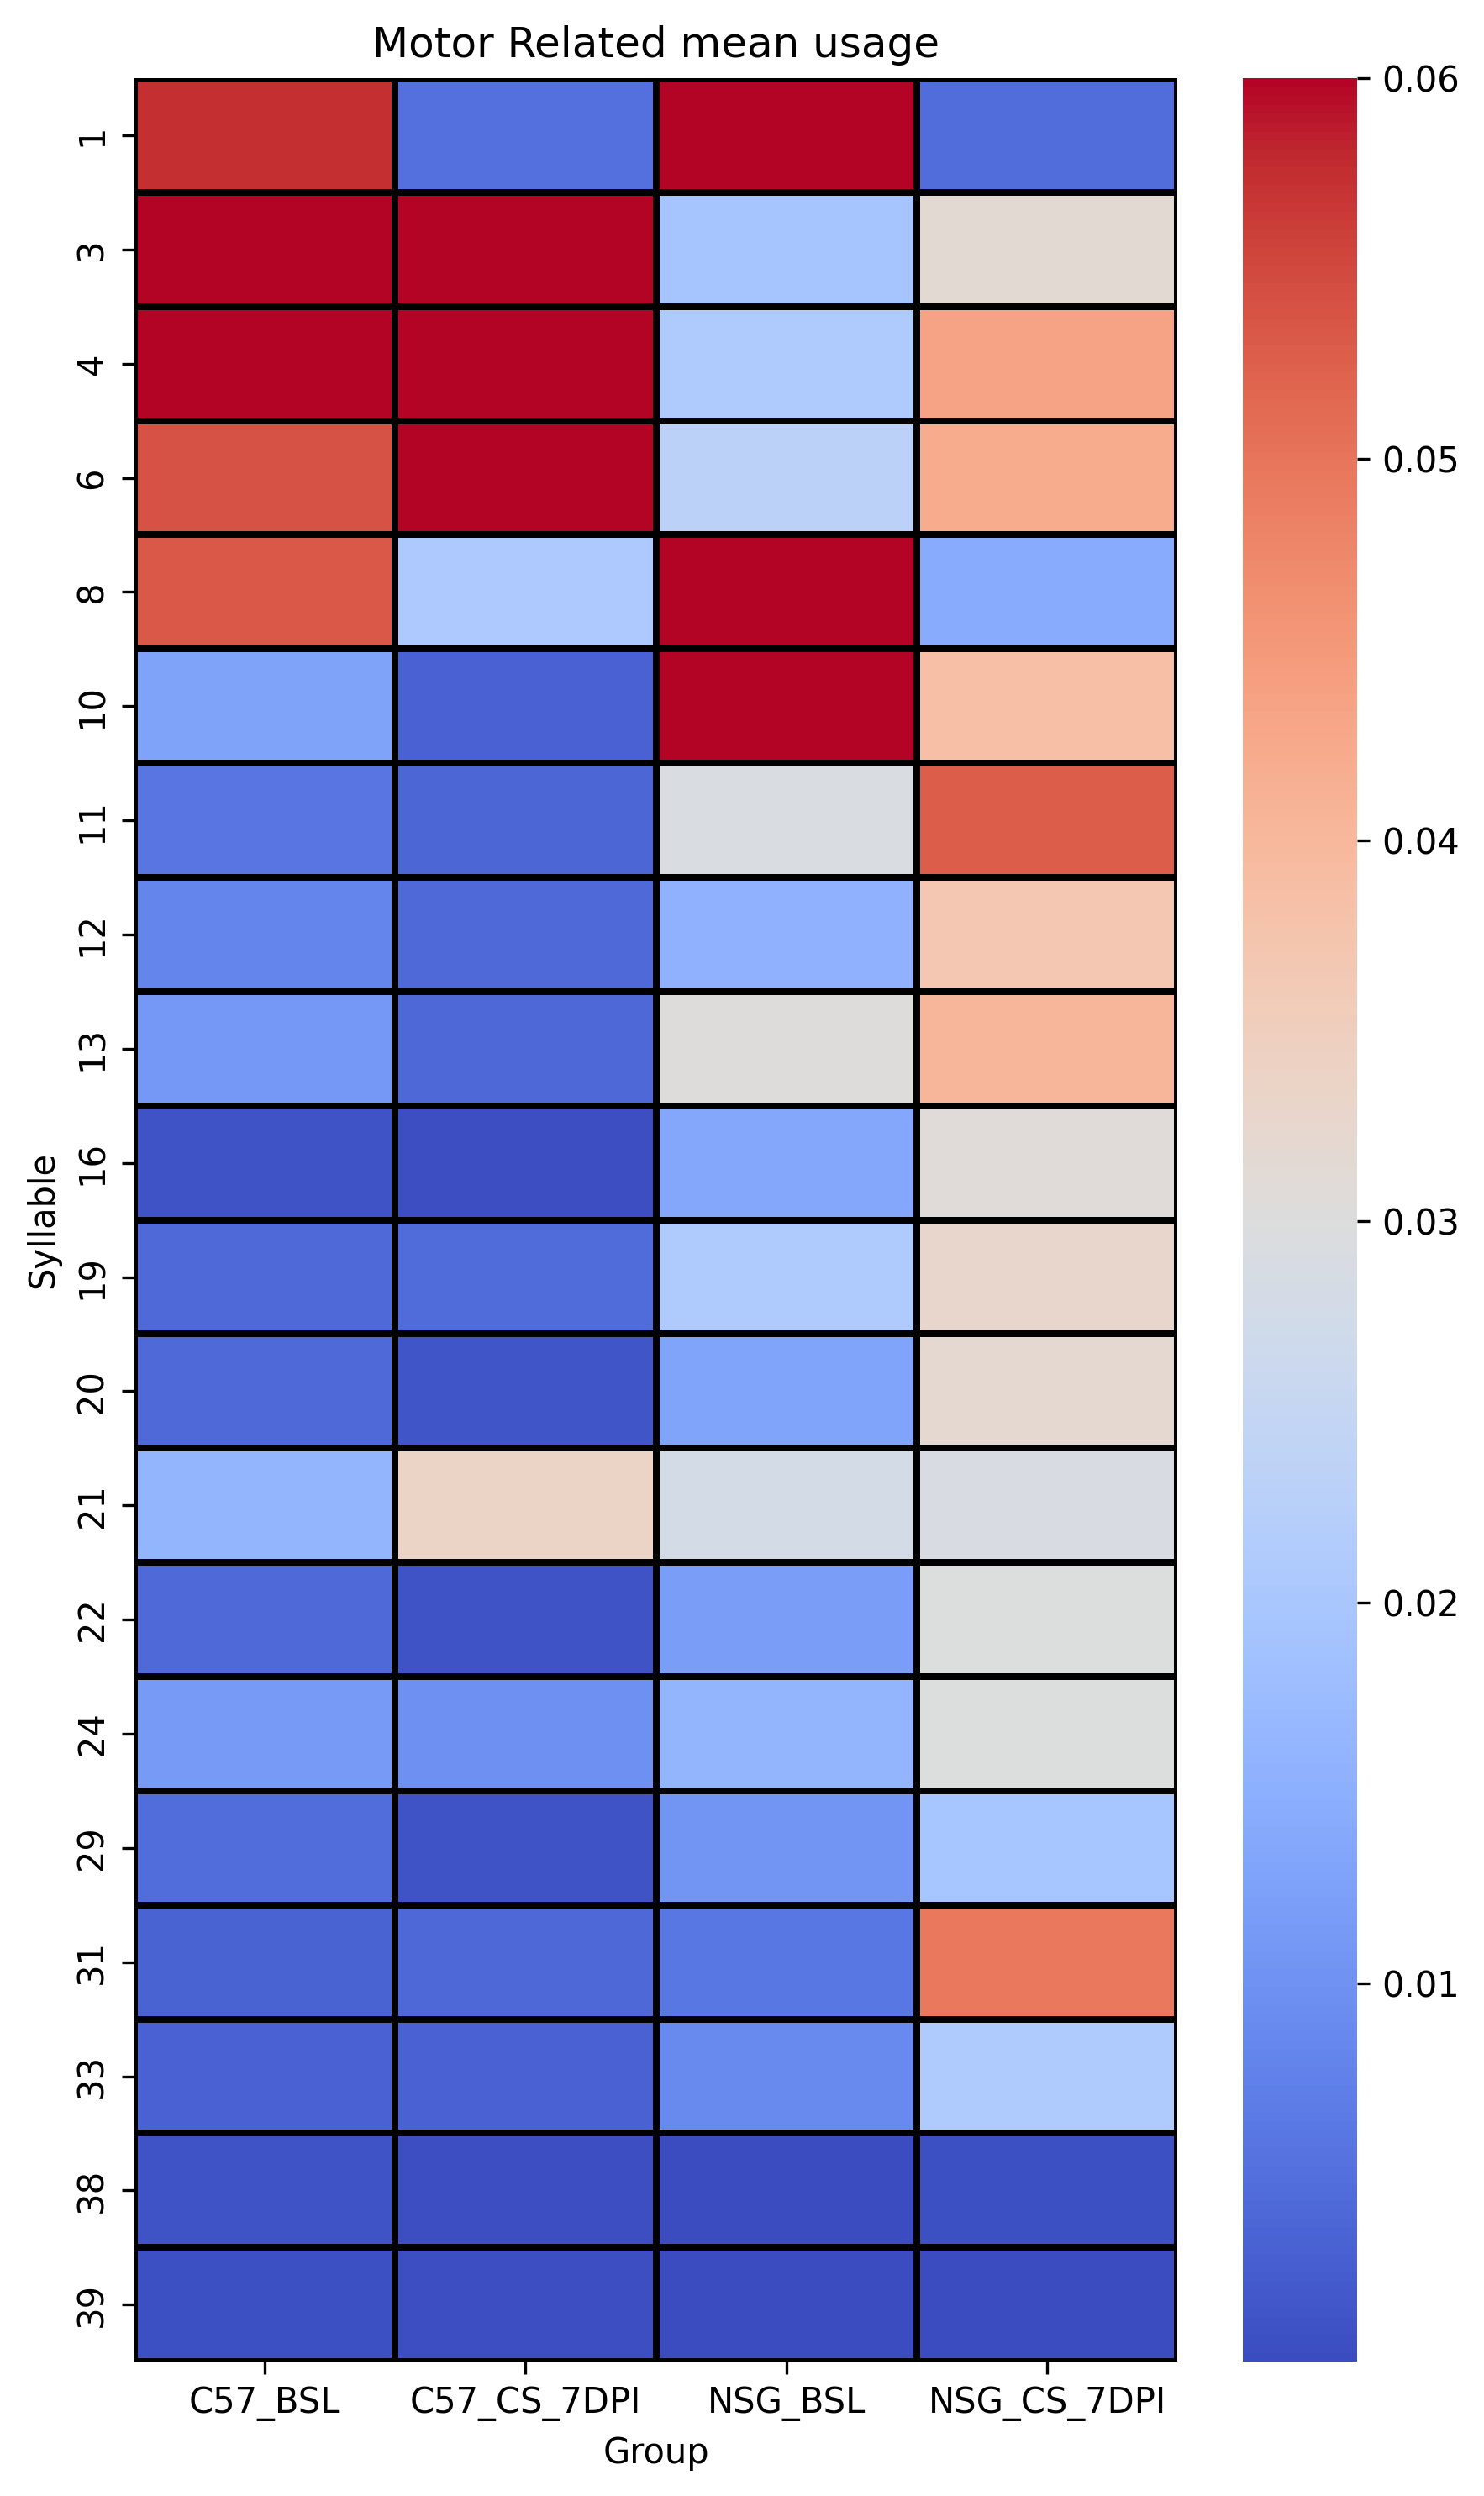

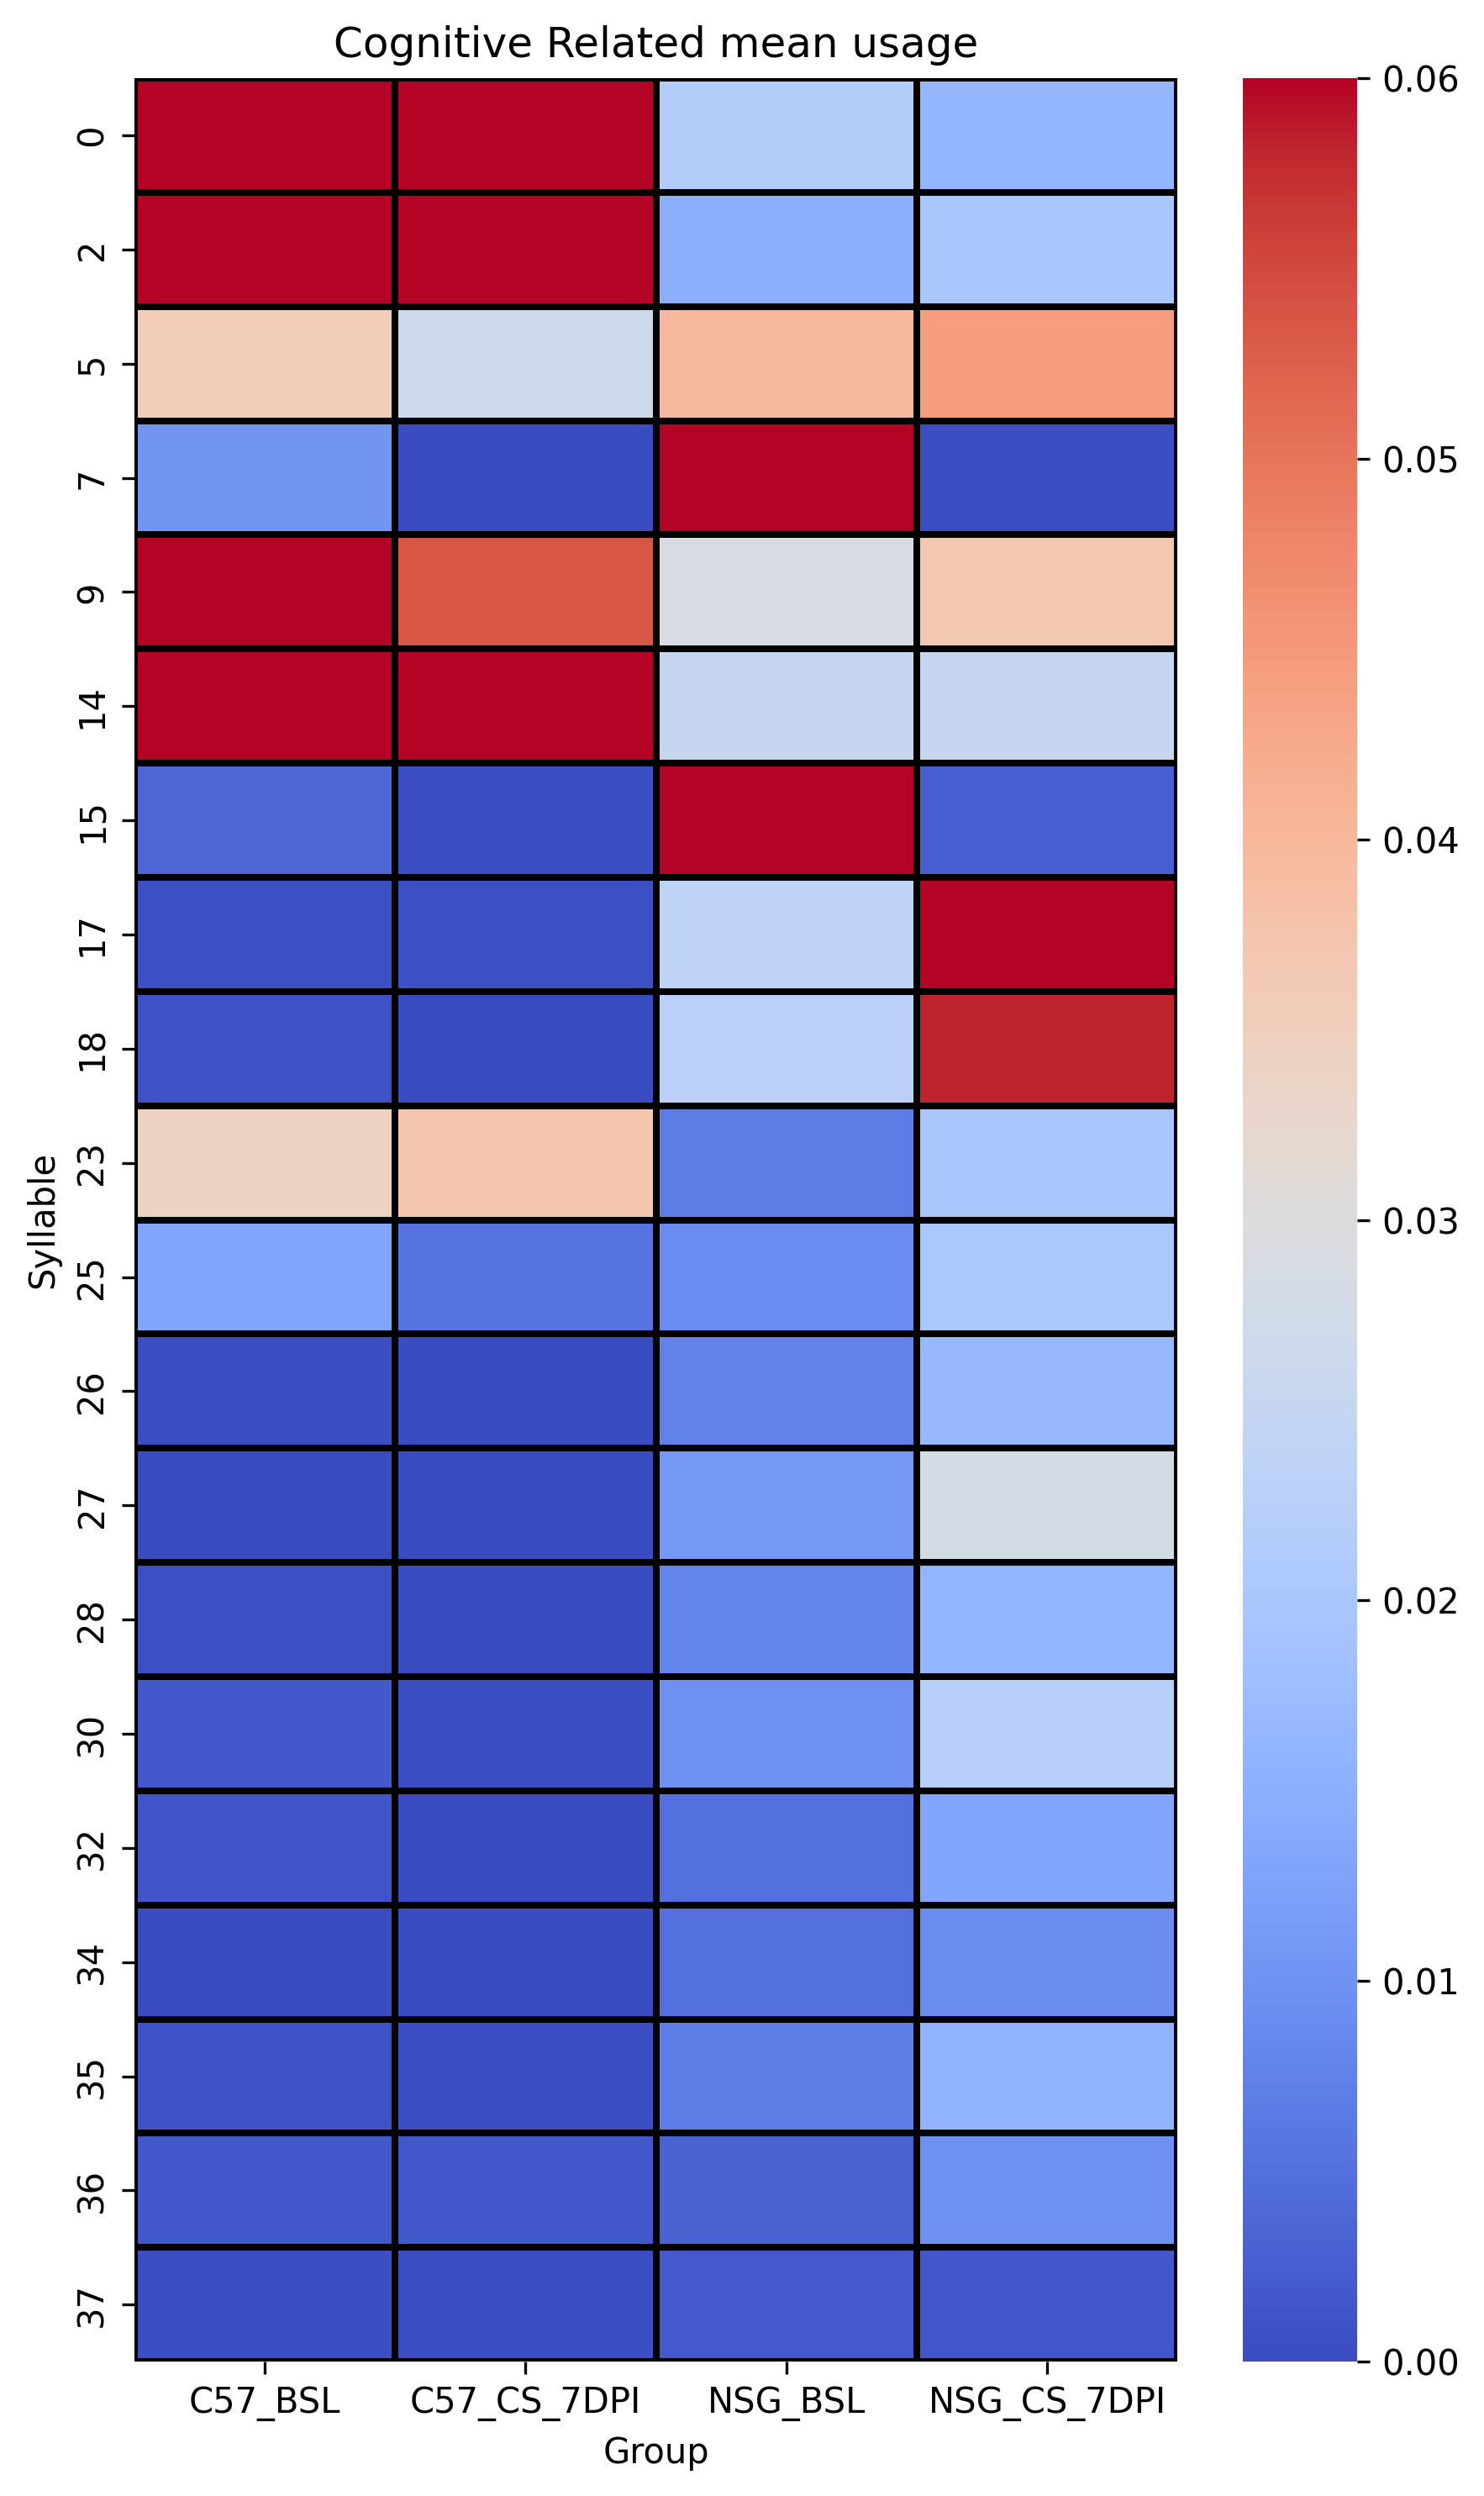

In [62]:
for title, clusters in motor_cognitive_map.items():
    df = usage[usage["cluster"].isin(clusters)]

    mean_usage = (
        df.groupby(["labels (usage sort)", "group"])["usage"]
        .mean()
        .unstack(fill_value=0)
    )[["C57_BSL", "C57_CS_7DPI", "NSG_BSL", "NSG_CS_7DPI"]]

    plt.figure(figsize=(6, 10), dpi=300)
    sns.heatmap(
        mean_usage,
        cmap="coolwarm",
        linewidths=1.5,
        linecolor="black",
        vmax=0.06,
        cbar=True
    )
    plt.title(f"{title} mean usage")
    plt.xlabel("Group")
    plt.ylabel("Syllable")
    plt.tight_layout()
    plt.savefig(SAVE_PATH / f'{title}_C57_vs_NSG_BSL_CS7dpi_cluster_usage_heatmap.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
import os
os.listdir(SAVE_PATH)

['HEATMAP_NSG_vs_Bl6_BSL_vs_Bl6_CS7dpi_All_Syllables.pdf',
 'Motor Related Deficit_usage_heatmap.pdf',
 'Motor Related Improvement_usage_heatmap.pdf',
 'Cognitive Related Deficit_usage_heatmap.pdf',
 'Cognitive Related Improvement_usage_heatmap.pdf',
 'Motor_Deficit_Transition_Probability.pdf',
 'Cognitive_Deficit_Transition_Probability.pdf',
 'Cognitive_Improvement_Transition_Probability.pdf',
 'Motor Related Improvement_NSG_vs_Bl6_BSL_Bl6_CS7dpi_cluster_usage_barchart.pdf',
 'Motor Related Deficit_NSG_vs_Bl6_BSL_Bl6_CS7dpi_cluster_usage_barchart.pdf',
 'Cognitive Related Deficit_NSG_vs_Bl6_BSL_Bl6_CS7dpi_cluster_usage_barchart.pdf',
 'Cognitive Related Improvement_NSG_vs_Bl6_BSL_Bl6_CS7dpi_cluster_usage_barchart.pdf',
 'Transition_Probability_To_Any_Syllables.pdf',
 'Motor_Deficit_Transition_Probability_4groups.pdf',
 'Cognitive_Deficit_Transition_Probability_4groups.pdf',
 'Motor_Improvement_Transition_Probability_4groups.pdf',
 'Motor_Improvement_Transition_Probability.pdf',
 'Cogn